# Predicció d'Esquizofrènia Resistent al Tractament (TRS)

Aquest notebook desenvolupa un model predictiu per identificar pacients amb esquizofrènia resistent al tractament (TRS) basant-se en paràmetres de laboratori, marcadors genètics, característiques de neuroimatge i dades demogràfiques.

**Objectiu:** Crear un model que classifiqui pacients entre TRS i no-TRS (NTRS) utilitzant tècniques d'aprenentatge automàtic.

**Dataset:** 
- `trs_train.csv`: 9000 observacions per entrenar i validar
- `trs_eval.csv`: 1000 observacions per avaluar (sense variable objectiu)

**Data:** Desembre 2025  
**Assignatura:** Introducció a l'Aprenentatge Automàtic


## Setup

Importem les llibreries necessàries per a la càrrega de dades, visualització, preprocessament i modelatge.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

## Càrrega de dades

Carreguem els conjunts d'entrenament i avaluació.

In [3]:
df_train = pd.read_csv('trs_train.csv')
df_eval = pd.read_csv('trs_eval.csv')

X_train_full = df_train.iloc[:, 1:].drop('TRS', axis=1)
y_train_full = df_train['TRS']

X_eval = df_eval.iloc[:, 1:]

print(f"Training set: {X_train_full.shape}")
print(f"Training class distribution:\n{y_train_full.value_counts()}")
print(f"\nEvaluation set: {X_eval.shape}")

Training set: (9000, 26)
Training class distribution:
TRS
0    6162
1    2838
Name: count, dtype: int64

Evaluation set: (1000, 26)


## 1. Anàlisi i preprocessat de dades

### 1.1 Exploració Inicial

Primer examinem l'estructura del dataset i obtenim estadístiques bàsiques de les variables.

In [4]:
X_train_full.head()

,Age,Sex,Ethnicity,Duration_untreated_psychosis,Family_history,Initial_response,Lymphocyte_count,Neutrophil_count,BMI,Triglycerides,...,HLA_A_31_01,Polygenic_risk_score,Del_22q11_2_status,IL_17A,CCL23,TWEAK,Ki_whole_striatum,Ki_associative_striatum,SUVRc_whole_striatum,SUVRc_associative_striatum
0,28.0,1,Caucasian,7.5,1,24.7,2.35,NaN,31.2,230.6,...,1,0.330,0,2.76,5.66,4.47,0.01147,0.01082,1.225,1.133
1,23.0,1,Asian,3.6,1,41.0,2.02,3.34,26.2,58.9,...,0,0.121,0,2.04,2.67,1.93,0.01386,0.01437,1.042,1.502
2,29.0,1,Caucasian,7.4,0,6.0,NaN,5.38,39.2,NaN,...,0,-0.098,0,1.55,2.31,2.92,0.01589,0.01632,1.728,1.842
3,36.0,0,Hispanic,5.5,0,43.4,1.60,6.84,31.5,152.5,...,0,0.019,0,1.77,2.37,4.26,0.01178,0.01154,1.399,1.249
4,23.0,0,Caucasian,4.5,0,86.1,NaN,3.18,29.6,221.0,...,0,-0.049,0,2.11,3.55,3.84,0.01209,0.01171,0.800,1.533


In [5]:
from io import StringIO

buffer = StringIO()
X_train_full.info(buf=buffer)
print(buffer.getvalue())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           9000 non-null   float64
 1   Sex                           9000 non-null   int64  
 2   Ethnicity                     9000 non-null   object 
 3   Duration_untreated_psychosis  8872 non-null   float64
 4   Family_history                9000 non-null   int64  
 5   Initial_response              9000 non-null   float64
 6   Lymphocyte_count              7009 non-null   float64
 7   Neutrophil_count              7015 non-null   float64
 8   BMI                           9000 non-null   float64
 9   Triglycerides                 6547 non-null   float64
 10  Glucose                       6381 non-null   float64
 11  Alkaline_phosphatase          6062 non-null   float64
 12  Prior_antipsychotics          9000 non-null   int64  
 13  CYP

### 1.2 Anàlisi estadístic de variables

Analitzem estadísticament les variables de manera independent. 

In [6]:
X_train_full.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9000.0,26.039444,10.011767,13.00000,19.00000,25.00000,31.00000,64.000
Sex,9000.0,0.576000,0.494218,0.00000,0.00000,1.00000,1.00000,1.000
Duration_untreated_psychosis,8872.0,19.220548,19.545745,0.30000,6.40000,12.50000,24.30000,125.000
Family_history,9000.0,0.118778,0.323545,0.00000,0.00000,0.00000,0.00000,1.000
Initial_response,9000.0,41.840367,30.160230,0.00000,10.10000,38.20000,72.30000,100.000
Lymphocyte_count,7009.0,1.795761,0.601099,0.50000,1.38000,1.80000,2.20000,4.020
Neutrophil_count,7015.0,5.014574,1.471581,1.50000,4.00500,5.02000,6.01000,9.960
BMI,9000.0,28.107556,5.433100,15.00000,24.40000,28.00000,31.70000,49.600
Triglycerides,6547.0,152.012800,61.099018,40.00000,108.05000,151.10000,194.60000,394.600
Glucose,6381.0,95.859881,18.310027,65.00000,82.20000,95.50000,108.30000,159.600


**Caption Taula 1:** Estadístics descriptius (mitjana, desviació típica, valors extrems i quartils) de les variables del conjunt d'entrenament

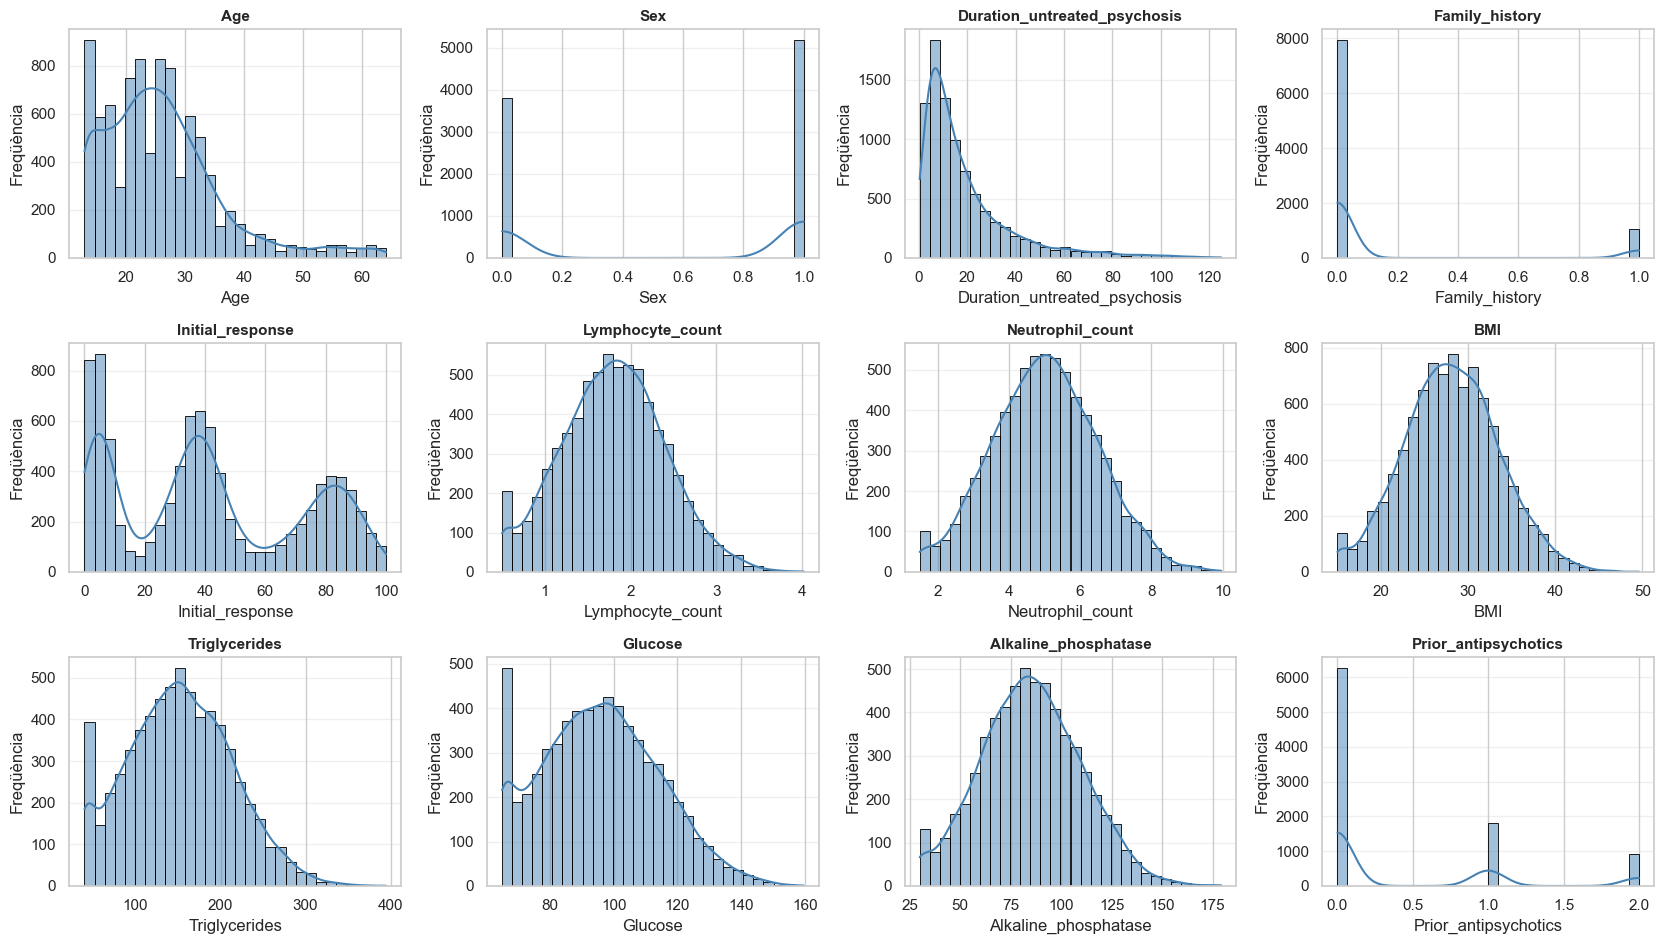

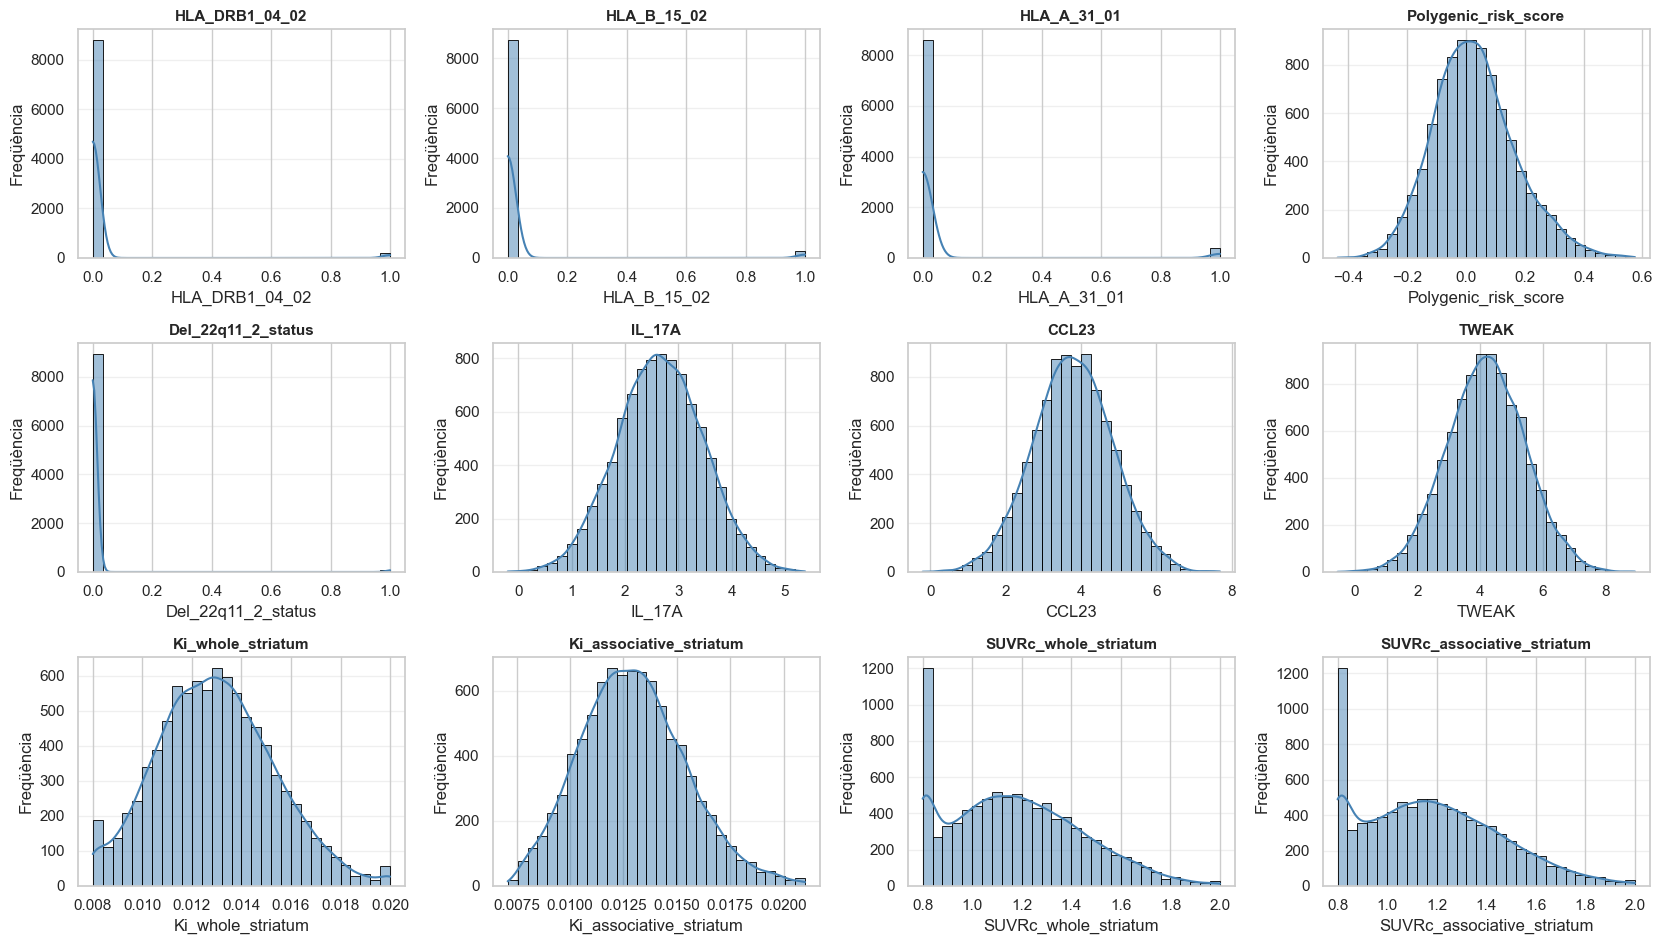

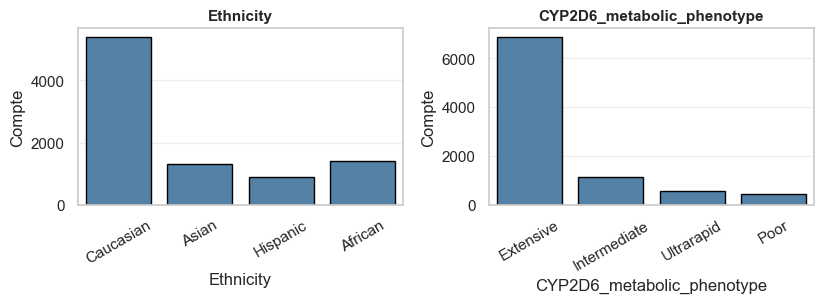

In [7]:
# Visualització univariant de totes les variables del dataset:
# - Histogrames per numèriques
# - Diagrames de barres per categòriques

df = X_train_full

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def plot_columns_grid(df, cols, kind='hist', cols_per_row=4):
    if len(cols) == 0:
        return

    for start in range(0, len(cols), cols_per_row * 3):
        chunk = cols[start:start + cols_per_row * 3]
        rows = int(np.ceil(len(chunk) / cols_per_row))
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4.2, rows * 3.2))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(chunk):
            ax = axes[i]
            if kind == 'hist':
                sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='black', bins=30)
                ax.set_ylabel('Freqüència')
            else:
                sns.countplot(data=df, x=col, ax=ax, color='steelblue', edgecolor='black')
                ax.tick_params(axis='x', rotation=30)
                ax.set_ylabel('Compte')

            ax.set_title(col, fontsize=11, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

        for j in range(len(chunk), len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

# Histogrames variables numèriques
plot_columns_grid(df, num_cols, kind='hist', cols_per_row=4)

# Barres variables categòriques
plot_columns_grid(df, cat_cols, kind='bar', cols_per_row=2)

**Caption Figura 1**: Distribucions univariants inicials. Els histogrames mostren la forma, dispersió i possibles asimetries de les variables numèriques, mentre que els diagrames de barres reflecteixen la freqüència de cada categoria de les variables categòriques.

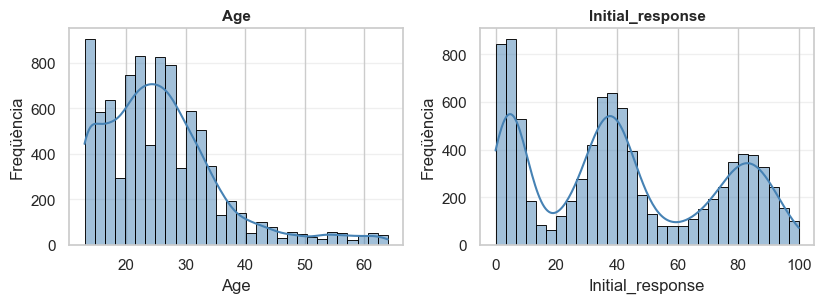

,count,mean,std,min,25%,50%,75%,max
Age,9000.0,26.039444,10.011767,13.0,19.0,25.0,31.0,64.0
Initial_response,9000.0,41.840367,30.160230,0.0,10.1,38.2,72.3,100.0


In [8]:
num_cols_subset = ['Age', 'Initial_response']

plot_columns_grid(df, num_cols_subset, kind='hist', cols_per_row=2)

X_train_full[['Age', 'Initial_response']].describe().T

#### 1.2.1 Variables Categòriques

Identifiquem les variables categòriques presents al dataset.

In [9]:
categorical_features = cat_cols
print(f"Variables categòriques: {categorical_features}")

print(f"\nValors únics per variable:")
for col in categorical_features:
    print(f"{col}: {X_train_full[col].unique()}")

Variables categòriques: ['Ethnicity', 'CYP2D6_metabolic_phenotype']

Valors únics per variable:
Ethnicity: ['Caucasian' 'Asian' 'Hispanic' 'African']
CYP2D6_metabolic_phenotype: ['Extensive' 'Intermediate' 'Ultrarapid' 'Poor']


### 1.3 Estudi de Balanceig de Classes

Analitzem la distribució de la variable objectiu **TRS** (Treatment-Resistant Schizophrenia) vs **NTRS** (Non-Treatment-Resistant) en el conjunt de train i test donat.

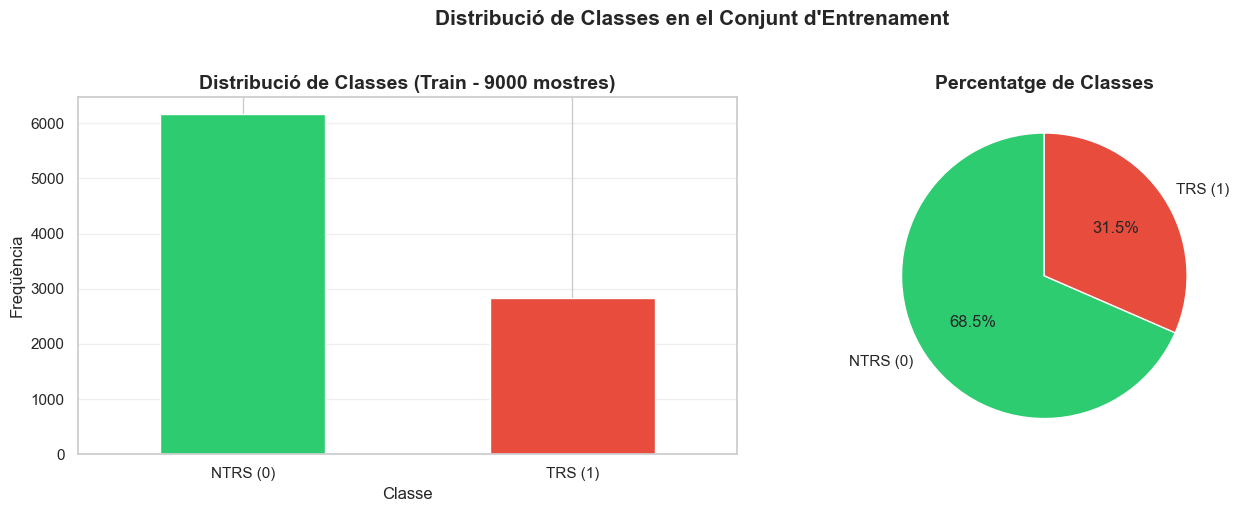

Distribució de classes
NTRS (0): 6,162 mostres (68.47%)
TRS (1):  2,838 mostres (31.53%)
Ràtio NTRS/TRS: 2.17:1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train_full.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribució de Classes (Train - 9000 mostres)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe', fontsize=12)
axes[0].set_ylabel('Freqüència', fontsize=12)
axes[0].set_xticklabels(['NTRS (0)', 'TRS (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

counts = y_train_full.value_counts()
axes[1].pie(counts, labels=['NTRS (0)', 'TRS (1)'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Percentatge de Classes', fontsize=14, fontweight='bold')

plt.suptitle('Distribució de Classes en el Conjunt d\'Entrenament', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("="*60)
print("Distribució de classes")
print("="*60)
print(f"NTRS (0): {counts[0]:,} mostres ({counts[0]/len(y_train_full)*100:.2f}%)")
print(f"TRS (1):  {counts[1]:,} mostres ({counts[1]/len(y_train_full)*100:.2f}%)")
print(f"Ràtio NTRS/TRS: {counts[0]/counts[1]:.2f}:1")
print("="*60)

**Caption Figura 2:** Estudi de balanceig de la classe objectiu. El diagrama de barres i el de sectors reflecteixen la freqüència de cada categoria de la variable TRS en el conjunt d'entrenament de 9.000 observacions. S'observa un desequilibri entre la classe NTRS (68,5%) i la classe TRS (31,5%).

### 1.4 Valors Missing (NaN)

(Imputació després del particionament)

In [11]:
missing_values = X_train_full.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Variables amb valors missing:")
print(missing_values)

print(f"\nPercentatge de missing:")
print((missing_values / len(X_train_full) * 100).round(2))

Variables amb valors missing:
Alkaline_phosphatase            2938
Glucose                         2619
Triglycerides                   2453
Lymphocyte_count                1991
Neutrophil_count                1985
Duration_untreated_psychosis     128
IL_17A                             1
Polygenic_risk_score               1
dtype: int64

Percentatge de missing:
Alkaline_phosphatase            32.64
Glucose                         29.10
Triglycerides                   27.26
Lymphocyte_count                22.12
Neutrophil_count                22.06
Duration_untreated_psychosis     1.42
IL_17A                           0.01
Polygenic_risk_score             0.01
dtype: float64


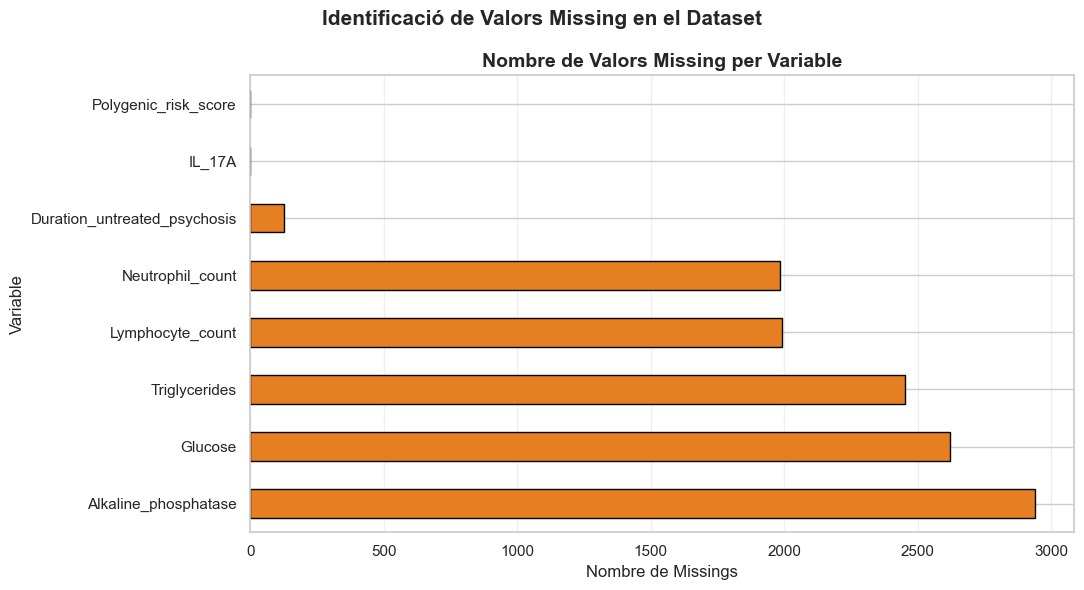


Valors Missing per Variable
                    Variable  Count Missing  Percentage (%)
        Alkaline_phosphatase           2938           32.64
                     Glucose           2619           29.10
               Triglycerides           2453           27.26
            Lymphocyte_count           1991           22.12
            Neutrophil_count           1985           22.06
Duration_untreated_psychosis            128            1.42
                      IL_17A              1            0.01
        Polygenic_risk_score              1            0.01


In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_values.plot(kind='barh', ax=ax, color='#e67e22', edgecolor='black')
ax.set_title('Nombre de Valors Missing per Variable', fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre de Missings', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.suptitle('Identificació de Valors Missing en el Dataset', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Taula resumida
missing_summary = pd.DataFrame({
    'Variable': missing_values.index,
    'Count Missing': missing_values.values,
    'Percentage (%)': (missing_values / len(X_train_full) * 100).round(2).values
})
print("\n" + "="*70)
print("Valors Missing per Variable")
print("="*70)
print(missing_summary.to_string(index=False))
print("="*70)

**Caption Figura 3**: Identificació de valors absents (missings) en el conjunt de dades. El gràfic de barres horitzontal quantifica el nombre de registres buits per a cada variable, destacant una mancança notable de dades en Alkaline_phosphatase, Glucose i Triglycerides (27-33%), mentre que altres variables tenen missings mínims (<2%).

### 1.5 Outliers 

                    Variable     Q1     Q3   IQR Lower Bound Upper Bound  Outliers Percentatge (%)
                         Age  19.00  31.00 12.00        1.00       49.00       360           4.00%
Duration_untreated_psychosis   6.40  24.30 17.90      -20.45       51.15       651           7.23%
            Initial_response  10.10  72.30 62.20      -83.20      165.60         0           0.00%
            Lymphocyte_count   1.38   2.20  0.82        0.15        3.43        26           0.29%
            Neutrophil_count   4.00   6.01  2.00        1.00        9.02        32           0.36%
                         BMI  24.40  31.70  7.30       13.45       42.65        39           0.43%
               Triglycerides 108.05 194.60 86.55      -21.77      324.42        22           0.24%
                     Glucose  82.20 108.30 26.10       43.05      147.45        16           0.18%
        Alkaline_phosphatase  68.20 101.90 33.70       17.65      152.45        23           0.26%
        Pr

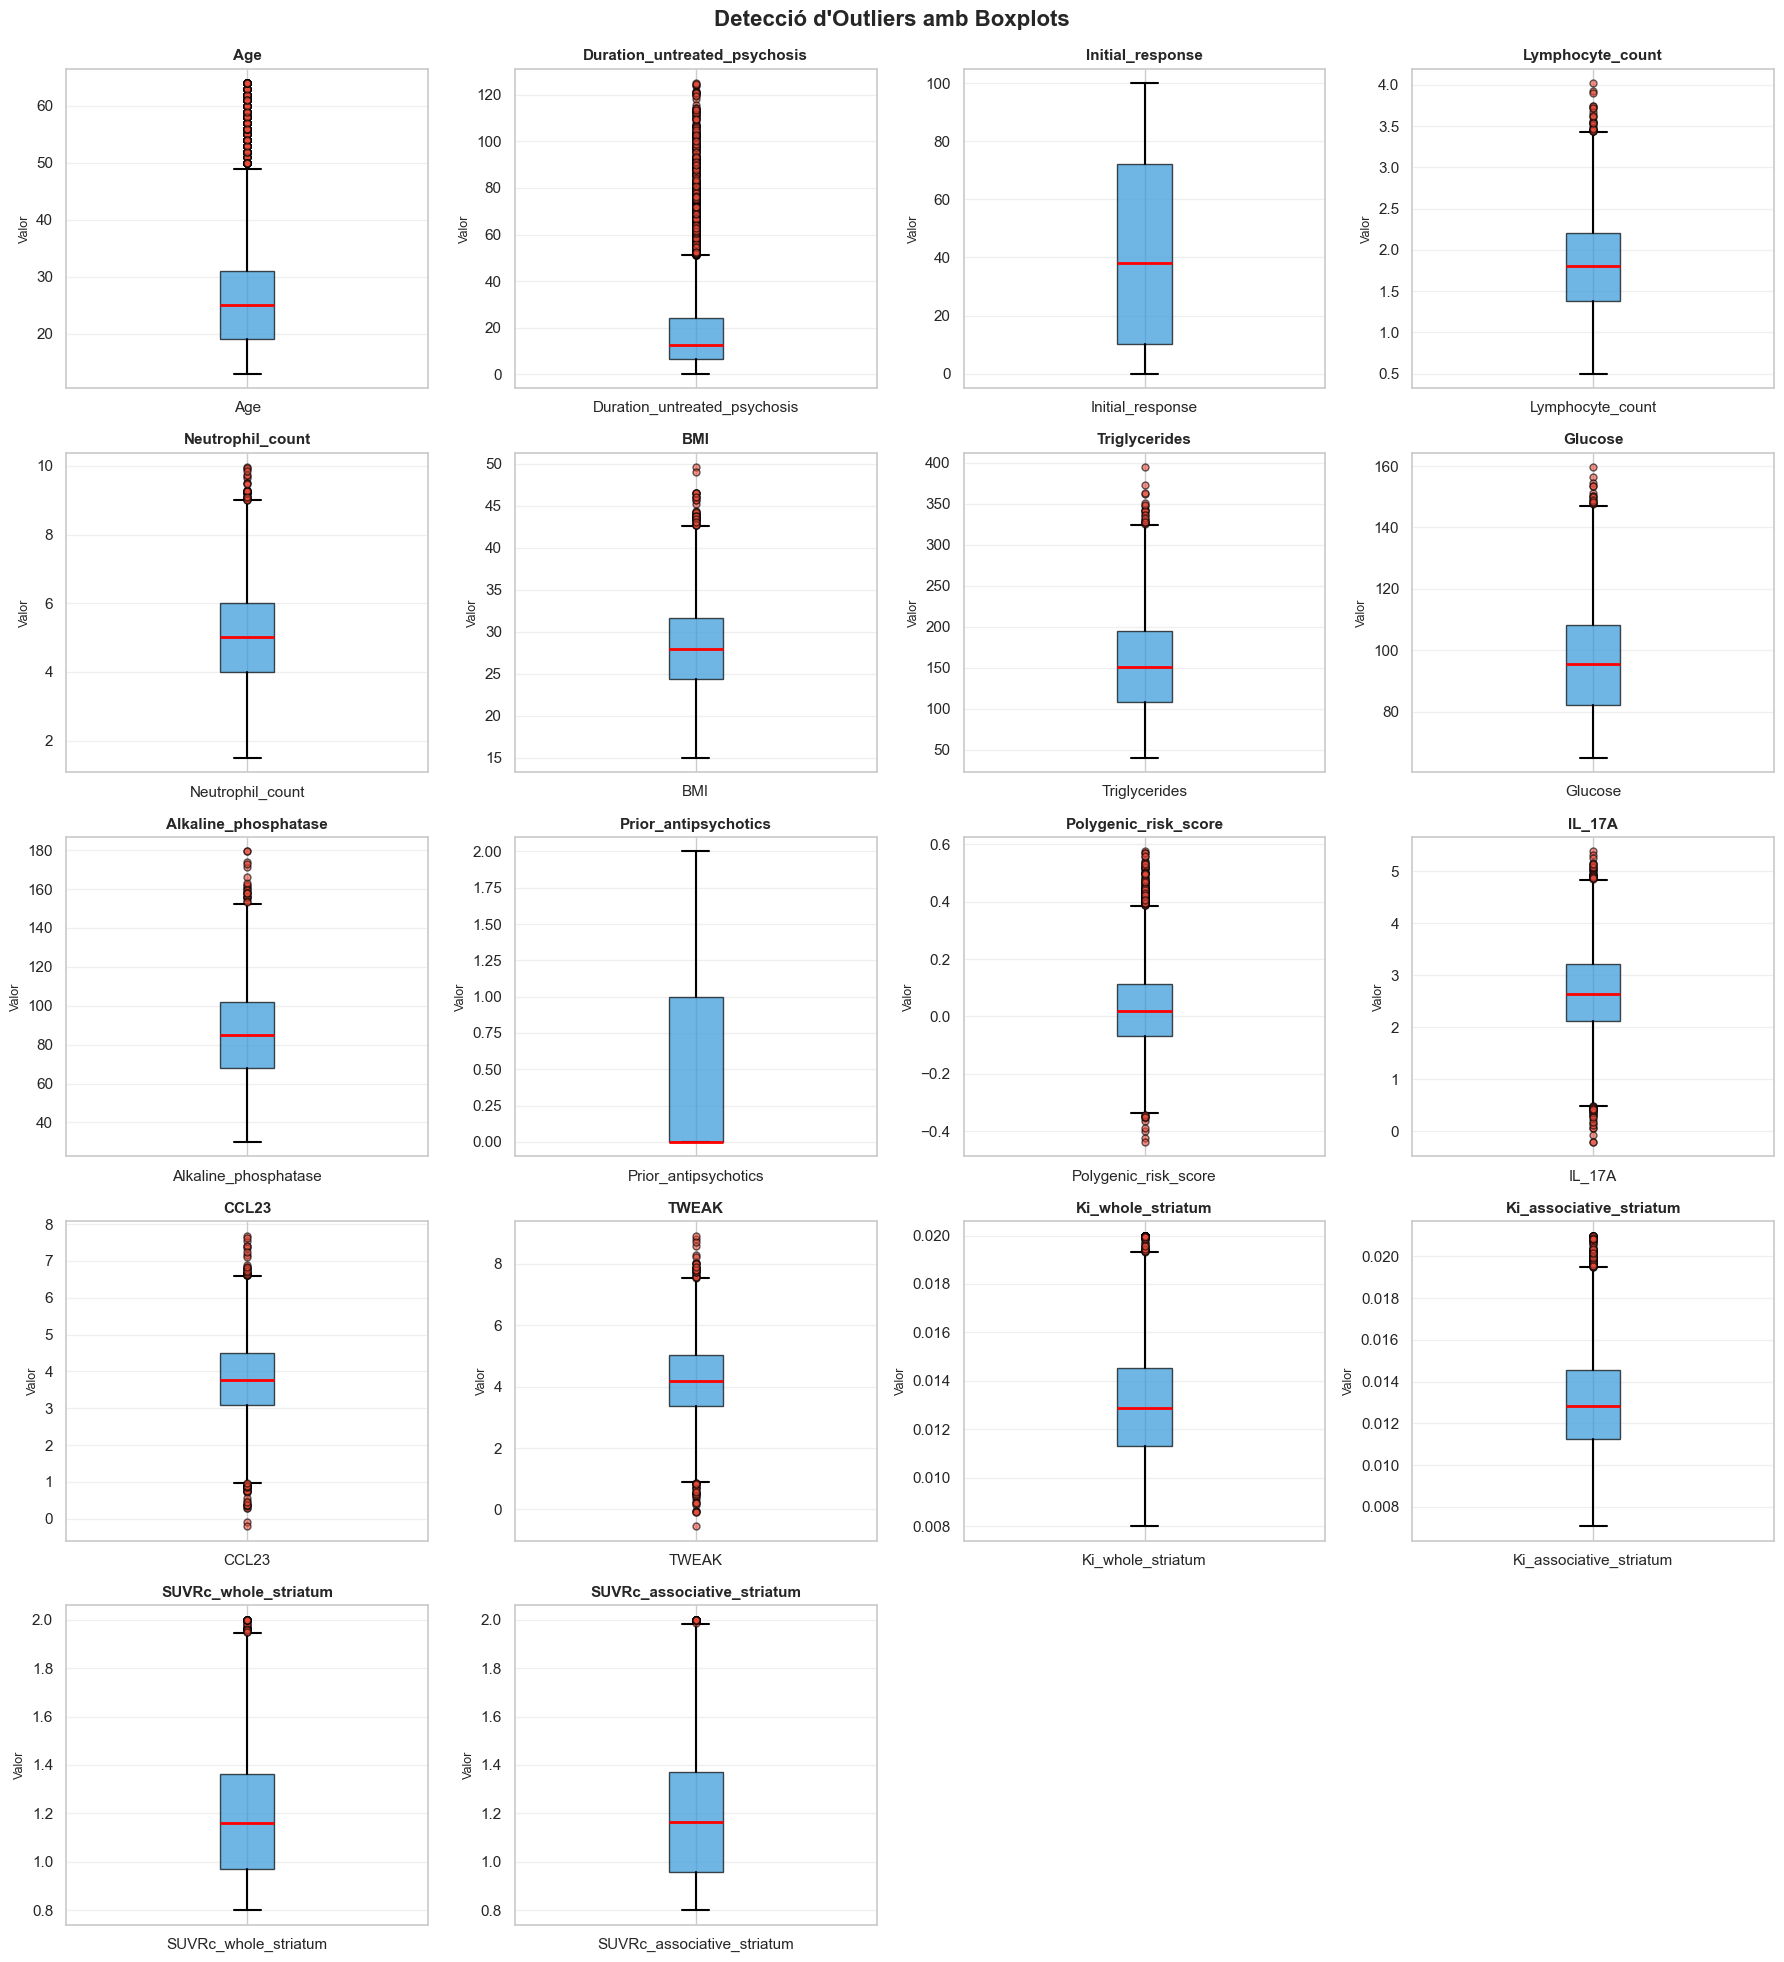

In [13]:
# DETECCIÓ D'OUTLIERS - MÈTODE IQR (Interquartile Range): es detecten com outliers els valors fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

numeric_features = [
    col for col in X_train_full.select_dtypes(include=[np.number]).columns 
    if X_train_full[col].nunique() > 2 # excloem binaries 
]

outlier_summary = []
for col in numeric_features:
    Q1 = X_train_full[col].quantile(0.25)
    Q3 = X_train_full[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers = X_train_full[(X_train_full[col] < lower_bound) | (X_train_full[col] > upper_bound)]
    pct = len(outliers) / len(X_train_full) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Q1': f'{Q1:.2f}',
        'Q3': f'{Q3:.2f}',
        'IQR': f'{IQR:.2f}',
        'Lower Bound': f'{lower_bound:.2f}',
        'Upper Bound': f'{upper_bound:.2f}',
        'Outliers': len(outliers),
        'Percentatge (%)': f'{pct:.2f}%'
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print("="*80)

# Visualització: Boxplots per a les variables numèriques
n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    X_train_full.boxplot(column=feature, ax=axes[i], patch_artist=True,
                         boxprops=dict(facecolor='#3498db', edgecolor='black', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(color='black', linewidth=1.5),
                         capprops=dict(color='black', linewidth=1.5),
                         flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5, alpha=0.6))
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valor', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Detecció d\'Outliers amb Boxplots\n', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Caption Figura 4**: Detecció de valors atípics (outliers) mitjançant el mètode de l'Interval Interquartílic (IQR). Els diagrames de caixa (boxplots) permeten visualitzar la dispersió i variabilitat de totes les variables numèriques contínues, identificant punts que queden fora dels llindars esperats.

                    Variable  Outliers Percentatge
Duration_untreated_psychosis       651       7.23%
                         Age       360       4.00%
        Polygenic_risk_score       125       1.39%
     Ki_associative_striatum        83       0.92%


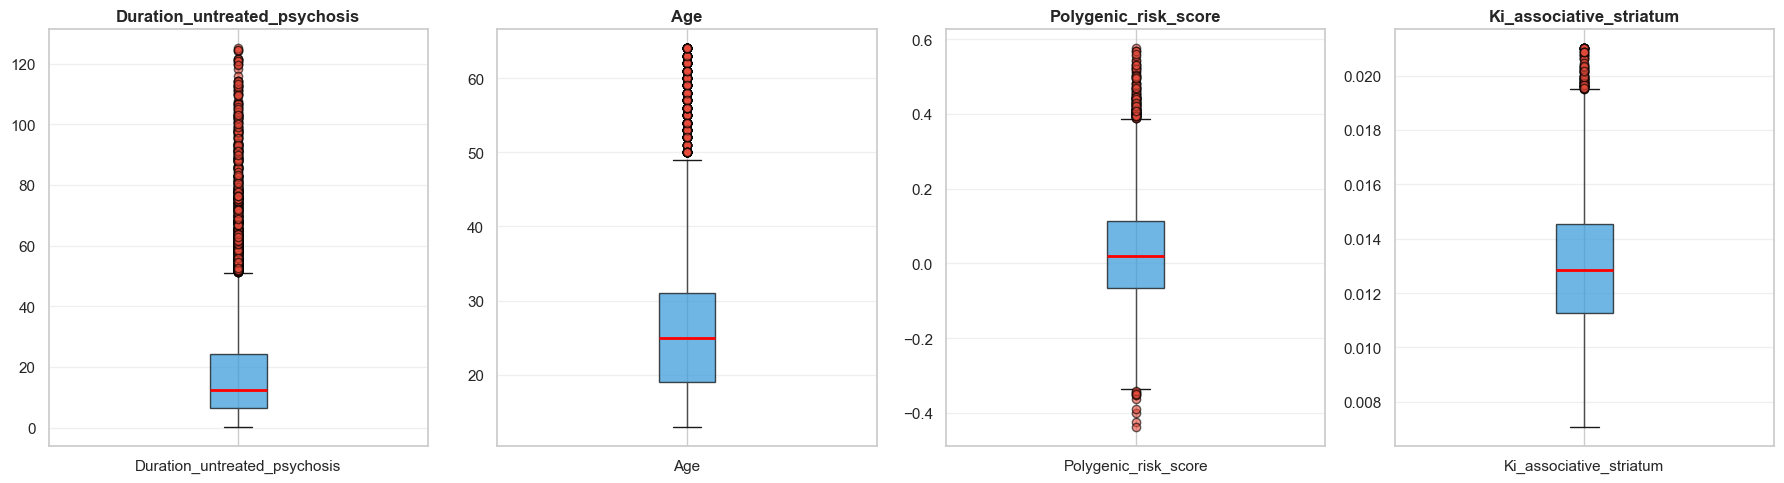

In [14]:
features_outliers = [
    'Duration_untreated_psychosis', 'Age', 
    'Polygenic_risk_score', 'Ki_associative_striatum'
]

outlier_summary = []
for col in features_outliers:
    Q1, Q3 = X_train_full[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    outliers = X_train_full[(X_train_full[col] < lower) | (X_train_full[col] > upper)]
    outlier_summary.append({
        'Variable': col,
        'Outliers': len(outliers),
        'Percentatge': f"{(len(outliers)/len(X_train_full)*100):.2f}%"
    })

print(pd.DataFrame(outlier_summary).to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(features_outliers):
    X_train_full.boxplot(column=col, ax=axes[i], patch_artist=True,
                         boxprops=dict(facecolor='#3498db', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='#e74c3c', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 1.6 Recodificació de Variables

Els models que entrenarem només accepten variables numèriques. Per aquesta raó, recodificarem les variables categòriques amb One-Hot Encoding.

- **Ethnicity**: 4 categories (Caucasian, Asian, Hispanic, African)
- **CYP2D6_metabolic_phenotype**: 3 categories (Normal, Poor, Ultrarapid)

(La recodificació es farà després del particionat i la imputació, a la secció 2)

### 1.7 Particionament del Dataset

Dividim el dataset d'entrenament en **train/validation** (70/30) mantenint la proporció de classes.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_train_full
)

print(f"Mida dels conjunts:")
print(f"  Training set:   {X_train.shape[0]} mostres")
print(f"  Validation set: {X_val.shape[0]} mostres")
print(f"\nDistribució de classes (Train):")
print(y_train.value_counts())
print(f"\nDistribució de classes (Validation):")
print(y_val.value_counts())

def get_class_pcts(y):
    pcts = y.value_counts(normalize=True) * 100
    return f"{pcts.get(0, 0):.2f}%", f"{pcts.get(1, 0):.2f}%"
ntrs_train, trs_train = get_class_pcts(y_train)
ntrs_val, trs_val = get_class_pcts(y_val)
ntrs_full, trs_full = get_class_pcts(y_train_full)

# Taula comparativa
partition_table = pd.DataFrame({
    'Partició': ['Train', 'Validation', 'Eval (Kaggle)', 'Total'],
    'Mida': [X_train.shape[0], X_val.shape[0], X_eval.shape[0], X_train_full.shape[0] + X_eval.shape[0]],
    'Percentatge': [
        f"{X_train.shape[0]/X_train_full.shape[0]*100:.1f}%",
        f"{X_val.shape[0]/X_train_full.shape[0]*100:.1f}%",
        f"{X_eval.shape[0]/(X_train_full.shape[0]+X_eval.shape[0])*100:.1f}%",
        "100%"
],
    'NTRS (%)': [ntrs_train, ntrs_val, "N/A", ntrs_full],
    'TRS (%)': [trs_train, trs_val, "N/A", trs_full]
})

print("\nParticionament del Dataset:")
print(partition_table.to_string(index=False))

Mida dels conjunts:
  Training set:   6300 mostres
  Validation set: 2700 mostres

Distribució de classes (Train):
TRS
0    4313
1    1987
Name: count, dtype: int64

Distribució de classes (Validation):
TRS
0    1849
1     851
Name: count, dtype: int64

Particionament del Dataset:
     Partició  Mida Percentatge NTRS (%) TRS (%)
        Train  6300       70.0%   68.46%  31.54%
   Validation  2700       30.0%   68.48%  31.52%
Eval (Kaggle)  1000       10.0%      N/A     N/A
        Total 10000        100%   68.47%  31.53%


### 1.8 Imputació de missings

**Estratègia:**
- **Variables numèriques**: Imputació amb **mediana** (millor elecció per la presència d'outliers)
- **Variables categòriques**: Imputació amb **moda**

In [16]:
from sklearn.impute import SimpleImputer

categorical_cols = ['Ethnicity', 'CYP2D6_metabolic_phenotype']
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"Variables numèriques a imputar: {len(numeric_cols)}")
print(f"Variables categòriques a imputar: {len(categorical_cols)}")

# Creem imputadors entrenats només amb dades de train
imputer_numeric = SimpleImputer(strategy='median')
imputer_categorical = SimpleImputer(strategy='most_frequent')

# Apliquem al train set
X_train_num = pd.DataFrame(
    imputer_numeric.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_train_cat = pd.DataFrame(
    imputer_categorical.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index
)

X_train_imputed = pd.concat([X_train_num, X_train_cat], axis=1)

X_val_num = pd.DataFrame(
    imputer_numeric.transform(X_val[numeric_cols]),
    columns=numeric_cols,
    index=X_val.index
)

X_val_cat = pd.DataFrame(
    imputer_categorical.transform(X_val[categorical_cols]),
    columns=categorical_cols,
    index=X_val.index
)

X_val_imputed = pd.concat([X_val_num, X_val_cat], axis=1)

print(f"\nMissings en train després: {X_train_imputed.isna().sum().sum()}")
print(f"Missings en validation després: {X_val_imputed.isna().sum().sum()}")

Variables numèriques a imputar: 24
Variables categòriques a imputar: 2

Missings en train després: 0
Missings en validation després: 0


## 2. Preparació de variables

En aquesta secció, preparem les dades per als models aplicant les transformacions necessàries:

1. **Normalització**: Escalat de variables per evitar que algunes domini sobre altres
2. **Codificació de variables categòriques**: Convertir categories en números
3. **Eliminació de variables redundants**: Identificar i eliminar correlacions altes
4. **Anàlisis de dimensionalitat (PCA)**: Avaluar si cal reduir el nombre de dimensions

### 2.1 Normalització de variables

**Mètode escollit: StandardScaler (z-score normalization)**
- Formula: $z = \frac{x - \mu}{\sigma}$ on $\mu$ és la mitjana i $\sigma$ és la desviació estàndard
- Resultat: Cada variable té $\mu = 0$ i $\sigma = 1$

In [17]:
from sklearn.preprocessing import StandardScaler

categorical_cols = ['Ethnicity', 'CYP2D6_metabolic_phenotype']

numeric_cols = [col for col in X_train_imputed.columns if col not in categorical_cols]

# Només normalitzarem les que tenen més de 2 valors (contínues)
# Les que tenen exactament 2 valors (binàries) les deixem tal qual (0/1)
numeric_cols_con = [col for col in numeric_cols if X_train_imputed[col].nunique() > 2]
binary_cols = [col for col in numeric_cols if X_train_imputed[col].nunique() <= 2]

print(f"Variables numèriques contínues a normalitzar: {len(numeric_cols_con)}")
print(f"Variables binàries (es queden en 0/1): {len(binary_cols)}")
print(f"Variables categòriques (no es normalitzen): {len(categorical_cols)}\n")

# Creem el scaler
scaler = StandardScaler()
X_train_scaled = X_train_imputed.copy()
X_val_scaled = X_val_imputed.copy()

# Fit + transform NOMÉS a les contínues
X_train_scaled[numeric_cols_con] = scaler.fit_transform(X_train_imputed[numeric_cols_con])

# Transform (sense fit) al validation NOMÉS a les contínues
X_val_scaled[numeric_cols_con] = scaler.transform(X_val_imputed[numeric_cols_con])

print("Estadístiques de les contínues després de normalitzar:")
print(X_train_scaled[numeric_cols_con].describe().loc[['mean', 'std']])


Variables numèriques contínues a normalitzar: 18
Variables binàries (es queden en 0/1): 6
Variables categòriques (no es normalitzen): 2

Estadístiques de les contínues després de normalitzar:
               Age  Duration_untreated_psychosis  Initial_response  \
mean -1.060175e-16                  9.022765e-18      2.080875e-16   
std   1.000079e+00                  1.000079e+00      1.000079e+00   

      Lymphocyte_count  Neutrophil_count           BMI  Triglycerides  \
mean      3.439929e-17      1.015061e-16 -3.157968e-17   2.661716e-16   
std       1.000079e+00      1.000079e+00  1.000079e+00   1.000079e+00   

           Glucose  Alkaline_phosphatase  Prior_antipsychotics  \
mean -8.272748e-16         -6.891137e-16         -4.511382e-17   
std   1.000079e+00          1.000079e+00          1.000079e+00   

      Polygenic_risk_score        IL_17A         CCL23         TWEAK  \
mean         -1.973730e-18  6.654289e-17  2.616602e-16  2.255691e-16   
std           1.000079e+00  1.0000

### 2.2 Anàlisi de variables categòriques i variable objectiu

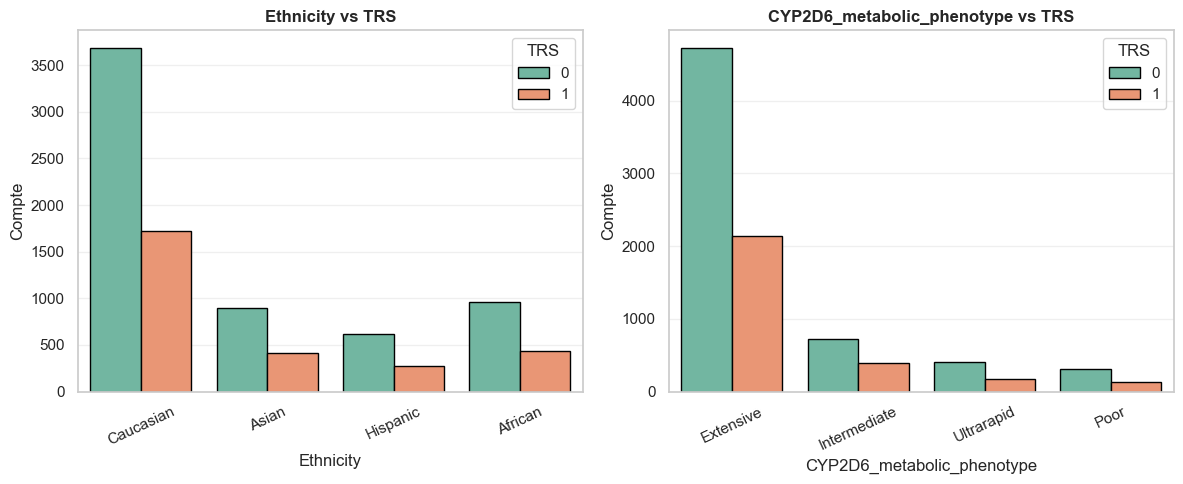


=== Ethnicity ===
Frequència absoluta:
TRS           0     1
Ethnicity            
African     963   440
Asian       895   410
Caucasian  3689  1719
Hispanic    615   269

Frequència relativa (%):
TRS            0      1
Ethnicity              
African    68.64  31.36
Asian      68.58  31.42
Caucasian  68.21  31.79
Hispanic   69.57  30.43

=== CYP2D6_metabolic_phenotype ===
Frequència absoluta:
TRS                            0     1
CYP2D6_metabolic_phenotype            
Extensive                   4730  2144
Intermediate                 726   388
Poor                         304   138
Ultrarapid                   402   168

Frequència relativa (%):
TRS                             0      1
CYP2D6_metabolic_phenotype              
Extensive                   68.81  31.19
Intermediate                65.17  34.83
Poor                        68.78  31.22
Ultrarapid                  70.53  29.47


In [18]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(6 * len(categorical_features), 5))

if len(categorical_features) == 1:
    axes = [axes]

freq_tables = {}
for ax, col in zip(axes, categorical_features):
    data_plot = pd.concat([X_train_full[col], y_train_full], axis=1)
    sns.countplot(data=data_plot, x=col, hue='TRS', ax=ax, edgecolor='black', palette='Set2')
    ax.set_title(f'{col} vs TRS', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Compte')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
    
    # Taula de freqüències absoluta i relativa
    ct = pd.crosstab(data_plot[col], data_plot['TRS'])
    ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(2)
    freq_tables[col] = {'absolute': ct, 'percent': ct_pct}

plt.tight_layout()
plt.show()

for col, tables in freq_tables.items():
    print(f"\n=== {col} ===")
    print("Frequència absoluta:")
    print(tables['absolute'])
    print("\nFrequència relativa (%):")
    print(tables['percent'])

**Caption Figura 5:** Anàlisi de variables categòriques en relació amb la variable objectiu. Els gràfics de barres comparatius mostren la distribució de la freqüència per a l'Ethnicity i el CYP2D6_metabolic_phenotype segons l'estat de resistència al tractament (TRS), permetent observar visualment si determinats grups o fenotips presenten una major proporció de pacients resistents.

#### 2.2.1 One-Hot Encoding

In [19]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit + transform al train
cat_encoded_train = ohe.fit_transform(X_train_imputed[categorical_cols])

cat_encoded_train_df = pd.DataFrame(
    cat_encoded_train,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train_imputed.index
)

# Transform al validation
cat_encoded_val = ohe.transform(X_val_imputed[categorical_cols])
cat_encoded_val_df = pd.DataFrame(
    cat_encoded_val,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_val_imputed.index
)

print(f"\nVariables categòriques originals: {categorical_cols}")
print(f"Nombre de variables després One-Hot: {cat_encoded_train_df.shape[1]}")
print(f"\nNoves variables creades:")
print(cat_encoded_train_df.columns.tolist())

# Concatenem variables numèriques (normalitzades) + categòriques (codificades)
X_train_encoded = pd.concat([
    X_train_scaled[numeric_cols],
    cat_encoded_train_df
], axis=1)

X_val_encoded = pd.concat([
    X_val_scaled[numeric_cols],
    cat_encoded_val_df
], axis=1)

print(f"\nShape final: {X_train_encoded.shape}")



Variables categòriques originals: ['Ethnicity', 'CYP2D6_metabolic_phenotype']
Nombre de variables després One-Hot: 6

Noves variables creades:
['Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'CYP2D6_metabolic_phenotype_Intermediate', 'CYP2D6_metabolic_phenotype_Poor', 'CYP2D6_metabolic_phenotype_Ultrarapid']

Shape final: (6300, 30)


### 2.3 Eliminació de variables numèriques redundants o sorolloses

**Matriu de correlació:** Analitzem la matriu de correlació entre les variables per identificar:
1. **Variables amb correlació alta** (|r| > 0.8): Són redundants, mantenim només una.

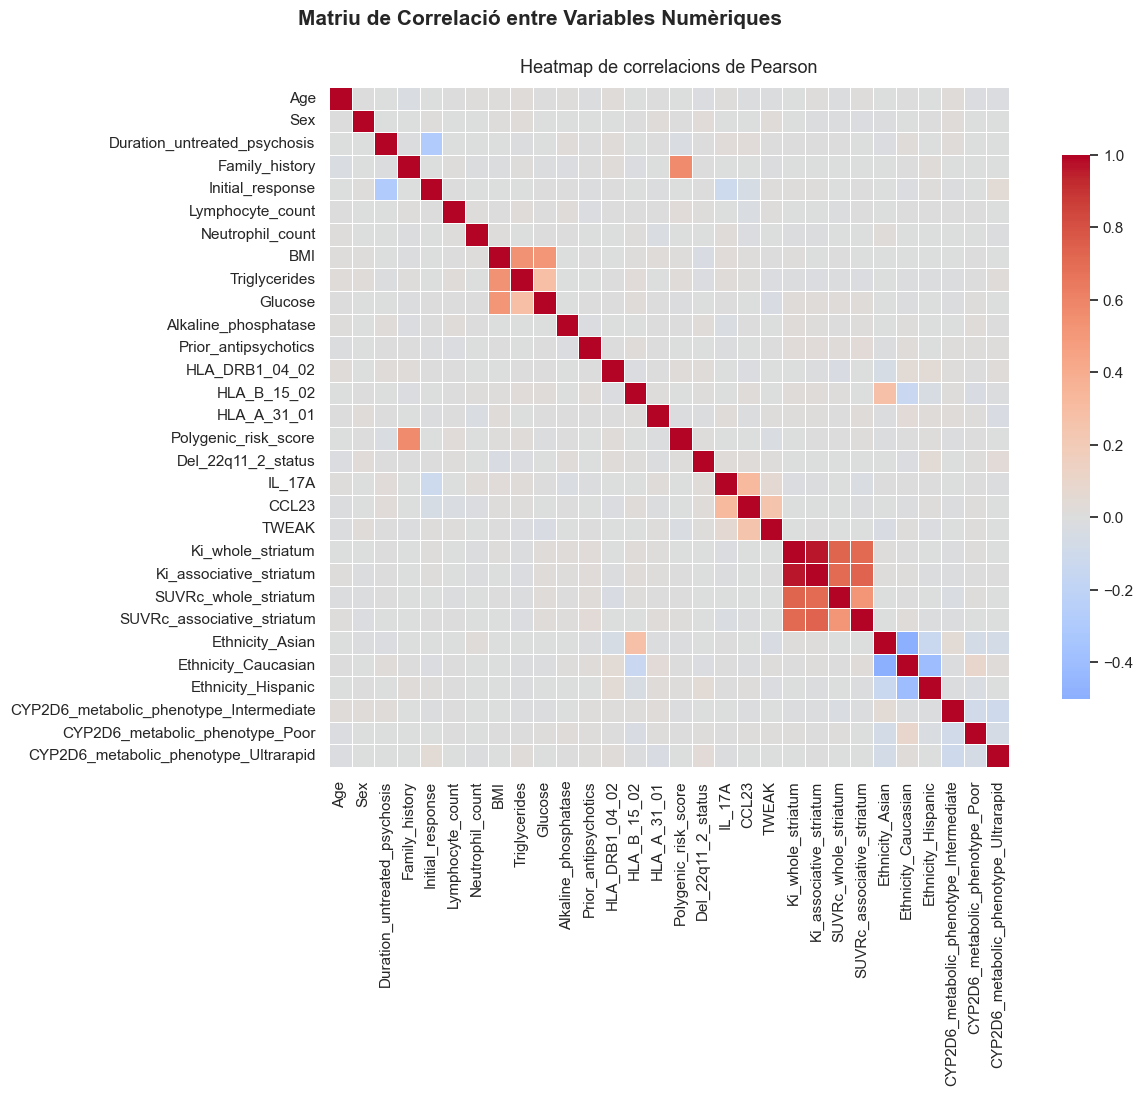

Parelles amb |correlació| > 0.8:
  Ki_whole_striatum ↔ Ki_associative_striatum: 0.964


In [20]:
correlation_matrix = X_train_encoded.corr()

fig = plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.suptitle('Matriu de Correlació entre Variables Numèriques', 
             fontsize=15, fontweight='bold', y=0.995)
plt.title('Heatmap de correlacions de Pearson', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr:
    print("Parelles amb |correlació| > 0.8:")
    for v1, v2, corr in high_corr:
        print(f"  {v1} ↔ {v2}: {corr:.3f}")

**Caption Figura 6:** Matriu de correlació entre variables. Aquest mapa de calor (heatmap) visualitza els coeficients de correlació de Pearson entre els atributs quantitatius del dataset, permetent identificar relacions lineals i redundàncies.

#### Anàlisi de la correlació de les variables amb el target (TRS):

In [21]:
df_corr_target = X_train_encoded.copy()
df_corr_target['TRS_target'] = y_train.values

full_correlation = df_corr_target.corr()

target_relationship = full_correlation['TRS_target'].drop('TRS_target').sort_values(ascending=False)

print(target_relationship)

Duration_untreated_psychosis               0.139094
Polygenic_risk_score                       0.084608
Family_history                             0.061826
Ki_whole_striatum                          0.042064
Ki_associative_striatum                    0.039935
CYP2D6_metabolic_phenotype_Intermediate    0.024232
SUVRc_whole_striatum                       0.022504
SUVRc_associative_striatum                 0.020546
HLA_DRB1_04_02                             0.017025
Ethnicity_Caucasian                        0.012412
HLA_A_31_01                                0.010122
Triglycerides                              0.009316
IL_17A                                     0.005353
TWEAK                                      0.002977
CYP2D6_metabolic_phenotype_Poor            0.001938
Glucose                                    0.001296
BMI                                        0.001283
Sex                                        0.000667
Alkaline_phosphatase                      -0.001218
Ethnicity_Hi

**Decisió de selecció:** Eliminem `Ki_associative_striatum`. 
   - Correlació de 0.964 amb `Ki_whole_striatum` (extremadament alta). Redundant, contenen essencialment la mateixa informació i `Ki_whole_striatum` perquè és més general. A més, la correlació gairabé idèntica amb el target. 

In [22]:
vars_to_drop = ['Ki_associative_striatum']
numeric_cols_con_final = [col for col in numeric_cols_con if col not in vars_to_drop]

X_train_final = pd.concat([
    X_train_scaled[numeric_cols_con_final],  # Contínues filtrades i escalades
    X_train_scaled[binary_cols],             # Binàries originals (0/1)
    cat_encoded_train_df                     # Categòriques codificades (One-Hot)
], axis=1)

X_val_final = pd.concat([
    X_val_scaled[numeric_cols_con_final],
    X_val_scaled[binary_cols],
    cat_encoded_val_df
], axis=1)

print("RESUM DE LA SELECCIÓ DE VARIABLES")

print(f"\nVariables numèriques (Escalades):")
print(f"   - Originals: {len(numeric_cols_con)}")
print(f"   - Eliminades per redundància: {len(vars_to_drop)} ({vars_to_drop})")
print(f"   - Finals: {len(numeric_cols_con_final)}")

print(f"\n2. Variables binaries originals (No escalades, 0/1):")
print(f"   - Total: {len(binary_cols)}")

print(f"\nVariables categòriques (One-Hot Encoding):")
print(f"   - Originals: {len(categorical_cols)}")
print(f"   - Columnes generades: {cat_encoded_train_df.shape[1]}")

print(f"\nDimensió final del dataset:")
print(f"  Train: {X_train_final.shape}")
print(f"  Validation: {X_val_final.shape}")
print(f"  Total features: {X_train_final.shape[1]}")

RESUM DE LA SELECCIÓ DE VARIABLES

Variables numèriques (Escalades):
   - Originals: 18
   - Eliminades per redundància: 1 (['Ki_associative_striatum'])
   - Finals: 17

2. Variables binaries originals (No escalades, 0/1):
   - Total: 6

Variables categòriques (One-Hot Encoding):
   - Originals: 2
   - Columnes generades: 6

Dimensió final del dataset:
  Train: (6300, 29)
  Validation: (2700, 29)
  Total features: 29


### 2.4 Estudi de dimensionalitat amb PCA

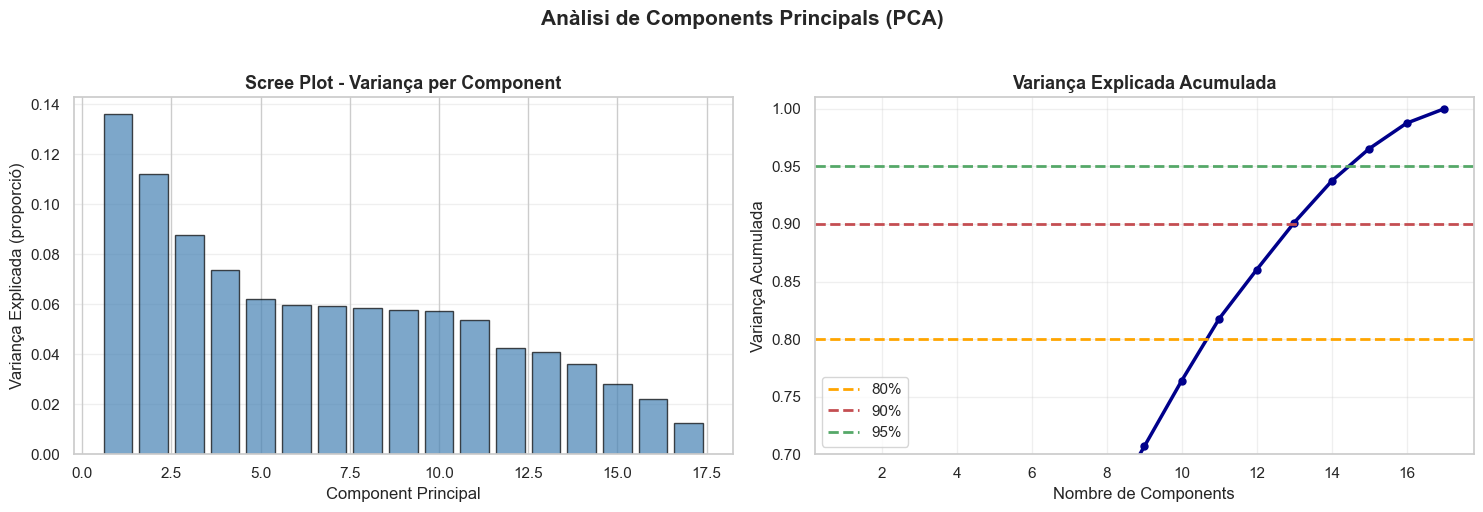

Variança Objectiu  Nº Components Reducció (%)
              80%             11        35.3%
              85%             12        29.4%
              90%             13        23.5%
              95%             15        11.8%
              99%             17         0.0%


In [23]:
from sklearn.decomposition import PCA

numeric_cols_pca = numeric_cols_con_final

pca = PCA()
pca.fit(X_train_scaled[numeric_cols_pca])

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Figura de variança explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot
ax1.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Component Principal', fontsize=12)
ax1.set_ylabel('Variança Explicada (proporció)', fontsize=12)
ax1.set_title('Scree Plot - Variança per Component', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Variança acumulada
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-', linewidth=2.5, markersize=5, color='darkblue')
ax2.axhline(y=0.80, color='orange', linestyle='--', label='80%', linewidth=2)
ax2.axhline(y=0.90, color='r', linestyle='--', label='90%', linewidth=2)
ax2.axhline(y=0.95, color='g', linestyle='--', label='95%', linewidth=2)
ax2.set_xlabel('Nombre de Components', fontsize=12)
ax2.set_ylabel('Variança Acumulada', fontsize=12)
ax2.set_title('Variança Explicada Acumulada', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.7, 1.01])

fig.suptitle('Anàlisi de Components Principals (PCA)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
results_pca = []
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    pct_reduction = (1 - n_components / len(numeric_cols_pca)) * 100
    results_pca.append({
        'Variança Objectiu': f'{threshold:.0%}',
        'Nº Components': n_components,
        'Reducció (%)': f'{pct_reduction:.1f}%'
    })

results_pca_df = pd.DataFrame(results_pca)
print(results_pca_df.to_string(index=False))

**Caption Figura 7:** Anàlisi de Components Principals (PCA). El scree plot (esquerra) detalla la proporció de variància explicada per cada component individual, mentre que el gràfic de la dreta mostra la variància acumulada en funció del nombre de components.

## 3 Definició de models

En aquesta secció entrenem 3 models diferents per predir TRS:
1. **Support Vector Machine (SVM)**
2. **XGBoost**  
3. **Regressió Logística Custom** (amb descens de gradient minibatch)



### 3.1 Definició de mètriques

**Macro F1-Score** com a mètrica principal:

$$\text{Macro F1} = \frac{F1_{\text{NTRS}} + F1_{\text{TRS}}}{2}$$

On cada F1 per classe es calcula com:
$$F1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Tracta les dues classes per igual, ideal per datasets desbalancejats. Garanteix que el model funcioni bé tant per NTRS (majoritària) com per TRS (minoritària).

**Estratègia de validació:** S'utilitza **Stratified 5-Fold Cross-Validation** per garantir que cada conjunt de validació mantingui la proporció original de la classe TRS (31.5%).

**Mètriques addicionals de referència:**
- **Recall (Sensibilitat):** Mètrica clínicament prioritària per minimitzar falsos negatius
- **Precision:** De les prediccions TRS, quantes són correctes?
- **Specificity:** De les NTRS reals, quantes identifiquem correctament?
- **ROC-AUC / PR-AUC:** Capacitat de discriminació global del model

**Optimització:** Els models s'ajustaran cercant el **màxim Macro F1-Score** en cross-validation. Posteriorment, s'analitzarà la corba Precision-Recall per seleccionar el threshold òptim.

In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_recall_curve, auc)
import matplotlib.pyplot as plt


def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model"):

    # Prediccions base (threshold 0.5)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        y_train_proba = model.predict_proba(X_train)[:, 1]
    elif hasattr(model, "decision_function"):
        y_val_proba = model.decision_function(X_val)
        y_train_proba = model.decision_function(X_train)
    else:
        y_val_proba = None
        y_train_proba = None

    results = {
        'Model': model_name,
        # Mètriques de Train
        'Train_Macro_F1': f1_score(y_train, y_train_pred, average='macro'),
        'Train_F1_TRS': f1_score(y_train, y_train_pred),
        'Train_Recall': recall_score(y_train, y_train_pred),
        'Train_Precision': precision_score(y_train, y_train_pred),
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        # Mètriques de Validation
        'Val_Macro_F1': f1_score(y_val, y_val_pred, average='macro'),
        'Val_F1_TRS': f1_score(y_val, y_val_pred),
        'Val_Recall': recall_score(y_val, y_val_pred),
        'Val_Precision': precision_score(y_val, y_val_pred),
        'Val_Accuracy': accuracy_score(y_val, y_val_pred),
    }

    if y_val_proba is not None:
        results['Val_ROC_AUC'] = roc_auc_score(y_val, y_val_proba)
        precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba)
        results['Val_PR_AUC'] = auc(recall_curve, precision_curve)
        results['Train_ROC_AUC'] = roc_auc_score(y_train, y_train_proba)

    print(f"\n{'='*60}")
    print(f"AVALUACIÓ: {model_name}")
    print(f"{'='*60}")
    print(f"MACRO F1: {results['Val_Macro_F1']:.4f}")
    print(f"\nClassification Report (Validation):")
    print(classification_report(y_val, y_val_pred, target_names=['NTRS', 'TRS']))

    # Matriu de Confusió
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NTRS', 'TRS'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'Matriu de Confusió - {model_name}')
    plt.grid(False)
    plt.show()

    return results

## 3.2 Model 1: Support Vector Machine (SVM)

Les **Support Vector Machines (SVM)** són models de classificació que busquen l'hiperplà òptim que maximitza el marge entre classes. L'objectiu és trobar la frontera de decisió que separa les classes amb el màxim marge possible, on els **support vectors** són els punts més propers a aquesta frontera i defineixen el model.

#### Hiperparàmetres a ajustar

| Hiperparàmetre | Valors | Descripció |
|----------------|--------|------------|
| `kernel` | `['linear', 'rbf']` | Tipus de kernel per transformar l'espai de característiques |
| `C` | `np.logspace(-2, 2, 7)` | Regularització (0.01 a 100). $C$ petit → marge ampli, $C$ gran → marge estret |
| `gamma` | `np.logspace(-3, 1, 6)` | Només RBF (0.001 a 10). Defineix la influència de cada punt |
| `class_weight` | `['balanced', {0:1, 1:2}]` | Gestió del desbalanceig de classes |

Utilitzem escales logarítmiques (`np.logspace`) per explorar eficientment un rang ampli de valors.

#### Estratègia d'entrenament

1. **Pipeline**: Encadenem preprocessament (imputació → normalització → codificació) amb SVM, garantint que cada fold de CV aplica transformacions només amb dades d'entrenament.

2. **GridSearchCV**: Cerca exhaustiva amb validació creuada estratificada (5 folds) per trobar la millor combinació d'hiperparàmetres.

3. **Mètrica d'optimització**: **Macro F1-Score**, que tracta les dues classes per igual i garanteix bon rendiment tant en NTRS com en TRS.

In [255]:
# Identifiquem les columnes numèriques i categòriques
categorical_cols_original = ['Ethnicity', 'CYP2D6_metabolic_phenotype']
numeric_cols_original = [col for col in X_train.columns if col not in categorical_cols_original]

# Eliminem Ki_associative_striatum per redundància (ja decidit a secció 2.3)
numeric_cols_original = [col for col in numeric_cols_original if col != 'Ki_associative_striatum']

numeric_cols_bin = [col for col in numeric_cols_original if X_train[col].nunique() <= 2]
numeric_cols_con = [col for col in numeric_cols_original if X_train[col].nunique() > 2]

print(f"Variables numèriques contínues: {len(numeric_cols_con)}")
print(f"Variables numèriques binàries: {len(numeric_cols_bin)}")
print(f"Variables categòriques: {len(categorical_cols_original)}")

Variables numèriques contínues: 17
Variables numèriques binàries: 6
Variables categòriques: 2


In [256]:
# Creem el preprocessador amb ColumnTransformer

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_con', numeric_transformer, numeric_cols_con),
        ('num_bin', binary_transformer, numeric_cols_bin),
        ('cat', categorical_transformer, categorical_cols_original)
    ])

# Pipeline complet: preprocessador + SVM
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True))
])

In [ ]:
# Definim la graella d'hiperparàmetres
C_range = np.logspace(-2, 2, 7)  # De 0.01 a 100 (7 valors)
gamma_range = np.logspace(-3, 1, 6)  # De 0.001 a 10 (6 valors)

print(f"Rang de C: {C_range.min():.4f} a {C_range.max():.1f}")
print(f"Rang de gamma: {gamma_range.min():.4f} a {gamma_range.max():.1f}")

param_grid_svm = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': C_range,
        'classifier__class_weight': ['balanced', {0:1, 1:2}]
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': C_range,
        'classifier__gamma': gamma_range,
        'classifier__class_weight': ['balanced', {0:1, 1:2}]
    }
]

# GridSearchCV
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='f1_macro',  # Optimitzem Macro F1-score
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Calculem combinacions
n_linear = len(C_range) * 2  # 2 class_weight
n_rbf = len(C_range) * len(gamma_range) * 2
n_total = n_linear + n_rbf
print(f"\nTotal de combinacions: {n_total}")
print(f"  - Kernel linear: {n_linear} combinacions")
print(f"  - Kernel RBF: {n_rbf} combinacions")
print(f"  - Total fits: {n_total * 5} fits")

Rang de C: 0.0100 a 100.0
Rang de gamma: 0.0010 a 10.0

Total de combinacions: 98
  - Kernel linear: 14 combinacions
  - Kernel RBF: 84 combinacions
  - Total fits: 490 fits


In [177]:
# Entrenem el model
import time
start_time = time.time()
grid_svm.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Temps d'entrenament: {training_time:.1f} segons")
print(f"\nMillor Macro-F1: {grid_svm.best_score_:.4f}")
print(f"\nMillors hiperparàmetres:")
for param, value in grid_svm.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 98 candidates, totalling 490 fits
Temps d'entrenament: 1561.6 segons

Millor Macro-F1: 0.5977

Millors hiperparàmetres:
  classifier__C: 0.046415888336127774
  classifier__class_weight: {0: 1, 1: 2}
  classifier__gamma: 0.00630957344480193
  classifier__kernel: rbf


#### 3.2.1 Anàlisi de Resultats del Grid Search

In [ ]:
# Extraiem resultats del GridSearch
results_df = pd.DataFrame(grid_svm.cv_results_)

# Seleccionem columnes rellevants
cols_to_show = ['param_classifier__kernel', 'param_classifier__C', 
                'param_classifier__gamma', 'param_classifier__class_weight',
                'mean_test_score', 'std_test_score', 'rank_test_score']

results_summary = results_df[cols_to_show].sort_values('rank_test_score')

results_summary.head(10)

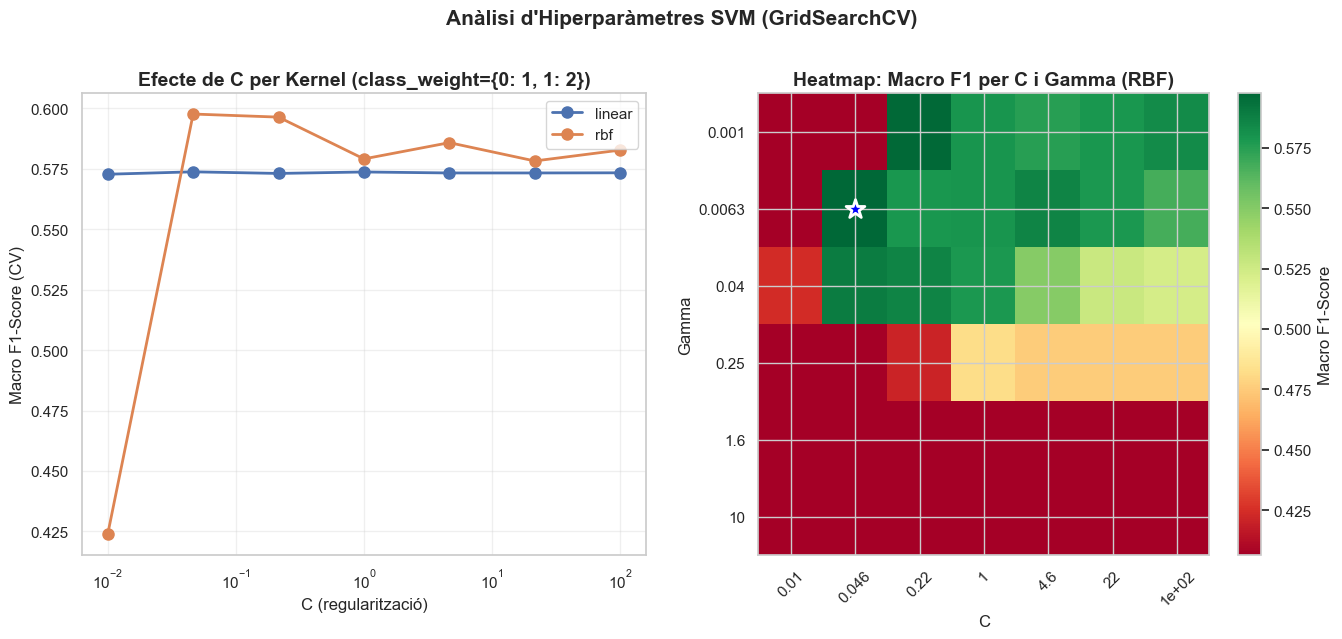

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualització: Heatmap per kernel RBF (C vs Gamma)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Macro F1-Score vs C per cada kernel (millor class_weight trobat)
ax1 = axes[0]
for kernel in ['linear', 'rbf']:
    kernel_results = results_df[results_df['param_classifier__kernel'] == kernel]
    # Agrupem per C i mostrem el millor
    mask = kernel_results['param_classifier__class_weight'].apply(str) == "{0: 1, 1: 2}"
    data = kernel_results[mask].groupby('param_classifier__C')['mean_test_score'].max()
    ax1.plot(data.index, data.values, marker='o', label=f'{kernel}', linewidth=2, markersize=8)

ax1.set_xlabel('C (regularització)', fontsize=12)
ax1.set_ylabel('Macro F1-Score (CV)', fontsize=12)
ax1.set_title('Efecte de C per Kernel (class_weight={0: 1, 1: 2})', fontsize=14, fontweight='bold')
ax1.set_xscale('log')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Subplot 2: Heatmap C vs Gamma per RBF (millor class_weight trobat)
ax2 = axes[1]
rbf_results = results_df[results_df['param_classifier__kernel'] == 'rbf']
rbf_best = rbf_results[rbf_results['param_classifier__class_weight'].apply(str) == "{0: 1, 1: 2}"]
if len(rbf_best) < 5:
    rbf_best = rbf_results[rbf_results['param_classifier__class_weight'].apply(str) == 'balanced']

pivot = rbf_best.pivot_table(
    values='mean_test_score',
    index='param_classifier__gamma',
    columns='param_classifier__C',
    aggfunc='mean'
)

im = ax2.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_yticks(range(len(pivot.index)))
ax2.set_xticklabels([f'{x:.2g}' for x in pivot.columns], rotation=45)
ax2.set_yticklabels([f'{y:.2g}' for y in pivot.index])
ax2.set_xlabel('C', fontsize=12)
ax2.set_ylabel('Gamma', fontsize=12)
ax2.set_title('Heatmap: Macro F1 per C i Gamma (RBF)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Macro F1-Score')

max_idx = np.unravel_index(np.argmax(pivot.values), pivot.values.shape)
ax2.scatter(max_idx[1], max_idx[0], color='blue', s=200, marker='*', edgecolors='white', linewidths=2)

fig.suptitle('Anàlisi d\'Hiperparàmetres SVM (GridSearchCV)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.show()
plt.tight_layout()

**Caption Figura 8**: Esquerra: Macro F1-Score en validació creuada segons el valor de C per cada kernel amb class_weight={0:1, 1:2}. Dreta: Heatmap mostrant la interacció entre C i gamma pel kernel RBF amb class_weight={0:1, 1:2}. L'estrella blava indica la combinació òptima.


#### 3.2.2 Diagnòstic de Bias-Variança: Learning Curve

La **Learning Curve** ens permet diagnosticar si el model pateix de **bias alt** (underfitting) o **variança alta** (overfitting).

Gap final (Train - Val): 0.0063
Bon equilibri bias-variança


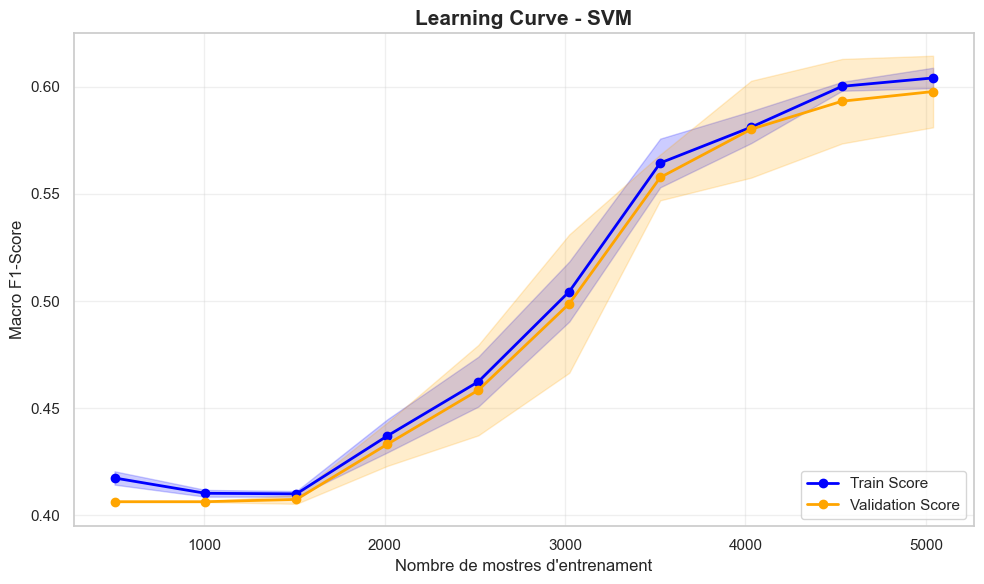

In [180]:
from sklearn.model_selection import learning_curve

# Obtenim el millor model
best_svm = grid_svm.best_estimator_

# Calculem la learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_svm, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

# Calculem mitjanes i desviacions
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Visualització
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Score', linewidth=2)
ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Score', linewidth=2)

ax.set_xlabel('Nombre de mostres d\'entrenament', fontsize=12)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Learning Curve - SVM', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Diagnòstic
gap = train_mean[-1] - val_mean[-1]
print(f"Gap final (Train - Val): {gap:.4f}")
if gap > 0.1:
    print("Possible OVERFITTING: El model s'ajusta massa a les dades d'entrenament")
elif val_mean[-1] < 0.5:
    print("Possible UNDERFITTING: El model és massa simple")
else:
    print("Bon equilibri bias-variança")

plt.tight_layout()
plt.show()

**Caption Figura 9**: Learning curve del millor model SVM. La zona ombrejada representa ±1 desviació estàndard. Un gap petit entre train i validation indica bona generalització. Si les corbes convergeixen quan augmentem les dades, el model es beneficiaria de més mostres.

#### 3.2.3 Validation Curve: Efecte del paràmetre C

La **Validation Curve** mostra com varia el rendiment del model en funció d'un hiperparàmetre específic. Permet:
- Identificar el rang òptim de l'hiperparàmetre
- Detectar underfitting (C massa baix) o overfitting (C massa alt)

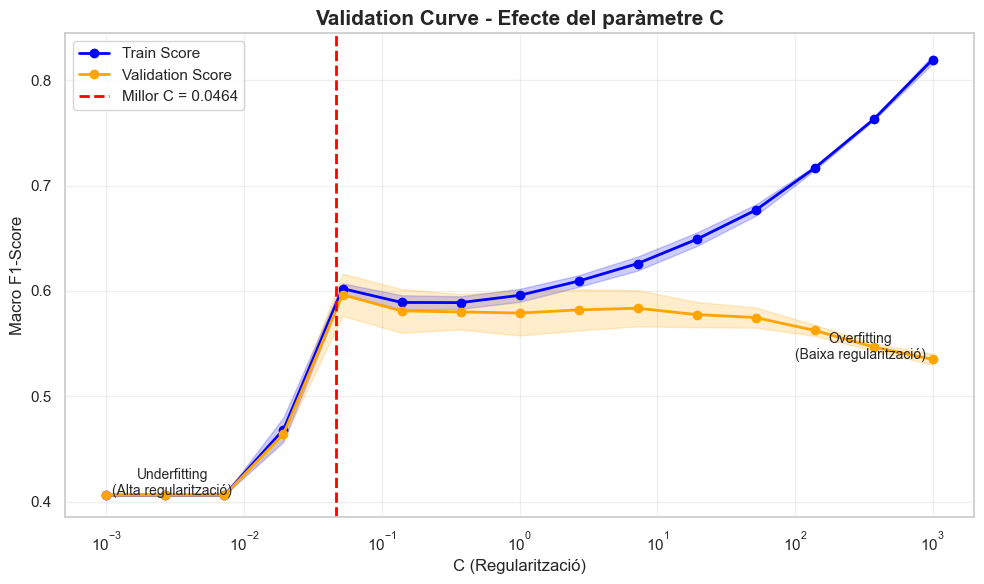

In [181]:
from sklearn.model_selection import validation_curve

# Validation curve per al paràmetre C
C_range_vc = np.logspace(-3, 3, 15)

train_scores_vc, val_scores_vc = validation_curve(
    best_svm, X_train, y_train,
    param_name='classifier__C',
    param_range=C_range_vc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',  # Mètrica oficial Kaggle
    n_jobs=-1
)

# Calculem mitjanes i desviacions
train_mean_vc = np.mean(train_scores_vc, axis=1)
train_std_vc = np.std(train_scores_vc, axis=1)
val_mean_vc = np.mean(val_scores_vc, axis=1)
val_std_vc = np.std(val_scores_vc, axis=1)

# Visualització
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(C_range_vc, train_mean_vc - train_std_vc, train_mean_vc + train_std_vc, alpha=0.2, color='blue')
ax.fill_between(C_range_vc, val_mean_vc - val_std_vc, val_mean_vc + val_std_vc, alpha=0.2, color='orange')
ax.plot(C_range_vc, train_mean_vc, 'o-', color='blue', label='Train Score', linewidth=2)
ax.plot(C_range_vc, val_mean_vc, 'o-', color='orange', label='Validation Score', linewidth=2)

# Marquem el millor C
best_C = grid_svm.best_params_['classifier__C']
ax.axvline(x=best_C, color='red', linestyle='--', linewidth=2, label=f'Millor C = {best_C:.3g}')

ax.set_xlabel('C (Regularització)', fontsize=12)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_xscale('log')
ax.set_title('Validation Curve - Efecte del paràmetre C', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Anotacions
ax.annotate('Underfitting\n(Alta regularització)', xy=(0.003, val_mean_vc[0]), fontsize=10, ha='center')
ax.annotate('Overfitting\n(Baixa regularització)', xy=(300, val_mean_vc[-1]), fontsize=10, ha='center')

plt.tight_layout()
plt.show()

**Caption Figura 10**: Validation curve mostrant l'efecte del paràmetre C en el rendiment. A l'esquerra (C baix), el model subajusta per excessiva regularització. A la dreta (C alt), pot sobreajustar. La línia vermella indica el valor òptim de C seleccionat per GridSearchCV.

#### 3.2.4 Avaluació del millor model SVM

Avaluem el model amb els millors hiperparàmetres trobats durant el GridSearch.
Analitzem també la complexitat del model a través del nombre de Support Vectors. Un percentatge alt de SV indica que molts punts són rellevants per definir la frontera de decisió.


AVALUACIÓ: SVM
MACRO F1: 0.5802

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.75      0.65      0.70      1849
         TRS       0.41      0.53      0.46       851

    accuracy                           0.61      2700
   macro avg       0.58      0.59      0.58      2700
weighted avg       0.64      0.61      0.62      2700



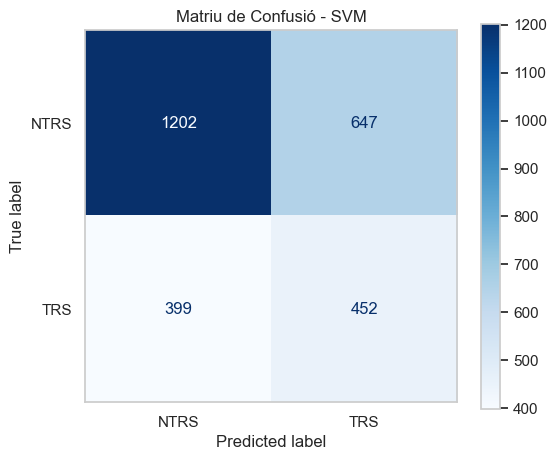

ANÀLISI DE SUPPORT VECTORS
Support Vectors per classe:
  - Classe 0 (NTRS): 3849 vectors
  - Classe 1 (TRS):  1923 vectors
  - Total:           5772 vectors (91.6% de les dades d'entrenament)

RESULTATS MODEL SVM
Model  Train_Macro_F1  Train_F1_TRS  Train_Recall  Train_Precision  Train_Accuracy  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision  Val_Accuracy  Val_ROC_AUC  Val_PR_AUC  Train_ROC_AUC
  SVM        0.598429      0.486117      0.555108         0.432379        0.629841      0.580201     0.46359     0.53114       0.411283      0.612593     0.630405    0.417106       0.654815


In [182]:
# Avaluem el millor model
best_svm = grid_svm.best_estimator_
svm_results = evaluate_model(best_svm, X_train, y_train, X_val, y_val, "SVM")

# Informació sobre Support Vectors
svm_classifier = best_svm.named_steps['classifier']
n_support_vectors = svm_classifier.n_support_
total_sv = sum(n_support_vectors)

print("="*80)
print("ANÀLISI DE SUPPORT VECTORS")
print("="*80)
print(f"Support Vectors per classe:")
print(f"  - Classe 0 (NTRS): {n_support_vectors[0]} vectors")
print(f"  - Classe 1 (TRS):  {n_support_vectors[1]} vectors")
print(f"  - Total:           {total_sv} vectors ({total_sv/len(X_train)*100:.1f}% de les dades d'entrenament)")

# Mostrem resultats de mètriques
print("\n" + "="*80)
print("RESULTATS MODEL SVM")
print("="*80)
results_svm_df = pd.DataFrame([svm_results])
print(results_svm_df.to_string(index=False))

**Caption Figura 11:** Matriu de confusió de l'avaluació del millor model SVM (Support Vector Machine).

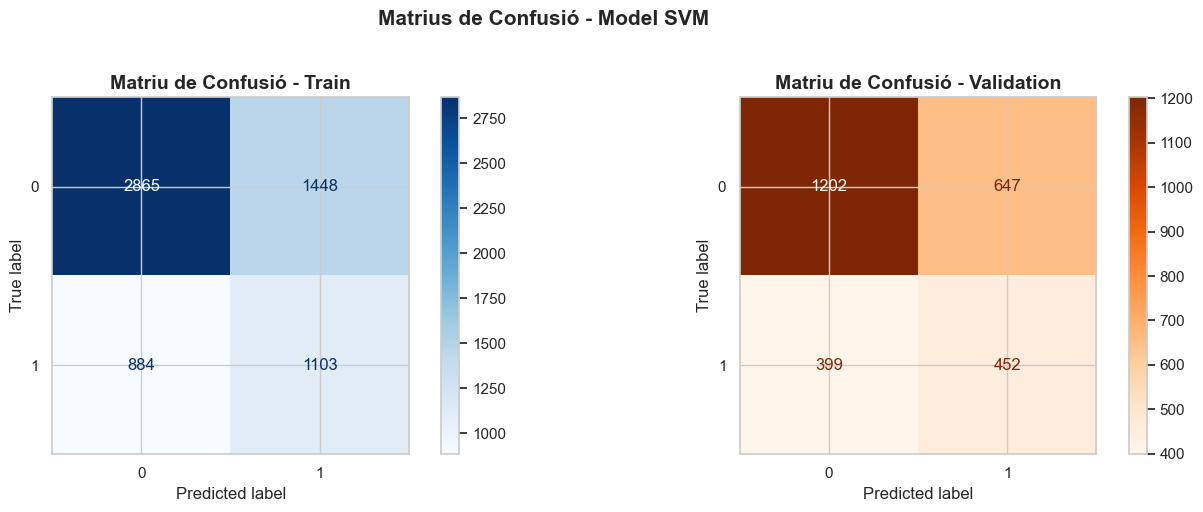

In [183]:
# Matriu de confusió
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
y_train_pred = best_svm.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Matriu de Confusió - Train', fontsize=14, fontweight='bold')

# Validation
y_val_pred = best_svm.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, ax=axes[1], cmap='Oranges')
axes[1].set_title('Matriu de Confusió - Validation', fontsize=14, fontweight='bold')

fig.suptitle('Matrius de Confusió - Model SVM', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Caption Figura 12**: Comparació de matrius de confusió per train (esquerra) i validation (dreta). Diagonals representen prediccions correctes. 

C:\Users\berta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


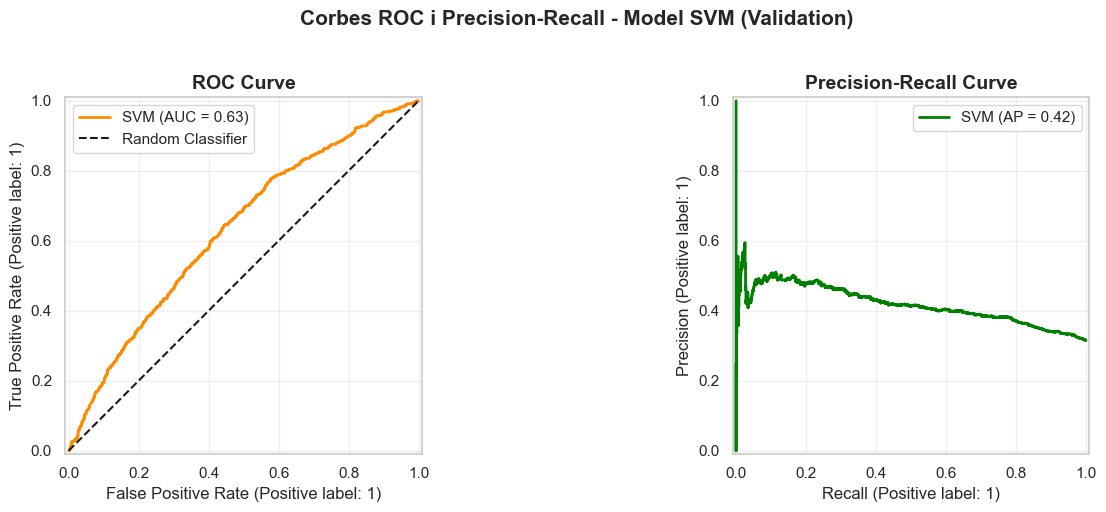


ROC-AUC Score (Validation): 0.6304
PR-AUC Score (Validation):  0.4171


In [184]:
# Corba ROC i PR-AUC
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

y_val_proba = best_svm.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=axes[0], name='SVM', color='darkorange', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_val, y_val_proba, ax=axes[1], name='SVM', color='green', linewidth=2)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Corbes ROC i Precision-Recall - Model SVM (Validation)', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score (Validation): {svm_results['Val_ROC_AUC']:.4f}")
print(f"PR-AUC Score (Validation):  {svm_results['Val_PR_AUC']:.4f}")

**Caption Figura 13**: Esquerra: Corba ROC que avalua la capacitat discriminativa del model (AUC=0.63). Dreta: Corba Precision-Recall, especialment important per a datasets desbalancejats. PR-AUC (0.41).

#### 3.2.5 Cerca a la zona òptima

Basant-nos en els resultats del GridSearch amb **StandardScaler**, la zona òptima es troba amb:

- **C ≈ 0.046**: Alta regularització per evitar overfitting
- **gamma ≈ 0.0063**: Molt baix, comportament quasi-lineal amb marges de decisió molt suaus
- **class_weight = {0:1, 1:2}**: Penalització moderada per la classe TRS (millor que 'balanced')

Fem una cerca fina al voltant d'aquests valors per intentar millorar el model.

In [ ]:
C_fine = [0.02, 0.03, 0.046, 0.065, 0.1]  # Explorar al voltant de C=0.046
gamma_fine = [0.003, 0.005, 0.0063, 0.008, 0.012]  # Explorar al voltant de gamma=0.0063

param_grid_fine = {
    'classifier__kernel': ['rbf'],
    'classifier__C': C_fine,
    'classifier__gamma': gamma_fine,
    'classifier__class_weight': [{0: 1, 1: 2}, {0: 1, 1: 2.5}]  # Comparar variacions de manual
}

# Cerca amb GridSearchCV
grid_svm_fine = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_fine,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Entrenem el model
start_time = time.time()
grid_svm_fine.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Temps d'entrenament: {training_time:.1f} segons")
print(f"\nMillor Macro-F1: {grid_svm_fine.best_score_:.4f}")
print(f"\nMillors hiperparàmetres:")
for param, value in grid_svm_fine.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Temps d'entrenament: 484.9 segons

Millor Macro-F1: 0.5981

Millors hiperparàmetres:
  classifier__C: 0.03
  classifier__class_weight: {0: 1, 1: 2}
  classifier__gamma: 0.012
  classifier__kernel: rbf


In [186]:
from sklearn.metrics import f1_score

# Comparem els dos millors estimators obtinguts
y_val_pred_initial = grid_svm.best_estimator_.predict(X_val)
y_val_pred_fine = grid_svm_fine.best_estimator_.predict(X_val)

macro_f1_initial = f1_score(y_val, y_val_pred_initial, average='macro')
macro_f1_fine = f1_score(y_val, y_val_pred_fine, average='macro')

print("="*60)
print("COMPARACIÓ FINAL: Inicial vs Segona Cerca")
print("="*60)
print(f"GridSearch Inicial   - Val Macro F1: {macro_f1_initial:.4f}")
print(f"Cerca en zona òptima - Val Macro F1: {macro_f1_fine:.4f}")
print(f"Diferència: {(macro_f1_fine - macro_f1_initial)*100:+.2f}%")

# Escollim el model amb millor Macro F1 en VALIDACIÓ
if macro_f1_initial >= macro_f1_fine:
    best_svm = grid_svm.best_estimator_
    print(f"\nModel escollit: GridSearch Inicial (millor generalització)")
else:
    best_svm = grid_svm_fine.best_estimator_
    print(f"\nModel escollit: Cerca en zona òptima (millor generalització)")

COMPARACIÓ FINAL: Inicial vs Segona Cerca
GridSearch Inicial   - Val Macro F1: 0.5802
Cerca en zona òptima - Val Macro F1: 0.5796
Diferència: -0.06%

Model escollit: GridSearch Inicial (millor generalització)


#### 3.2.6 Optimització del Threshold de classificació

Per defecte, SVM utilitza un threshold de 0.5 per classificar. Podem optimitzar-lo per maximitzar el Macro F1-Score.

In [264]:
# Anàlisi de thresholds per SVM
import joblib
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

# Usem el millor model SVM seleccionat
y_val_proba_svm = best_svm.predict_proba(X_val)[:, 1]

thresholds_to_test = np.arange(0.30, 0.70, 0.02)
results_threshold_svm = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_val_proba_svm >= thresh).astype(int)
    f1_trs = f1_score(y_val, y_pred_thresh, pos_label=1)
    f1_ntrs = f1_score(y_val, y_pred_thresh, pos_label=0)
    macro_f1 = (f1_trs + f1_ntrs) / 2
    results_threshold_svm.append({
        'Threshold': thresh,
        'Macro_F1': macro_f1,
        'F1_TRS': f1_trs,
        'Recall_TRS': recall_score(y_val, y_pred_thresh, pos_label=1),
        'Precision_TRS': precision_score(y_val, y_pred_thresh, pos_label=1, zero_division=0)
    })

df_thresh_svm = pd.DataFrame(results_threshold_svm)
best_thresh_svm = df_thresh_svm.loc[df_thresh_svm['Macro_F1'].idxmax()]
default_row_svm = df_thresh_svm.iloc[(df_thresh_svm['Threshold'] - 0.50).abs().idxmin()]
default_macro_f1_svm = default_row_svm['Macro_F1']

print(f"Millor Threshold: {best_thresh_svm['Threshold']:.2f}")
print(f"Macro F1 amb threshold òptim: {best_thresh_svm['Macro_F1']:.4f}")
print(f"Macro F1 amb threshold 0.5:   {default_macro_f1_svm:.4f}")
print(f"Millora: {(best_thresh_svm['Macro_F1'] - default_macro_f1_svm)*100:+.2f}%")
print(f"\nTop 5 millors thresholds:")
print(df_thresh_svm.nlargest(5, 'Macro_F1').to_string(index=False))

# Guardem els resultats finals de SVM
svm_results = {
    'Model': 'SVM',
    'Val_Macro_F1': best_thresh_svm['Macro_F1'],
    'Val_F1_TRS': best_thresh_svm['F1_TRS'],
    'Val_Recall': best_thresh_svm['Recall_TRS'],
    'Val_Precision': best_thresh_svm['Precision_TRS'],
    'Val_Accuracy': f1_score(y_val, y_val_pred_initial, average='macro'),
    'Best_Threshold': best_thresh_svm['Threshold']}

Millor Threshold: 0.36
Macro F1 amb threshold òptim: 0.5829
Macro F1 amb threshold 0.5:   0.5047
Millora: +7.82%

Top 5 millors thresholds:
 Threshold  Macro_F1   F1_TRS  Recall_TRS  Precision_TRS
      0.36  0.582890 0.461619    0.519389       0.415414
      0.38  0.579475 0.434783    0.452409       0.418478
      0.40  0.578488 0.410351    0.391304       0.431347
      0.42  0.572631 0.380632    0.332550       0.444969
      0.34  0.571798 0.471725    0.573443       0.400657


In [ ]:
# Desem al disc el model final

joblib.dump(best_svm, 'svm_final_model.joblib')
joblib.dump(svm_results, 'svm_final_results.joblib')
df_thresh_svm.to_csv('svm_threshold_analysis.csv', index=False)

## 3.3 Model 2: Extreme Gradient Boosting (XGBoost)

**XGBoost** (Extreme Gradient Boosting) és un algorisme d'ensemble que entrena arbres de decisió **seqüencialment**, on cada nou arbre corregeix els errors dels anteriors. A diferència de Random Forest (arbres en paral·lel), XGBoost utilitza **boosting** per minimitzar progressivament una funció de pèrdua.

#### Fonaments Teòrics

**Model Additiu**: Les prediccions es construeixen iterativament:

$$\hat{y}_i^{(t)} = \sum_{k=1}^{t} f_k(x_i)$$

on $f_k$ és el $k$-èsim arbre i cada nou arbre s'ajusta als **residus** (errors) del model anterior.

**Funció Objectiu amb Regularització**:

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

on:
- $l(y_i, \hat{y}_i)$ és la funció de pèrdua (log-loss per classificació)
- $\Omega(f_k) = \gamma T + \frac{1}{2}\lambda ||w||^2$ és la regularització
- $T$ és el nombre de fulles, $w$ són els pesos de les fulles

**Shrinkage (Learning Rate)**: Cada arbre es pondera per $\eta$ (0 < $\eta$ ≤ 1):

$$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta \cdot f_t(x_i)$$

Valors baixos de $\eta$ requereixen més arbres però milloren la generalització.

Treballarem amb les dades preprocessades (secció 2): `X_train_final`, `X_val_final`.

#### 3.3.1 Hiperparàmetres a ajustar

| Hiperparàmetre | Valors | Descripció |
|----------------|--------|------------|
| `n_estimators` | `[100, 200, 300]` | Nombre d'arbres (boosting rounds). Més arbres milloren rendiment però incrementen cost |
| `max_depth` | `[3, 4, 5, 6]` | Profunditat màxima per arbre. Controla complexitat del model |
| `learning_rate` | `[0.01, 0.05, 0.1]` | Taxa de shrinkage. Valors baixos → aprenentatge més estable |
| `min_child_weight` | `[1, 3, 5]` | Suma mínima de pesos en fulles. Major valor → més conservador |
| `subsample` | `[0.7, 0.8, 0.9]` | Fracció de mostres per arbre. Redueix variància |
| `colsample_bytree` | `[0.7, 0.8, 0.9]` | Fracció de features per arbre. Promou diversitat |
| `gamma` | `[0, 0.1, 0.2]` | Guany mínim per fer split. Regularització de complexitat |
| `reg_alpha` | `[0, 0.1, 0.5]` | Regularització L1 (selecció de features) |
| `reg_lambda` | `[1, 1.5, 2]` | Regularització L2 (shrinkage de pesos) |
| `scale_pos_weight` | `[1.5, 2.0, 2.5]` | Pes classe positiva (TRS). Compensa desbalanceig |

**Estratègia d'optimització**:

Utilitzem **RandomizedSearchCV** amb `n_iter=30` per explorar eficientment l'espai d'hiperparàmetres (>100.000 combinacions possibles). Això és més pràctic que GridSearchCV complet.

- **Mètrica**: **Macro F1-Score** (mètrica oficial Kaggle - tracta les dues classes per igual)
- **Validació creuada**: StratifiedKFold amb 5 folds
- **`scale_pos_weight`**: Amb Macro F1, aquest paràmetre pot necessitar ajust diferent respecte a F1-TRS

In [25]:
# 3.3.1 Entrenament i cerca d'hiperparàmetres (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

# Distribució d'hiperparàmetres per RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
    'scale_pos_weight': [1.5, 2.0, 2.5]
}

# Model base XGBoost
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

# RandomizedSearchCV
random_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Entrenament
random_xgb.fit(X_train_final, y_train)

print(f"\nMillor Macro-F1: {random_xgb.best_score_:.4f}")
print("\nMillors hiperparàmetres:")
for param, value in random_xgb.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Millor Macro-F1: 0.5894

Millors hiperparàmetres:
  subsample: 0.8
  scale_pos_weight: 2.0
  reg_lambda: 1.5
  reg_alpha: 0.1
  n_estimators: 100
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 0.7


#### Anàlisi de Resultats del RandomizedSearchCV

In [26]:
# Extraiem resultats del RandomizedSearchCV
results_xgb_df = pd.DataFrame(random_xgb.cv_results_)

cols_xgb = [col for col in results_xgb_df.columns if col.startswith('param_')]
cols_xgb.extend(['mean_test_score', 'std_test_score', 'rank_test_score'])

results_xgb_summary = results_xgb_df[cols_xgb].sort_values('rank_test_score')
print("Top 5 millors combinacions:")
results_xgb_summary.head(5)

Top 5 millors combinacions:


,param_subsample,param_scale_pos_weight,param_reg_lambda,param_reg_alpha,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_gamma,param_colsample_bytree,mean_test_score,std_test_score,rank_test_score
12,0.8,2.0,1.5,0.1,100,1,4,0.01,0.0,0.7,0.589391,0.017185,1
20,0.8,2.0,1.0,0.0,100,5,5,0.01,0.2,0.9,0.587990,0.012997,2
18,0.8,2.0,1.0,0.0,100,5,4,0.01,0.0,0.9,0.586743,0.016283,3
1,0.9,2.0,2.0,0.1,200,1,4,0.01,0.0,0.7,0.586237,0.013601,4
3,0.8,2.0,2.0,0.1,300,1,6,0.01,0.0,0.9,0.586150,0.012611,5


#### 3.3.2 Avaluació del model inicial

Abans de refinar els hiperparàmetres, avaluem el model inicial.


AVALUACIÓ: XGB_Inicial
MACRO F1: 0.5805

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.75      0.67      0.71      1849
         TRS       0.41      0.51      0.45       851

    accuracy                           0.62      2700
   macro avg       0.58      0.59      0.58      2700
weighted avg       0.64      0.62      0.63      2700



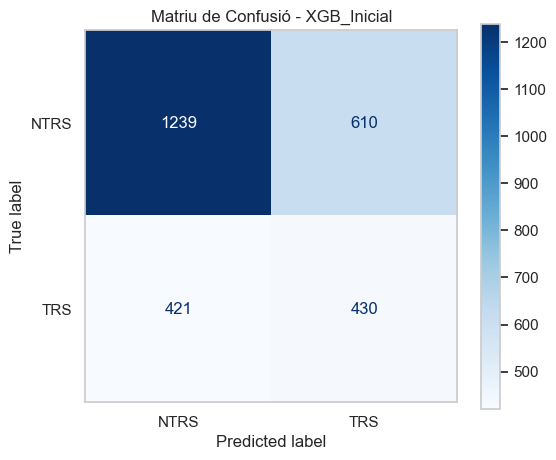


AVALUACIÓ MODEL INICIAL (RandomizedSearchCV)
      Model  Train_Macro_F1  Train_F1_TRS  Train_Recall  Train_Precision  Train_Accuracy  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision  Val_Accuracy  Val_ROC_AUC  Val_PR_AUC  Train_ROC_AUC
XGB_Inicial        0.629087      0.517695      0.574233         0.471293         0.66254      0.580485    0.454786    0.505288       0.413462      0.618148     0.626471     0.41917       0.705417

Anàlisi de Generalització:
   Gap Macro F1: 0.0486 Acceptable
   Gap F1 TRS: 0.0629


In [27]:
# Avaluació del model inicial (RandomizedSearchCV)
best_xgb_initial = random_xgb.best_estimator_

# Avaluem el model inicial
xgb_results_initial = evaluate_model(best_xgb_initial, X_train_final, y_train, 
                                     X_val_final, y_val, "XGB_Inicial")

results_initial_df = pd.DataFrame([xgb_results_initial])
print("\n" + "="*80)
print("AVALUACIÓ MODEL INICIAL (RandomizedSearchCV)")
print("="*80)
print(results_initial_df.to_string(index=False))

# Anàlisi de gaps
gap_macro = xgb_results_initial['Train_Macro_F1'] - xgb_results_initial['Val_Macro_F1']
gap_f1_trs = xgb_results_initial['Train_F1_TRS'] - xgb_results_initial['Val_F1_TRS']

print(f"\nAnàlisi de Generalització:")
print(f"   Gap Macro F1: {gap_macro:.4f} {'Possible overfitting' if gap_macro > 0.05 else 'Acceptable'}")
print(f"   Gap F1 TRS: {gap_f1_trs:.4f}")

#### 3.3.3 Cerca Fina (RandomizedSearchCV)

Basant-nos en els millors hiperparàmetres del RandomizedSearchCV inicial, fem una **segona cerca** al voltant de la zona òptima identificada. Utilitzem **RandomizedSearchCV amb 50 iteracions** mantenint un rang reduït d'hiperparàmetres amb més regularització per reduir l'overfitting.

  Millors hiperparàmetres:
  subsample: 0.8
  scale_pos_weight: 2.0
  reg_lambda: 1.5
  reg_alpha: 0.1
  n_estimators: 100
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 0.7

In [28]:
# 3.3.3 RandomizedSearchCV 2
# Definim un espai de cerca centrat en la zona òptima identificada pel primer RandomizedSearchCV
# Utilitzem RandomizedSearchCV amb 50 iteracions per eficiència

param_dist_fine_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [4, 3],
    'learning_rate': [0.01, 0.02],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7],
    'gamma': [0.1, 0.3, 0.5],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1.5, 2.0],
    'scale_pos_weight': [2.0, 2.5]
}

# Calculem el nombre total de combinacions possibles
n_combinations = 1
for v in param_dist_fine_xgb.values():
    n_combinations *= len(v)
print(f"Espai total de combinacions: {n_combinations}")

xgb_fine = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# RandomizedSearchCV amb 50 iteracions
random_xgb_fine = RandomizedSearchCV(
    xgb_fine, 
    param_dist_fine_xgb, 
    n_iter=50,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_xgb_fine.fit(X_train_final, y_train)    

print(f"Millor Macro F1 (CV): {random_xgb_fine.best_score_:.4f}")

print(f"\nMillors hiperparàmetres (cerca fina):")
for param, value in sorted(random_xgb_fine.best_params_.items()):
    print(f"   {param}: {value}")


Espai total de combinacions: 2304
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Millor Macro F1 (CV): 0.5914

Millors hiperparàmetres (cerca fina):
   colsample_bytree: 0.7
   gamma: 0.5
   learning_rate: 0.01
   max_depth: 4
   min_child_weight: 5
   n_estimators: 100
   reg_alpha: 0.5
   reg_lambda: 1.5
   scale_pos_weight: 2.0
   subsample: 0.7


#### 3.3.4 Comparació Models: Inicial vs Cerca fina

Comparem el model del RandomizedSearchCV inicial amb el model afinat pel segon RandomizedSearchCV (cerca fina amb 50 iteracions) per determinar quin ofereix millor rendiment en validació.


AVALUACIÓ: XGB_Inicial
MACRO F1: 0.5805

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.75      0.67      0.71      1849
         TRS       0.41      0.51      0.45       851

    accuracy                           0.62      2700
   macro avg       0.58      0.59      0.58      2700
weighted avg       0.64      0.62      0.63      2700



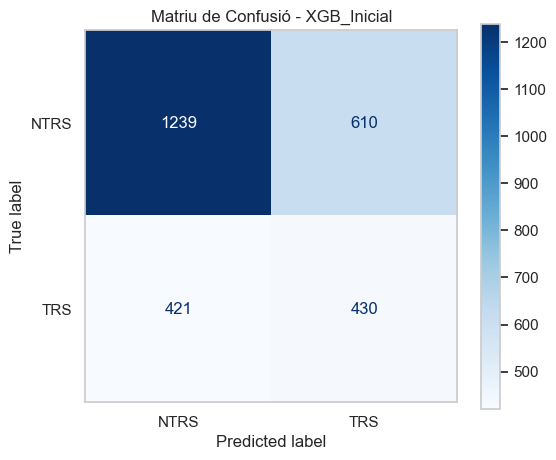


AVALUACIÓ: XGB_FineTuned
MACRO F1: 0.5787

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.74      0.67      0.71      1849
         TRS       0.41      0.50      0.45       851

    accuracy                           0.62      2700
   macro avg       0.58      0.59      0.58      2700
weighted avg       0.64      0.62      0.63      2700



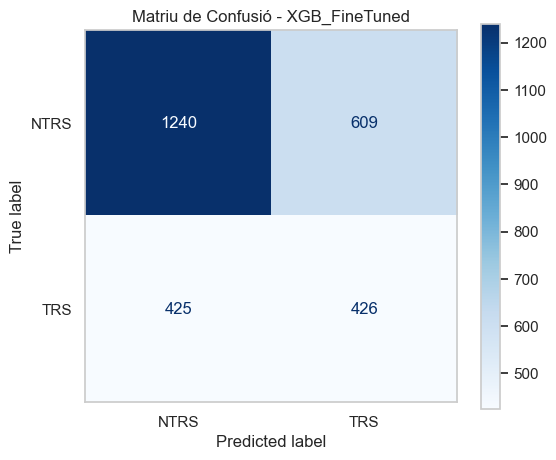


TAULA: COMPARATIVA MODELS XGBOOST
        Model  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision  Val_ROC_AUC  Gap_Macro_F1  Gap_F1_TRS
  XGB_Inicial      0.580485    0.454786    0.505288       0.413462     0.626471      0.048602    0.062909
XGB_FineTuned      0.578749    0.451750    0.500588       0.411594     0.625560      0.055013    0.070921

MILLOR MODEL: XGB_Inicial amb Val_Macro_F1 = 0.5805


In [29]:
# Model 1: RandomizedSearchCV inicial
xgb_results_1 = evaluate_model(random_xgb.best_estimator_, X_train_final, y_train, 
                               X_val_final, y_val, "XGB_Inicial")

# Model 2: RandomizedSearchCV Fine-tuned
xgb_results_2 = evaluate_model(random_xgb_fine.best_estimator_, X_train_final, y_train, 
                               X_val_final, y_val, "XGB_FineTuned")

# Taula comparativa
comparison_df = pd.DataFrame([xgb_results_1, xgb_results_2])
comparison_df['Gap_Macro_F1'] = comparison_df['Train_Macro_F1'] - comparison_df['Val_Macro_F1']
comparison_df['Gap_F1_TRS'] = comparison_df['Train_F1_TRS'] - comparison_df['Val_F1_TRS']

print("\n" + "="*80)
print("TAULA: COMPARATIVA MODELS XGBOOST")
print("="*80)
cols_display = ['Model', 'Val_Macro_F1', 'Val_F1_TRS', 'Val_Recall', 'Val_Precision', 
                'Val_ROC_AUC', 'Gap_Macro_F1', 'Gap_F1_TRS']
print(comparison_df[cols_display].to_string(index=False))

# Identifiquem el millor model
best_idx = comparison_df['Val_Macro_F1'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
print(f"\nMILLOR MODEL: {best_model_name} amb Val_Macro_F1 = {comparison_df.loc[best_idx, 'Val_Macro_F1']:.4f}")

# Seleccionem el millor model
if best_idx == 0:
    best_xgb = random_xgb.best_estimator_
    best_xgb_params = random_xgb.best_params_
else:
    best_xgb = random_xgb_fine.best_estimator_
    best_xgb_params = random_xgb_fine.best_params_

#### 3.3.6 Avaluació del millor model XGBoost

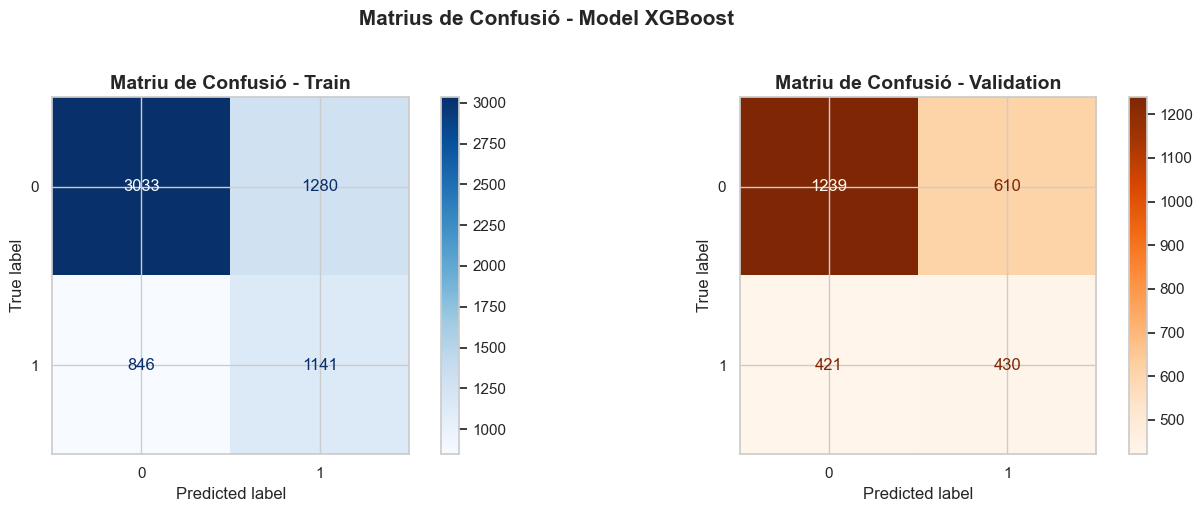

In [280]:
# Matriu de confusió
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
y_train_pred_xgb = best_xgb.predict(X_train_final)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred_xgb, ax=axes[0], cmap='Blues')
axes[0].set_title('Matriu de Confusió - Train', fontsize=14, fontweight='bold')

# Validation
y_val_pred_xgb = best_xgb.predict(X_val_final)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_xgb, ax=axes[1], cmap='Oranges')
axes[1].set_title('Matriu de Confusió - Validation', fontsize=14, fontweight='bold')

fig.suptitle(' Matrius de Confusió - Model XGBoost', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

**Caption Figura 14**: Matrius de confusió per XGBoost en train (esquerra) i validation (dreta). Compara amb SVM per veure quin model minimitza millor els falsos negatius (TRS no detectats).

In [281]:
# Anàlisi d'overfitting/underfitting (gaps Train - Val)

print("ANÀLISI DE GENERALITZACIÓ (Gaps Train - Val)")

train_val_gap_xgb = {
    'Macro_F1 (Kaggle)': xgb_results_1['Train_Macro_F1'] - xgb_results_1['Val_Macro_F1'],
    'F1_TRS': xgb_results_1['Train_F1_TRS'] - xgb_results_1['Val_F1_TRS'],
    'Recall': xgb_results_1['Train_Recall'] - xgb_results_1['Val_Recall'],
    'Precision': xgb_results_1['Train_Precision'] - xgb_results_1['Val_Precision'],
    'Accuracy': xgb_results_1['Train_Accuracy'] - xgb_results_1['Val_Accuracy'],
}

for metric, gap in train_val_gap_xgb.items():
    status = ""
    if abs(gap) < 0.02:
        status = "✓ Bona generalització"
    elif gap > 0.1:
        status = "Possible OVERFITTING"
    elif gap < -0.02:
        status = "Val > Train (revisar)"
    else:
        status = "Acceptable"
    print(f"{metric}: Δ = {gap:+.4f}  {status}")

ANÀLISI DE GENERALITZACIÓ (Gaps Train - Val)
Macro_F1 (Kaggle): Δ = +0.0486  Acceptable
F1_TRS: Δ = +0.0629  Acceptable
Recall: Δ = +0.0689  Acceptable
Precision: Δ = +0.0578  Acceptable
Accuracy: Δ = +0.0444  Acceptable


#### Learning Curve

La Learning Curve ens permet diagnosticar si el model pateix de bias alt (underfitting) o variança alta (overfitting).

Gap final (Train - Val): 0.0533
Bon equilibri bias-variança


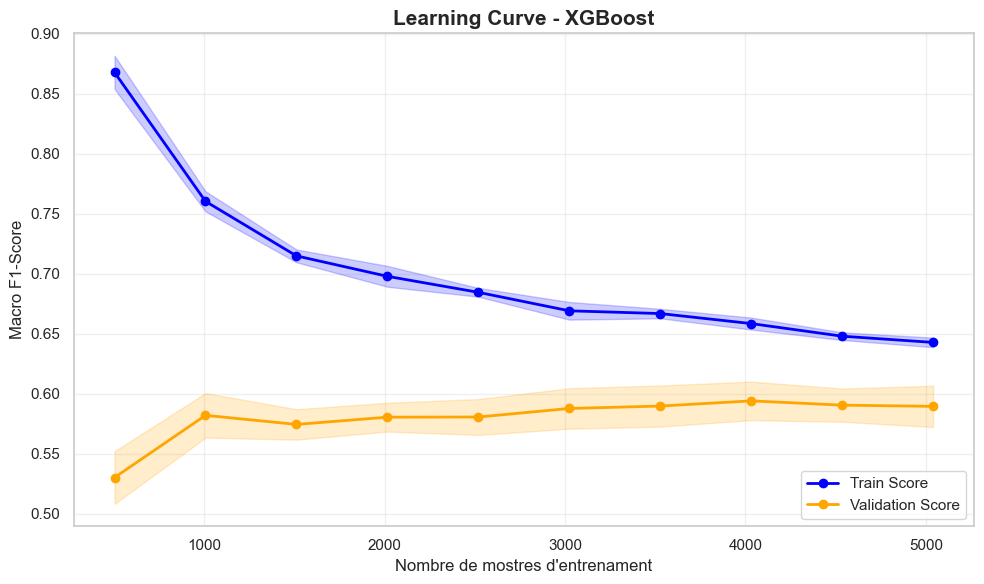

In [283]:
from sklearn.model_selection import learning_curve

# Learning curve per XGBoost
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    best_xgb, X_train_final, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',  # Mètrica oficial Kaggle
    n_jobs=-1
)

# Calculem mitjanes i desviacions
train_mean_xgb = np.mean(train_scores_xgb, axis=1)
train_std_xgb = np.std(train_scores_xgb, axis=1)
val_mean_xgb = np.mean(val_scores_xgb, axis=1)
val_std_xgb = np.std(val_scores_xgb, axis=1)

# Visualització
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes_xgb, train_mean_xgb - train_std_xgb, train_mean_xgb + train_std_xgb, alpha=0.2, color='blue')
ax.fill_between(train_sizes_xgb, val_mean_xgb - val_std_xgb, val_mean_xgb + val_std_xgb, alpha=0.2, color='orange')
ax.plot(train_sizes_xgb, train_mean_xgb, 'o-', color='blue', label='Train Score', linewidth=2)
ax.plot(train_sizes_xgb, val_mean_xgb, 'o-', color='orange', label='Validation Score', linewidth=2)

ax.set_xlabel('Nombre de mostres d\'entrenament', fontsize=12)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Learning Curve - XGBoost', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Diagnòstic
gap_xgb = train_mean_xgb[-1] - val_mean_xgb[-1]
print(f"Gap final (Train - Val): {gap_xgb:.4f}")
if gap_xgb > 0.1:
    print("Possible OVERFITTING: El model s'ajusta massa a les dades d'entrenament")
elif val_mean_xgb[-1] < 0.5:
    print("Possible UNDERFITTING: El model és massa simple")
else:
    print("Bon equilibri bias-variança")

plt.tight_layout()
plt.show()

**Caption Figura 15**: Learning curve del millor model XGBoost. La zona ombrejada representa ±1 desviació estàndard dels 5 folds de cross-validation.


C:\Users\berta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


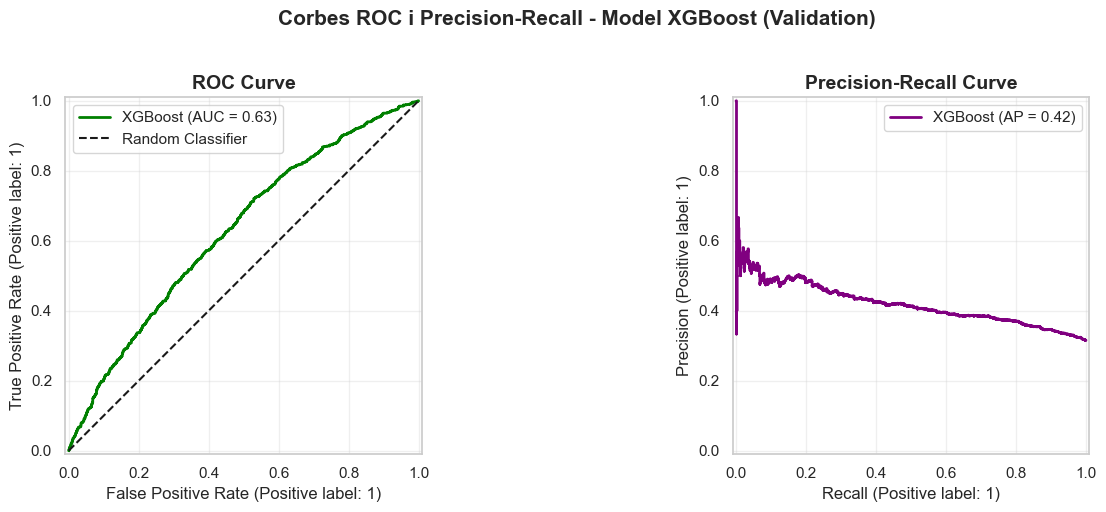


ROC-AUC Score (Validation): 0.6265
PR-AUC Score (Validation):  0.4192


In [284]:
# Corba ROC i PR-AUC
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

y_val_proba_xgb = best_xgb.predict_proba(X_val_final)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_val, y_val_proba_xgb, ax=axes[0], name='XGBoost', color='green', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_val, y_val_proba_xgb, ax=axes[1], name='XGBoost', color='purple', linewidth=2)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Corbes ROC i Precision-Recall - Model XGBoost (Validation)', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score (Validation): {xgb_results_1['Val_ROC_AUC']:.4f}")
print(f"PR-AUC Score (Validation):  {xgb_results_1['Val_PR_AUC']:.4f}")

**Caption Figura 16**: Esquerra: Corba ROC que avalua la capacitat discriminativa del model (AUC=0.63). Dreta: Corba Precision-Recall, especialment important per a datasets desbalancejats. PR-AUC (0.41).

#### 3.3.7 Optimització del threshold 


ANALISI DE THRESHOLDS

Millor Threshold: 0.50
Macro F1 amb threshold optim: 0.5805
Macro F1 amb threshold 0.5: 0.5805
Millora potencial: +0.0000


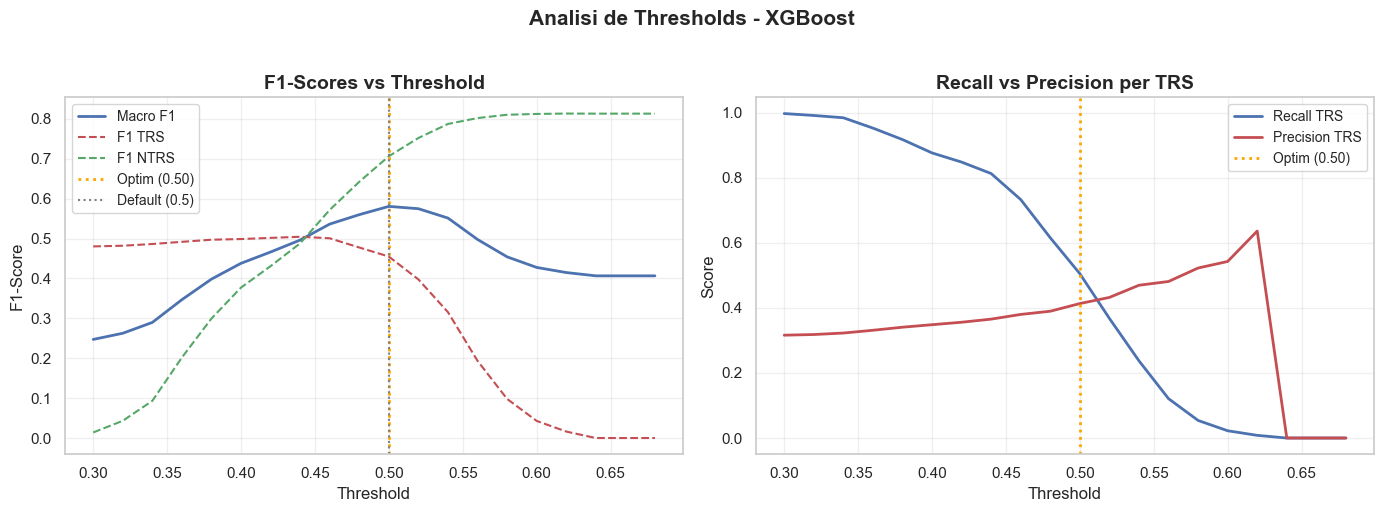


Top 5 millors thresholds:
 Threshold  Macro_F1   F1_TRS  F1_NTRS  Recall_TRS  Precision_TRS
      0.50  0.580485 0.454786 0.706184    0.505288       0.413462
      0.52  0.574678 0.397460 0.751895    0.367803       0.432320
      0.48  0.559785 0.477449 0.642122    0.615746       0.389881
      0.54  0.551231 0.315379 0.787084    0.237368       0.469767
      0.46  0.536163 0.500602 0.571723    0.733255       0.380024


In [266]:
# Analisi de thresholds per optimitzar Macro F1
from sklearn.metrics import f1_score

# Obtenim probabilitats del model
y_val_proba_xgb = best_xgb.predict_proba(X_val_final)[:, 1]

# Provem diferents thresholds (incloent 0.5 explicitament)
thresholds_to_test = np.concatenate([np.arange(0.30, 0.50, 0.02), [0.50], np.arange(0.52, 0.70, 0.02)])
results_threshold = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_val_proba_xgb >= thresh).astype(int)
    
    # Calculem metriques
    f1_ntrs = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_trs = f1_score(y_val, y_pred_thresh, pos_label=1)
    macro_f1 = (f1_ntrs + f1_trs) / 2
    recall_trs = (y_pred_thresh[y_val == 1] == 1).mean()
    precision_trs = (y_val[y_pred_thresh == 1] == 1).mean() if (y_pred_thresh == 1).sum() > 0 else 0
    
    results_threshold.append({
        'Threshold': thresh,
        'Macro_F1': macro_f1,
        'F1_TRS': f1_trs,
        'F1_NTRS': f1_ntrs,
        'Recall_TRS': recall_trs,
        'Precision_TRS': precision_trs
    })

df_thresholds = pd.DataFrame(results_threshold)

# Trobem el millor threshold
best_thresh_idx = df_thresholds['Macro_F1'].idxmax()
best_threshold = df_thresholds.loc[best_thresh_idx, 'Threshold']
best_macro_f1 = df_thresholds.loc[best_thresh_idx, 'Macro_F1']

# Macro F1 amb threshold per defecte (0.5)
default_macro_f1 = df_thresholds[np.isclose(df_thresholds['Threshold'], 0.5)]['Macro_F1'].values[0]

print("="*60)
print("ANALISI DE THRESHOLDS")
print("="*60)
print(f"\nMillor Threshold: {best_threshold:.2f}")
print(f"Macro F1 amb threshold optim: {best_macro_f1:.4f}")
print(f"Macro F1 amb threshold 0.5: {default_macro_f1:.4f}")
print(f"Millora potencial: {best_macro_f1 - default_macro_f1:+.4f}")

# Visualitzacio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macro F1 vs Threshold
ax1 = axes[0]
ax1.plot(df_thresholds['Threshold'], df_thresholds['Macro_F1'], 'b-', linewidth=2, label='Macro F1')
ax1.plot(df_thresholds['Threshold'], df_thresholds['F1_TRS'], 'r--', linewidth=1.5, label='F1 TRS')
ax1.plot(df_thresholds['Threshold'], df_thresholds['F1_NTRS'], 'g--', linewidth=1.5, label='F1 NTRS')
ax1.axvline(x=best_threshold, color='orange', linestyle=':', linewidth=2, label=f'Optim ({best_threshold:.2f})')
ax1.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default (0.5)')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('F1-Score', fontsize=12)
ax1.set_title('F1-Scores vs Threshold', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Recall vs Precision
ax2 = axes[1]
ax2.plot(df_thresholds['Threshold'], df_thresholds['Recall_TRS'], 'b-', linewidth=2, label='Recall TRS')
ax2.plot(df_thresholds['Threshold'], df_thresholds['Precision_TRS'], 'r-', linewidth=2, label='Precision TRS')
ax2.axvline(x=best_threshold, color='orange', linestyle=':', linewidth=2, label=f'Optim ({best_threshold:.2f})')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Recall vs Precision per TRS', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.suptitle('Analisi de Thresholds - XGBoost', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Taula amb top 5 thresholds
print("\nTop 5 millors thresholds:")
print(df_thresholds.nlargest(5, 'Macro_F1').to_string(index=False))

**Caption Figura 17**: Analisi de Thresholds - XGBoost

#### 3.3.8 Importància de característiques

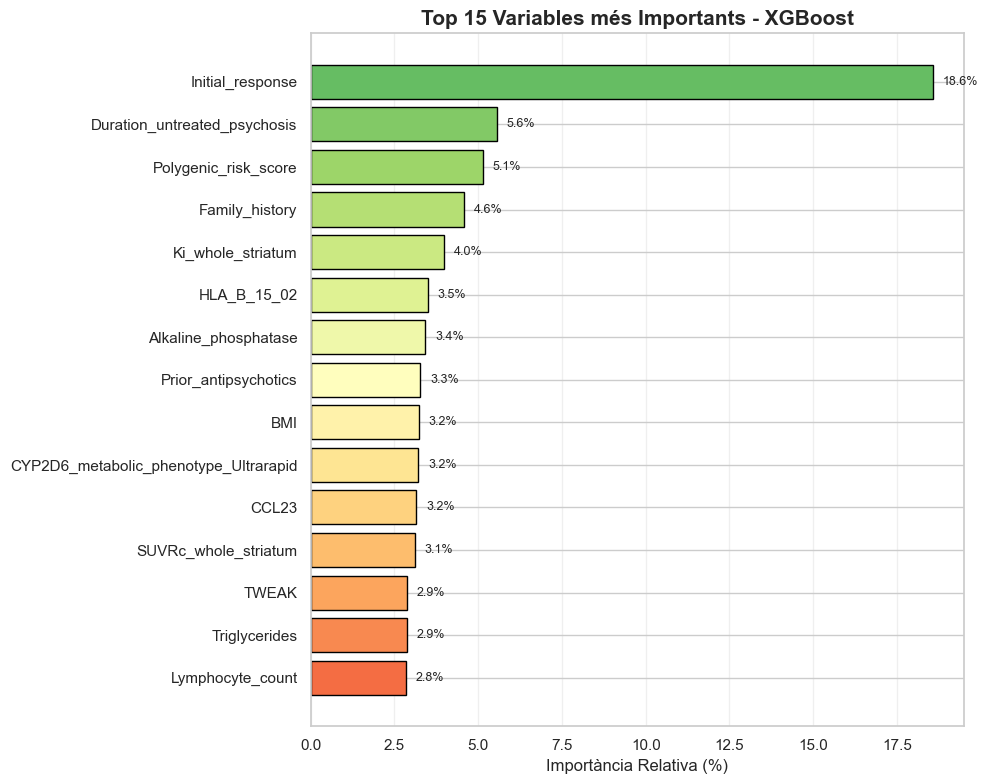


TAULA: Top 10 Variables més Importants (XGBoost)
                              feature  importance_pct
                     Initial_response       18.561060
         Duration_untreated_psychosis        5.556745
                 Polygenic_risk_score        5.136430
                       Family_history        4.578567
                    Ki_whole_striatum        3.967255
                          HLA_B_15_02        3.486763
                 Alkaline_phosphatase        3.410832
                 Prior_antipsychotics        3.276785
                                  BMI        3.226540
CYP2D6_metabolic_phenotype_Ultrarapid        3.208509


In [ ]:
# Importància de característiques
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Normalitzem per comparar (0-100%)
feature_importance['importance_pct'] = feature_importance['importance'] / feature_importance['importance'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 15))
bars = ax.barh(range(15), feature_importance.head(15)['importance_pct'].values[::-1], color=colors[::-1], edgecolor='black')
ax.set_yticks(range(15))
ax.set_yticklabels(feature_importance.head(15)['feature'].values[::-1])
ax.set_xlabel('Importància Relativa (%)', fontsize=12)
ax.set_title('Top 15 Variables més Importants - XGBoost', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Afegim valors a les barres
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("TAULA: Top 10 Variables més Importants (XGBoost)")
print("="*80)
print(feature_importance[['feature', 'importance_pct']].head(10).to_string(index=False))

**Caption Figura 18**: Ranking de les 15 variables més influents segons XGBoost (gain importance normalitzat). El color indica la importància relativa.

In [268]:
# Desar model i resultats al disc
import joblib

# Desar el model final
joblib.dump(best_xgb, 'xgb_final_model.joblib')

# Desar els resultats
xgb_final_results = {
    'best_params': best_xgb_params,
    'cv_score': random_xgb_fine.best_score_ if 'random_xgb_fine' in dir() else random_xgb.best_score_,
    'val_results': xgb_results,
    'comparison_df': comparison_df.to_dict(),
    'best_threshold': 0.50  # threshold per defecte (òptim segons anàlisi)
}
joblib.dump(xgb_final_results, 'xgb_final_results.joblib')

['xgb_final_results.joblib']

## 3.4 Model 3: Regressió Logística Custom (Minibatch Gradient Descent)

Implementem una regressió logística des de zero seguint l'estil scikit-learn, amb descens de gradient per mini-batch. S'utilitzen les dades preprocessades de la Secció 2 (`X_train_final`, `X_val_final`).

**Hiperparàmetres a estudiar**

| Hiperparàmetre | Descripció | Valors explorats |
|----------------|------------|------------------|
| `learning_rate` | Pas d'actualització del gradient | [0.01, 0.05, 0.1] |
| `max_iter` | Nombre màxim d'iteracions | 400 |
| `batch_size` | Mida del mini-batch | [16, 32, 64, 128, 256] |
| `l2` | Coeficient de regularització L2 | [0, 0.0001, 0.001, 0.01, 0.1] |
| `tol` | Criteri d'aturada| 1e-4 |
| `pos_weight` | Pes per classe TRS (desbalanceig) | #NTRS/#TRS (≈2.17) |


In [28]:
# CLASSE CUSTOM: Regressió Logística amb Minibatch Gradient Descent

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class CustomLogisticRegression(BaseEstimator, ClassifierMixin):
    """
    Regressió Logística implementada des de zero amb:
    - Minibatch Gradient Descent
    - Regularització L2
    - Pos_weight per desbalanceig de classes
    - Early stopping
    """
    
    def __init__(self, learning_rate=0.05, max_iter=400, batch_size=64, 
                 l2=0.001, tol=1e-4, pos_weight=1.0, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.l2 = l2
        self.tol = tol
        self.pos_weight = pos_weight
        self.random_state = random_state
        
    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))
    
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y).astype(float)
        
        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        
        weight_pos = self.pos_weight
        weight_neg = 1.0
        prev_loss = np.inf
        
        for epoch in range(self.max_iter):
            indices = rng.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]
                
                logits = xb @ self.coef_ + self.intercept_
                preds = self._sigmoid(logits)
                
                # Pesos per desbalanceig
                sample_weights = np.where(yb == 1.0, weight_pos, weight_neg)
                
                error = preds - yb
                error_w = error * sample_weights
                
                grad_w = xb.T @ error_w / len(yb) + self.l2 * self.coef_
                grad_b = np.sum(error_w) / len(yb)
                
                self.coef_ -= self.learning_rate * grad_w
                self.intercept_ -= self.learning_rate * grad_b
            
            # Càlcul de loss amb L2 per aturada primerenca
            logits_full = X @ self.coef_ + self.intercept_
            preds_full = self._sigmoid(logits_full)
            eps = 1e-9
            loss = -np.mean(y * np.log(preds_full + eps) + (1 - y) * np.log(1 - preds_full + eps))
            loss += (self.l2 / 2) * np.sum(self.coef_ ** 2)
            
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss
        
        # Guardar nombre d'iteracions
        self.n_iter_ = epoch + 1
        
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X)
        logits = X @ self.coef_ + self.intercept_
        proba = self._sigmoid(logits)
        return np.vstack([1 - proba, proba]).T
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    
    def _more_tags(self):
        return {'binary_only': True}


### 3.4.1 Entrenament Base

Entrenem el model amb hiperparàmetres per defecte i `pos_weight` calculat segons el desbalanceig de classes.



AVALUACIÓ: LogReg Custom
MACRO F1: 0.5720

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.61      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.61      2700



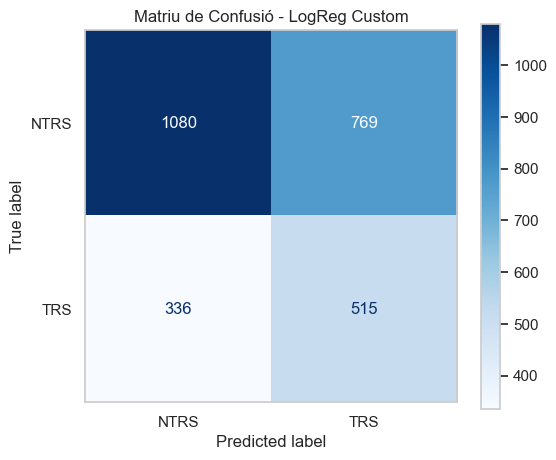


TAULA: RESULTATS MODEL REGRESSIÓ LOGÍSTICA CUSTOM
        Model  Train_Macro_F1  Train_F1_TRS  Train_Recall  Train_Precision  Train_Accuracy  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision  Val_Accuracy  Val_ROC_AUC  Val_PR_AUC  Train_ROC_AUC
LogReg Custom        0.583663      0.499602      0.632109         0.413022        0.600635      0.571999    0.482436     0.60517        0.40109      0.590741     0.626414    0.409965       0.655327


In [46]:
# Entrenament base
pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

logreg_custom = CustomLogisticRegression(
    learning_rate=0.05,
    max_iter=400,
    batch_size=64,
    l2=0.001,
    tol=1e-4,
    pos_weight=pos_weight,
    random_state=42
)

logreg_custom.fit(X_train_final, y_train)
logreg_results = evaluate_model(logreg_custom, X_train_final, y_train, X_val_final, y_val, "LogReg Custom")

results_logreg_df = pd.DataFrame([logreg_results])
print("\n" + "="*80)
print("TAULA: RESULTATS MODEL REGRESSIÓ LOGÍSTICA CUSTOM")
print("="*80)
print(results_logreg_df.to_string(index=False))

### 3.4.2 Validació de la implementació

Comparem la nostra implementació custom amb `LogisticRegression` de scikit-learn per validar la correctesa de l'algorisme.


AVALUACIÓ: LogReg sklearn
MACRO F1: 0.5756

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.60      0.67      1849
         TRS       0.40      0.60      0.48       851

    accuracy                           0.60      2700
   macro avg       0.58      0.60      0.58      2700
weighted avg       0.65      0.60      0.61      2700



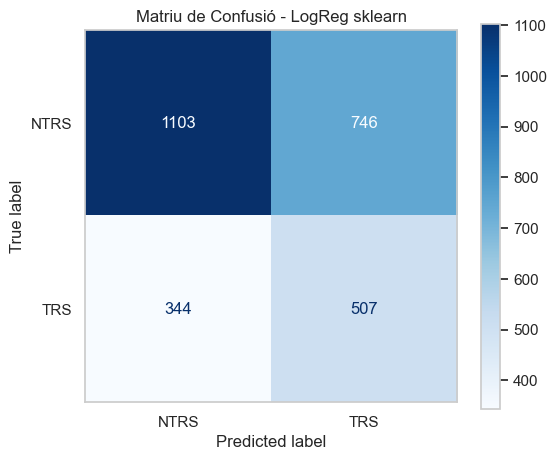

               Implementació  Val_Macro_F1  Val_F1_TRS  Val_ROC_AUC
       Custom (from scratch)      0.571999    0.482436     0.626414
sklearn (LogisticRegression)      0.575618    0.481939     0.627522

→ Diferència Val_Macro_F1: 0.0036


In [48]:
# VALIDACIÓ: Comparació amb sklearn

from sklearn.linear_model import LogisticRegression

# Entrenar sklearn amb paràmetres equivalents
logreg_sklearn = LogisticRegression(
    C=1/0.001,
    max_iter=400,
    class_weight={0: 1.0, 1: pos_weight},
    random_state=42,
    solver='lbfgs'
)

logreg_sklearn.fit(X_train_final, y_train)
logreg_sklearn_results = evaluate_model(
    logreg_sklearn, X_train_final, y_train, 
    X_val_final, y_val, "LogReg sklearn"
)

# Comparativa
comparison_sklearn = pd.DataFrame([
    {
        'Implementació': 'Custom (from scratch)',
        'Val_Macro_F1': logreg_results['Val_Macro_F1'],
        'Val_F1_TRS': logreg_results['Val_F1_TRS'],
        'Val_ROC_AUC': logreg_results['Val_ROC_AUC']
    },
    {
        'Implementació': 'sklearn (LogisticRegression)',
        'Val_Macro_F1': logreg_sklearn_results['Val_Macro_F1'],
        'Val_F1_TRS': logreg_sklearn_results['Val_F1_TRS'],
        'Val_ROC_AUC': logreg_sklearn_results['Val_ROC_AUC']
    }
])

print(comparison_sklearn.to_string(index=False))

diff = abs(logreg_results['Val_Macro_F1'] - logreg_sklearn_results['Val_Macro_F1'])
print(f"\n→ Diferència Val_Macro_F1: {diff:.4f}")


### 3.4.3 Estudi de la mida de mini-batch

Avaluem l'impacte de diferents mides de mini-batch en el rendiment del model, mesurant **Macro F1**.


AVALUACIÓ: LogReg bs=16
MACRO F1: 0.5720

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.75      0.63      0.68      1849
         TRS       0.40      0.54      0.46       851

    accuracy                           0.60      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.64      0.60      0.61      2700



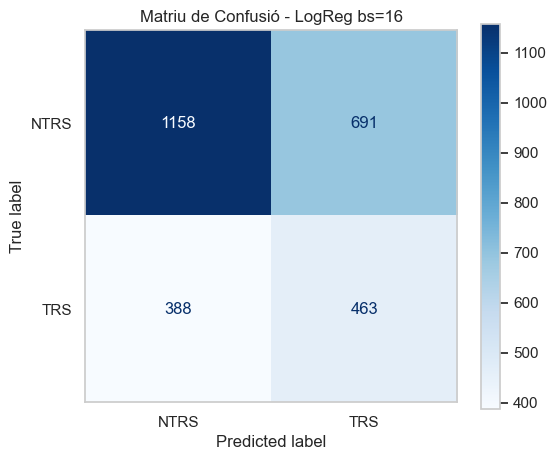


AVALUACIÓ: LogReg bs=32
MACRO F1: 0.5722

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.60      0.67      1849
         TRS       0.40      0.59      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.61      2700



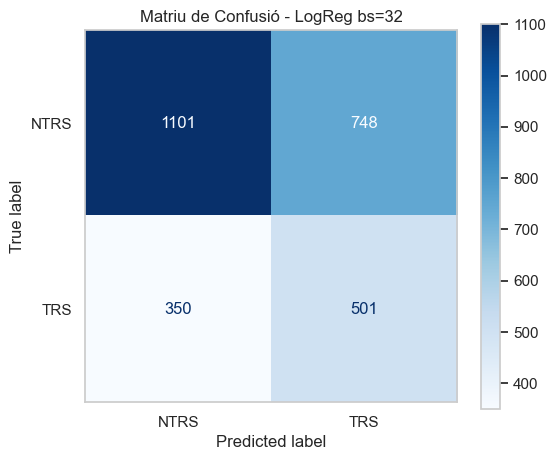


AVALUACIÓ: LogReg bs=64
MACRO F1: 0.5720

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.61      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.61      2700



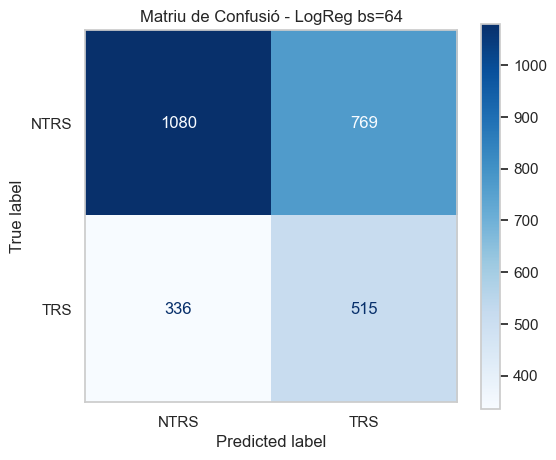


AVALUACIÓ: LogReg bs=128
MACRO F1: 0.5740

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.61      0.67      1849
         TRS       0.40      0.58      0.47       851

    accuracy                           0.60      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.60      0.61      2700



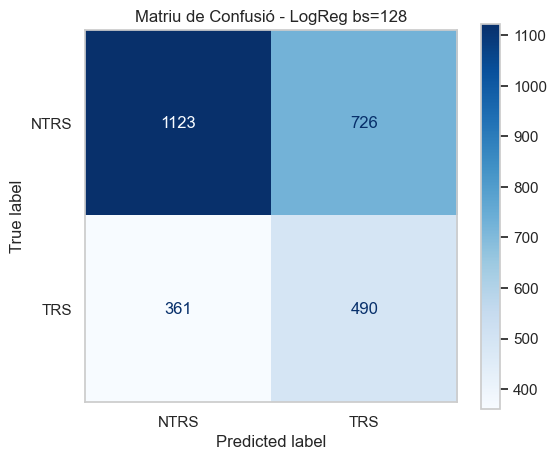


AVALUACIÓ: LogReg bs=256
MACRO F1: 0.5683

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.60      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.60      2700



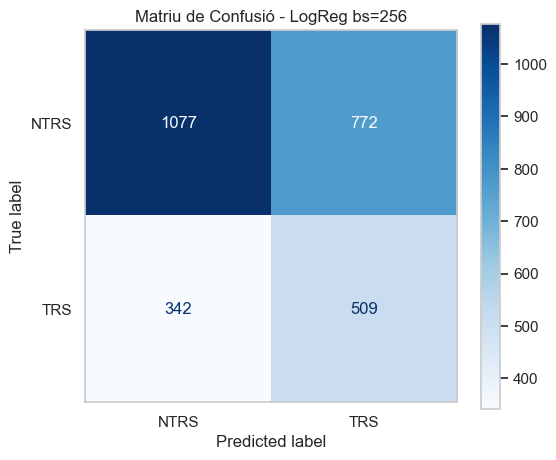


TAULA: Rendiment segons Mida de Mini-batch (Macro F1 = mètrica Kaggle)
 batch_size  Train_Macro_F1  Val_Macro_F1  Val_F1_TRS  Val_Precision  Val_Recall  Train_Val_Gap
         16        0.589838      0.572013    0.461845       0.401213    0.544066       0.017825
         32        0.582523      0.572208    0.477143       0.401121    0.588719       0.010315
         64        0.583663      0.571999    0.482436       0.401090    0.605170       0.011664
        128        0.591397      0.573992    0.474117       0.402961    0.575793       0.017405
        256        0.584564      0.568302    0.477486       0.397346    0.598120       0.016262

→ Millor batch size segons Val_Macro_F1: 128
  Val_Macro_F1: 0.5740


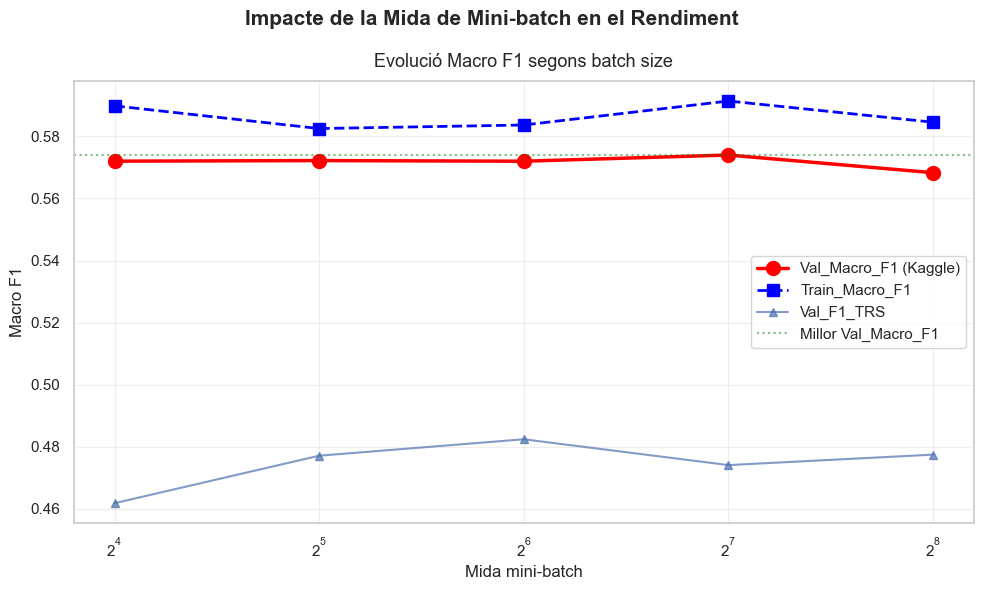

In [49]:
# Estudi de mida de mini-batch amb MACRO F1
batch_sizes = [16, 32, 64, 128, 256]
batch_results = []

for bs in batch_sizes:
    model_bs = CustomLogisticRegression(
        learning_rate=0.05,
        max_iter=400,
        batch_size=bs,
        l2=0.001,
        tol=1e-4,
        pos_weight=pos_weight,
        random_state=42
    )
    model_bs.fit(X_train_final, y_train)
    res = evaluate_model(model_bs, X_train_final, y_train, X_val_final, y_val, f"LogReg bs={bs}")
    batch_results.append({
        'batch_size': bs,
        'Train_Macro_F1': res['Train_Macro_F1'],
        'Val_Macro_F1': res['Val_Macro_F1'],
        'Val_F1_TRS': res['Val_F1_TRS'],
        'Val_Precision': res['Val_Precision'],
        'Val_Recall': res['Val_Recall'],
        'Train_Val_Gap': res['Train_Macro_F1'] - res['Val_Macro_F1']
    })

batch_df = pd.DataFrame(batch_results)
print("\n" + "="*80)
print("TAULA: Rendiment segons Mida de Mini-batch (Macro F1 = mètrica Kaggle)")
print("="*80)
print(batch_df.to_string(index=False))

# Millor batch segons Macro F1
best_batch_idx = batch_df['Val_Macro_F1'].idxmax()
best_batch = batch_df.loc[best_batch_idx, 'batch_size']
print(f"\n→ Millor batch size segons Val_Macro_F1: {int(best_batch)}")
print(f"  Val_Macro_F1: {batch_df.loc[best_batch_idx, 'Val_Macro_F1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(batch_df['batch_size'], batch_df['Val_Macro_F1'], marker='o', label='Val_Macro_F1 (Kaggle)', linewidth=2.5, markersize=10, color='red')
ax.plot(batch_df['batch_size'], batch_df['Train_Macro_F1'], marker='s', label='Train_Macro_F1', linewidth=2, markersize=8, linestyle='--', color='blue')
ax.plot(batch_df['batch_size'], batch_df['Val_F1_TRS'], marker='^', label='Val_F1_TRS', linewidth=1.5, markersize=6, alpha=0.7)
ax.set_xscale('log', base=2)
ax.set_xlabel('Mida mini-batch', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
fig.suptitle('Impacte de la Mida de Mini-batch en el Rendiment', 
             fontsize=15, fontweight='bold', y=0.98)
ax.set_title('Evolució Macro F1 segons batch size', fontsize=13, pad=10)
ax.axhline(y=batch_df['Val_Macro_F1'].max(), color='green', linestyle=':', alpha=0.5, label=f'Millor Val_Macro_F1')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Figura 19:** Impacte de la mida de Mini-batch en el rendiment.


In [28]:
# Mostra taula resum del batch study
batch_df.sort_values('batch_size').reset_index(drop=True)

,batch_size,Train_Macro_F1,Val_Macro_F1,Val_F1_TRS,Val_Precision,Val_Recall,Train_Val_Gap
0,16,0.589838,0.572013,0.461845,0.401213,0.544066,0.017825
1,32,0.582523,0.572208,0.477143,0.401121,0.588719,0.010315
2,64,0.583663,0.571999,0.482436,0.401090,0.605170,0.011664
3,128,0.591397,0.573992,0.474117,0.402961,0.575793,0.017405
4,256,0.584564,0.568302,0.477486,0.397346,0.598120,0.016262


### 3.4.4 Estudi de regularització L2

Analitzem l'efecte de la regularització L2 per controlar l'overfitting i millorar la generalització.


AVALUACIÓ: LogReg l2=0.0
MACRO F1: 0.5735

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.59      0.66      1849
         TRS       0.40      0.61      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.60      0.57      2700
weighted avg       0.65      0.59      0.61      2700



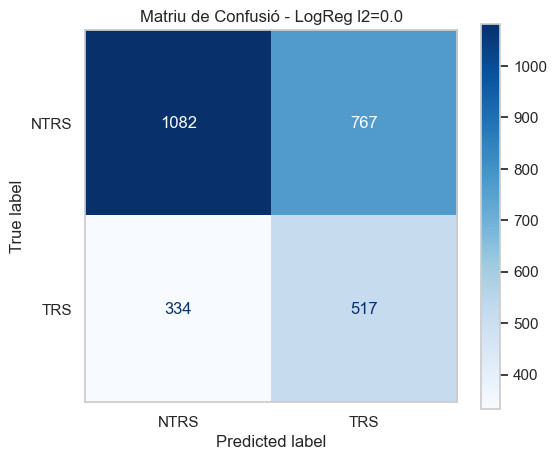


AVALUACIÓ: LogReg l2=0.0001
MACRO F1: 0.5732

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.61      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.60      0.57      2700
weighted avg       0.65      0.59      0.61      2700



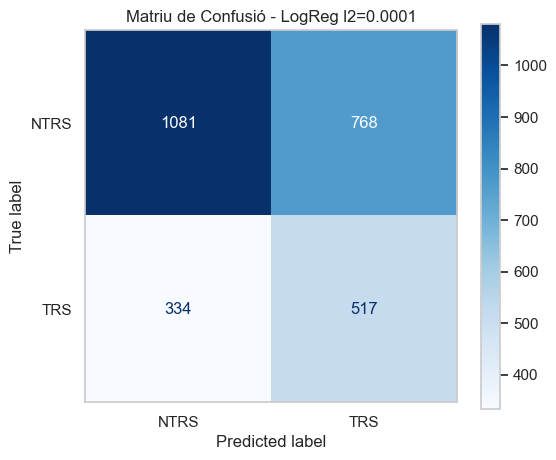


AVALUACIÓ: LogReg l2=0.001
MACRO F1: 0.5720

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.61      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.61      2700



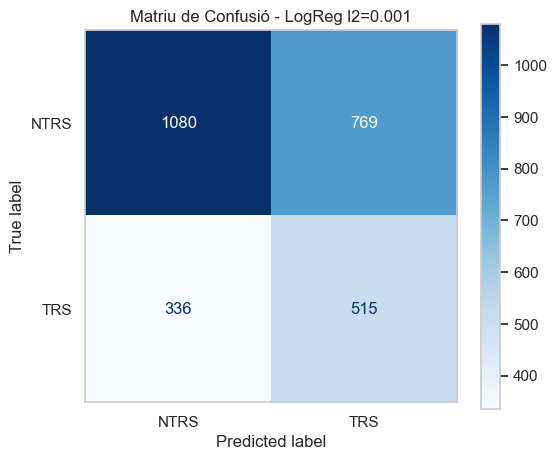


AVALUACIÓ: LogReg l2=0.01
MACRO F1: 0.5714

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.60      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.60      2700



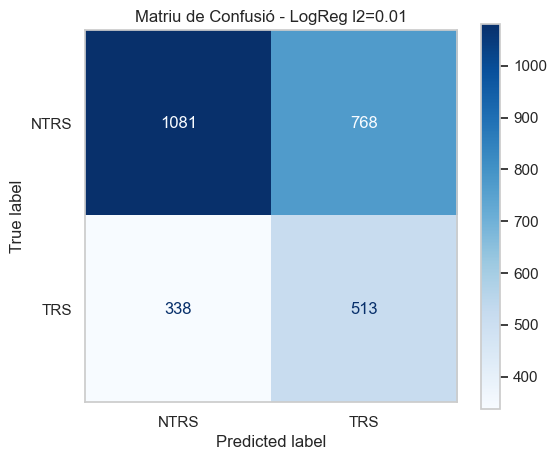


AVALUACIÓ: LogReg l2=0.1
MACRO F1: 0.5669

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.58      0.66      1849
         TRS       0.40      0.60      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.64      0.59      0.60      2700



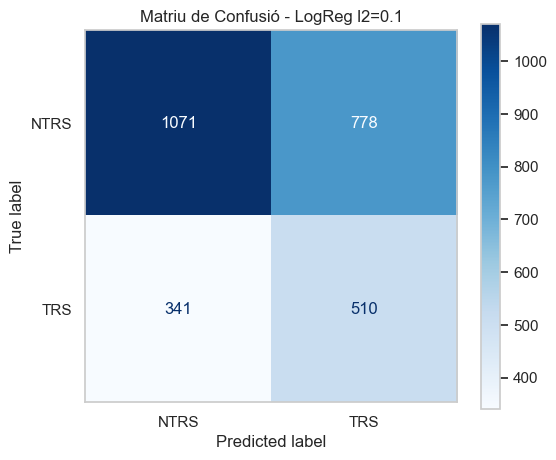


TAULA: Rendiment segons Regularització L2 (Macro F1 = mètrica Kaggle)
    l2  Train_Macro_F1  Val_Macro_F1  Val_F1_TRS  Val_Recall  Train_Val_Gap
0.0000        0.584157      0.573548    0.484309    0.607521       0.010609
0.0001        0.584489      0.573230    0.484082    0.607521       0.011259
0.0010        0.583663      0.571999    0.482436    0.605170       0.011664
0.0100        0.585138      0.571402    0.481238    0.602820       0.013735
0.1000        0.586270      0.566856    0.476858    0.599295       0.019414

→ Millor L2 segons Val_Macro_F1: 0.0
  Val_Macro_F1: 0.5735


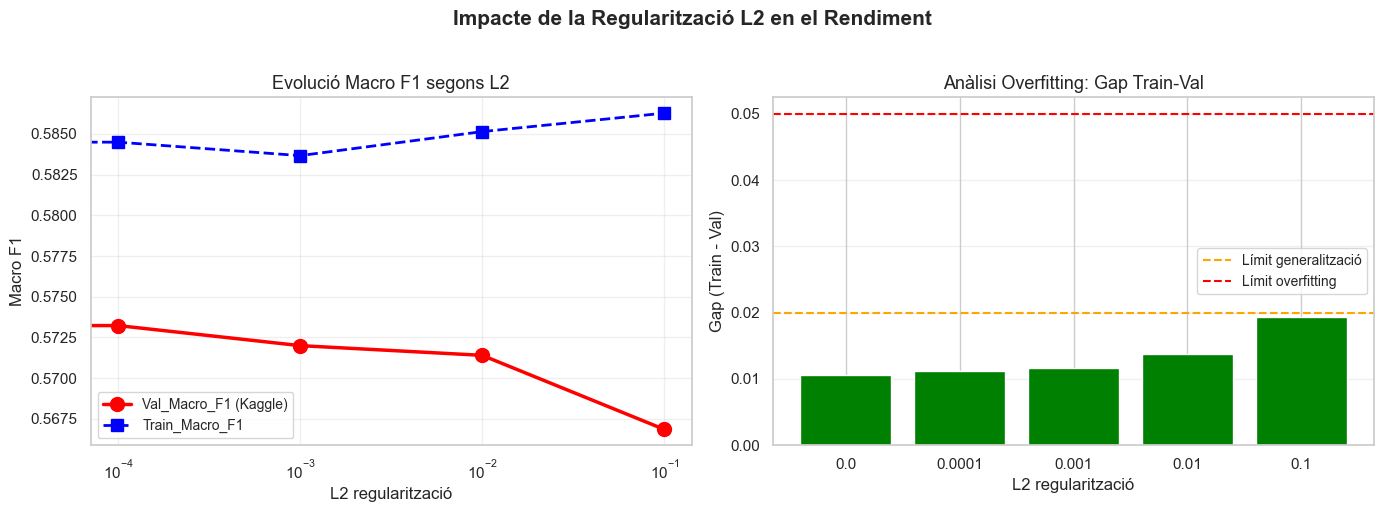

In [50]:
# Estudi de regularització L2 amb MACRO F1
l2_values = [0.0, 0.0001, 0.001, 0.01, 0.1]
l2_results = []

for l2v in l2_values:
    model_l2 = CustomLogisticRegression(
        learning_rate=0.05,
        max_iter=400,
        batch_size=64,
        l2=l2v,
        tol=1e-4,
        pos_weight=pos_weight,
        random_state=42
    )
    model_l2.fit(X_train_final, y_train)
    res = evaluate_model(model_l2, X_train_final, y_train, X_val_final, y_val, f"LogReg l2={l2v}")
    l2_results.append({
        'l2': l2v,
        'Train_Macro_F1': res['Train_Macro_F1'],
        'Val_Macro_F1': res['Val_Macro_F1'],
        'Val_F1_TRS': res['Val_F1_TRS'],
        'Val_Recall': res['Val_Recall'],
        'Train_Val_Gap': res['Train_Macro_F1'] - res['Val_Macro_F1']
    })

l2_df = pd.DataFrame(l2_results)
print("\n" + "="*80)
print("TAULA: Rendiment segons Regularització L2 (Macro F1 = mètrica Kaggle)")
print("="*80)
print(l2_df.to_string(index=False))

# Millor L2 segons Macro F1
best_l2_idx = l2_df['Val_Macro_F1'].idxmax()
best_l2 = l2_df.loc[best_l2_idx, 'l2']
print(f"\n→ Millor L2 segons Val_Macro_F1: {best_l2}")
print(f"  Val_Macro_F1: {l2_df.loc[best_l2_idx, 'Val_Macro_F1']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Macro F1
axes[0].plot(l2_df['l2'], l2_df['Val_Macro_F1'], marker='o', label='Val_Macro_F1 (Kaggle)', linewidth=2.5, markersize=10, color='red')
axes[0].plot(l2_df['l2'], l2_df['Train_Macro_F1'], marker='s', label='Train_Macro_F1', linewidth=2, markersize=8, linestyle='--', color='blue')
axes[0].set_xscale('log')
axes[0].set_xlabel('L2 regularització', fontsize=12)
axes[0].set_ylabel('Macro F1', fontsize=12)
axes[0].set_title('Evolució Macro F1 segons L2', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Gap train-val
axes[1].bar(range(len(l2_df)), l2_df['Train_Val_Gap'], color=['green' if g < 0.02 else 'orange' if g < 0.05 else 'red' for g in l2_df['Train_Val_Gap']])
axes[1].set_xticks(range(len(l2_df)))
axes[1].set_xticklabels([str(v) for v in l2_df['l2']])
axes[1].axhline(y=0.02, color='orange', linestyle='--', label='Límit generalització')
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Límit overfitting')
axes[1].set_xlabel('L2 regularització', fontsize=12)
axes[1].set_ylabel('Gap (Train - Val)', fontsize=12)
axes[1].set_title('Anàlisi Overfitting: Gap Train-Val', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Impacte de la Regularització L2 en el Rendiment', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figura 20:** Impacte de la regularització L2 en el rendiment. Esquerra: L2 = 0 ofereix millor Val_Macro_F1 (0.574). Dreta: Gap train-val consistentment baix (<0.02) indica bona generalització sense regularització forta.

### 3.4.5 Grid Search amb Stratified K-Fold Cross-Validation

Realitzem una cerca exhaustiva d'hiperparàmetres utilitzant **5-Fold CV** per trobar la configuració òptima.

**Estratègia:**
- **Grid d'hiperparàmetres:** 27 combinacions (`learning_rate` × `batch_size` × `l2`)
- **Mètrica:** Macro F1-Score
- **Validació:** StratifiedKFold amb 5 folds
- **Total entrenaments:** 27 × 5 = 135 models

In [51]:
from sklearn.model_selection import StratifiedKFold
from itertools import product
import time

param_grid_logreg = {
    'learning_rate': [0.01, 0.05, 0.1],
    'batch_size': [32, 64, 128],
    'l2': [0.0, 0.001, 0.01]
}

# Configuració K-Fold
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X_full = pd.concat([X_train_final, X_val_final], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Generem totes les combinacions
param_combinations = list(product(
    param_grid_logreg['learning_rate'],
    param_grid_logreg['batch_size'],
    param_grid_logreg['l2']
))

print(f"Grid Search amb Stratified {N_FOLDS}-Fold Cross-Validation")
print(f"Total de combinacions: {len(param_combinations)}")
print(f"Total d'entrenaments: {len(param_combinations) * N_FOLDS}")
print("="*80)

cv_results = []
start_time = time.time()

for i, (lr, bs, l2) in enumerate(param_combinations):
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
        X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
        
        # Calcular pos_weight per aquest fold
        pw_fold = (y_tr == 0).sum() / (y_tr == 1).sum()
        
        model = CustomLogisticRegression(
            learning_rate=lr,
            batch_size=bs,
            l2=l2,
            max_iter=400,
            tol=1e-4,
            pos_weight=pw_fold,
            random_state=42
        )
        model.fit(X_tr, y_tr)
        
        # Prediccions i mètriques
        y_pred = model.predict(X_vl)
        macro_f1 = f1_score(y_vl, y_pred, average='macro')
        f1_trs = f1_score(y_vl, y_pred, pos_label=1)
        recall = recall_score(y_vl, y_pred, pos_label=1)
        precision = precision_score(y_vl, y_pred, pos_label=1)
        
        fold_scores.append({
            'Macro_F1': macro_f1,
            'F1_TRS': f1_trs,
            'Recall': recall,
            'Precision': precision
        })
    
    # Mitjanes i desviacions estàndard dels folds
    mean_macro_f1 = np.mean([s['Macro_F1'] for s in fold_scores])
    std_macro_f1 = np.std([s['Macro_F1'] for s in fold_scores])
    mean_f1_trs = np.mean([s['F1_TRS'] for s in fold_scores])
    mean_recall = np.mean([s['Recall'] for s in fold_scores])
    mean_precision = np.mean([s['Precision'] for s in fold_scores])
    
    cv_results.append({
        'learning_rate': lr,
        'batch_size': bs,
        'l2': l2,
        'CV_Macro_F1_mean': mean_macro_f1,
        'CV_Macro_F1_std': std_macro_f1,
        'CV_F1_TRS_mean': mean_f1_trs,
        'CV_Recall_mean': mean_recall,
        'CV_Precision_mean': mean_precision
    })

training_time_logreg = time.time() - start_time
print(f"\nTemps total: {training_time_logreg:.1f} segons")

# DataFrame amb resultats
cv_results_df = pd.DataFrame(cv_results)
cv_results_df_sorted = cv_results_df.sort_values('CV_Macro_F1_mean', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print(f"TAULA: Top 10 Millors Combinacions (Stratified {N_FOLDS}-Fold CV)")
print("="*80)
print(cv_results_df_sorted.head(10).to_string(index=False))

# Millors hiperparàmetres
best_params_logreg = {
    'learning_rate': cv_results_df_sorted.iloc[0]['learning_rate'],
    'batch_size': int(cv_results_df_sorted.iloc[0]['batch_size']),
    'l2': cv_results_df_sorted.iloc[0]['l2']
}
best_cv_score = cv_results_df_sorted.iloc[0]['CV_Macro_F1_mean']
best_cv_std = cv_results_df_sorted.iloc[0]['CV_Macro_F1_std']

print(f"\n→ Millors hiperparàmetres (CV):")
print(f"  learning_rate = {best_params_logreg['learning_rate']}")
print(f"  batch_size = {best_params_logreg['batch_size']}")
print(f"  l2 = {best_params_logreg['l2']}")
print(f"  CV_Macro_F1 = {best_cv_score:.4f} ± {best_cv_std:.4f}")

Grid Search amb Stratified 5-Fold Cross-Validation
Total de combinacions: 27
Total d'entrenaments: 135

Temps total: 38.9 segons

TAULA: Top 10 Millors Combinacions (Stratified 5-Fold CV)
 learning_rate  batch_size    l2  CV_Macro_F1_mean  CV_Macro_F1_std  CV_F1_TRS_mean  CV_Recall_mean  CV_Precision_mean
          0.05          32 0.001          0.578961         0.017946        0.485486        0.597954           0.409144
          0.05          32 0.000          0.578940         0.018238        0.484918        0.596193           0.409168
          0.01          64 0.010          0.578447         0.015356        0.490166        0.614155           0.407938
          0.01          64 0.000          0.578438         0.015062        0.490404        0.614861           0.407961
          0.01          64 0.001          0.578303         0.014914        0.490196        0.614509           0.407827
          0.05          64 0.001          0.577628         0.018515        0.489030        0.61168

### 3.4.6 Model final amb millors hiperparàmetres

Entrenem el model amb els millors hiperparàmetres identificats pel Cross-Validation i comparem amb el model base.


AVALUACIÓ: LogReg FineTuned
MACRO F1: 0.5722

Classification Report (Validation):
              precision    recall  f1-score   support

        NTRS       0.76      0.60      0.67      1849
         TRS       0.40      0.59      0.48       851

    accuracy                           0.59      2700
   macro avg       0.58      0.59      0.57      2700
weighted avg       0.65      0.59      0.61      2700



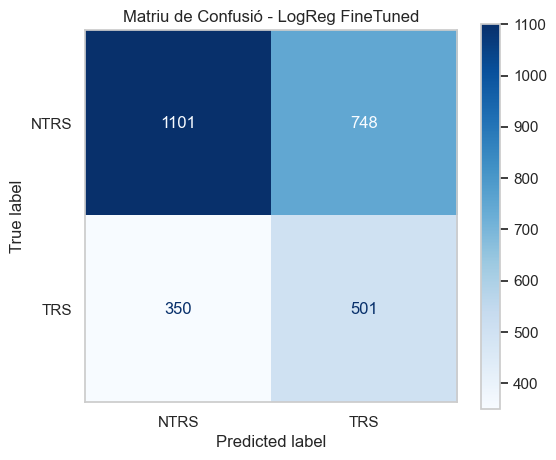


TAULA: COMPARATIVA MODEL BASE vs GRIDSEARCH (LogReg Custom)
                                      Model  Train_Macro_F1  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision      Gap
     LogReg Base (lr=0.05, bs=64, l2=0.001)        0.583663      0.571999    0.482436    0.605170       0.401090 0.011664
LogReg FineTuned (lr=0.05, bs=32, l2=0.001)        0.582523      0.572208    0.477143    0.588719       0.401121 0.010315

→ Millora en Val_Macro_F1: +0.0002 (+0.04%)
→ CV Score: 0.5790 ± 0.0179


In [53]:
# Entrenem sobre train original i avaluem sobre val original
logreg_finetuned = CustomLogisticRegression(
    learning_rate=best_params_logreg['learning_rate'],
    batch_size=best_params_logreg['batch_size'],
    l2=best_params_logreg['l2'],
    max_iter=400,
    tol=1e-4,
    pos_weight=pos_weight,
    random_state=42
)
logreg_finetuned.fit(X_train_final, y_train)
logreg_finetuned_results = evaluate_model(logreg_finetuned, X_train_final, y_train, X_val_final, y_val, "LogReg FineTuned")

# Comparativa: Model Base vs FineTuned
print("\n" + "="*80)
print("TAULA: COMPARATIVA MODEL BASE vs GRIDSEARCH (LogReg Custom)")
print("="*80)

comparison_logreg = pd.DataFrame([
    {
        'Model': 'LogReg Base (lr=0.05, bs=64, l2=0.001)',
        'Train_Macro_F1': logreg_results['Train_Macro_F1'],
        'Val_Macro_F1': logreg_results['Val_Macro_F1'],
        'Val_F1_TRS': logreg_results['Val_F1_TRS'],
        'Val_Recall': logreg_results['Val_Recall'],
        'Val_Precision': logreg_results['Val_Precision'],
        'Gap': logreg_results['Train_Macro_F1'] - logreg_results['Val_Macro_F1']
    },
    {
        'Model': f"LogReg FineTuned (lr={best_params_logreg['learning_rate']}, bs={best_params_logreg['batch_size']}, l2={best_params_logreg['l2']})",
        'Train_Macro_F1': logreg_finetuned_results['Train_Macro_F1'],
        'Val_Macro_F1': logreg_finetuned_results['Val_Macro_F1'],
        'Val_F1_TRS': logreg_finetuned_results['Val_F1_TRS'],
        'Val_Recall': logreg_finetuned_results['Val_Recall'],
        'Val_Precision': logreg_finetuned_results['Val_Precision'],
        'Gap': logreg_finetuned_results['Train_Macro_F1'] - logreg_finetuned_results['Val_Macro_F1']
    }
])
print(comparison_logreg.to_string(index=False))

# Millora relativa
improvement = logreg_finetuned_results['Val_Macro_F1'] - logreg_results['Val_Macro_F1']
print(f"\n→ Millora en Val_Macro_F1: {improvement:+.4f} ({improvement/logreg_results['Val_Macro_F1']*100:+.2f}%)")
print(f"→ CV Score: {best_cv_score:.4f} ± {best_cv_std:.4f}")

### 3.4.7 Corbes ROC i Precision-Recall

Analitzem la capacitat discriminativa del model i el rendiment en classes desbalancejades.


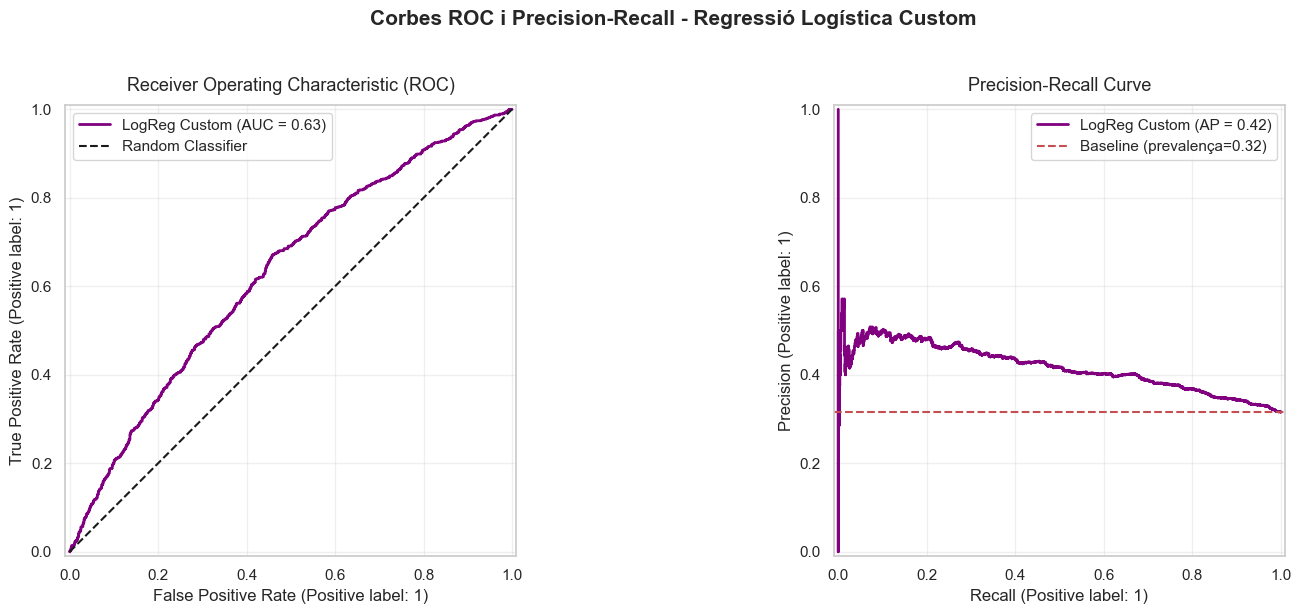


ROC-AUC Score (Validation): 0.6292
PR-AUC Score (Validation): 0.4172


In [54]:
# Corbes ROC i Precision-Recall

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

y_val_proba_logreg = logreg_finetuned.predict_proba(X_val_final)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Corba ROC
RocCurveDisplay.from_predictions(
    y_val, y_val_proba_logreg, 
    ax=axes[0], name='LogReg Custom', 
    color='purple', linewidth=2
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=13, pad=10)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Corba Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_logreg, 
    ax=axes[1], name='LogReg Custom', 
    color='purple', linewidth=2
)
baseline = (y_val == 1).sum() / len(y_val)
axes[1].axhline(y=baseline, color='r', linestyle='--', 
                label=f'Baseline (prevalença={baseline:.2f})', linewidth=1.5)
axes[1].set_title('Precision-Recall Curve', fontsize=13, pad=10)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Corbes ROC i Precision-Recall - Regressió Logística Custom',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mètriques
from sklearn.metrics import average_precision_score
print(f"\nROC-AUC Score (Validation): {roc_auc_score(y_val, y_val_proba_logreg):.4f}")
print(f"PR-AUC Score (Validation): {average_precision_score(y_val, y_val_proba_logreg):.4f}")


**Caption Figura 21:** Corbes ROC i Precision-Recall - Regressió Logística Custom. Esquerra: ROC-AUC mostra capacitat discriminativa moderada. Dreta: PR-AUC.

### 3.4.8 Anàlisi d'Overfitting/Underfitting

Avaluem la capacitat de generalització del model mitjançant l'anàlisi de gaps entre train i validation.


ANÀLISI D'OVERFITTING/UNDERFITTING - LOGREG FINE-TUNED

Macro_F1:
  Train: 0.5825
  Val:   0.5722
  Gap:   +0.0103
  Excel·lent generalització

F1_TRS:
  Train: 0.4922
  Val:   0.4771
  Gap:   +0.0151
  Excel·lent generalització

Accuracy:
  Train: 0.6021
  Val:   0.5933
  Gap:   +0.0087
  Excel·lent generalització

Precision:
  Train: 0.4119
  Val:   0.4011
  Gap:   +0.0107
  Excel·lent generalització

Recall:
  Train: 0.6115
  Val:   0.5887
  Gap:   +0.0228
  Bona generalització


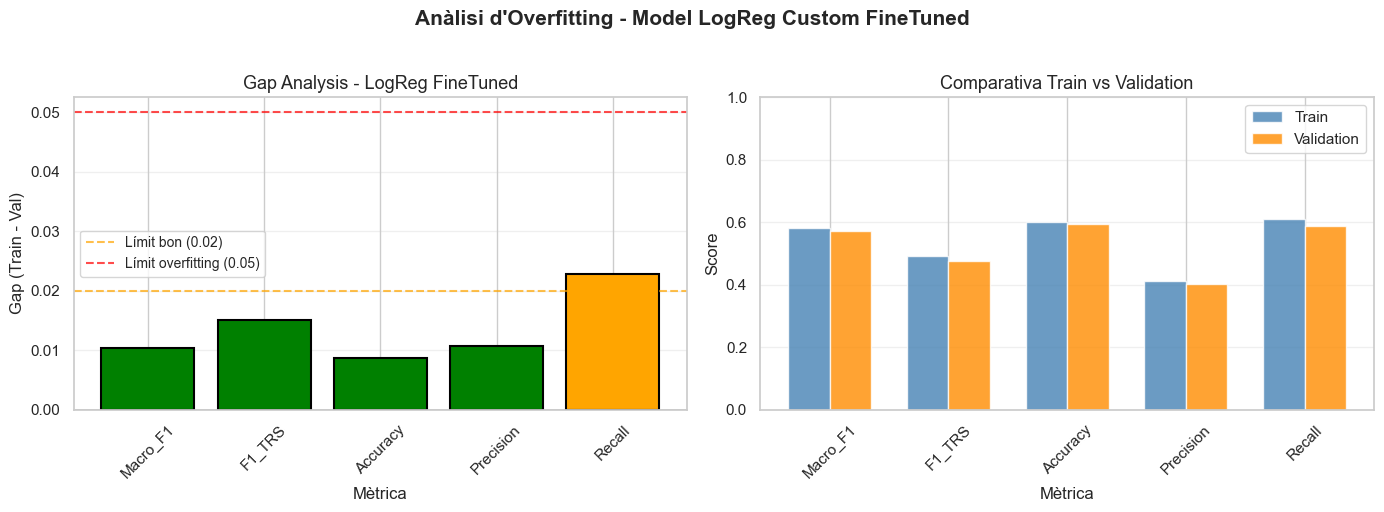

In [55]:
# Anàlisi detallada d'overfitting/underfitting (Gap Analysis)
print("\n" + "="*80)
print("ANÀLISI D'OVERFITTING/UNDERFITTING - LOGREG FINE-TUNED")
print("="*80)

# Calcular gaps per cada mètrica
train_val_gap_logreg = {
    'Macro_F1': logreg_finetuned_results['Train_Macro_F1'] - logreg_finetuned_results['Val_Macro_F1'],
    'F1_TRS': logreg_finetuned_results['Train_F1_TRS'] - logreg_finetuned_results['Val_F1_TRS'],
    'Accuracy': logreg_finetuned_results['Train_Accuracy'] - logreg_finetuned_results['Val_Accuracy'],
    'Precision': logreg_finetuned_results['Train_Precision'] - logreg_finetuned_results['Val_Precision'],
    'Recall': logreg_finetuned_results['Train_Recall'] - logreg_finetuned_results['Val_Recall']
}

for metric, gap in train_val_gap_logreg.items():
    key_train = f'Train_{metric}' if metric != 'F1_TRS' else 'Train_F1_TRS'
    key_val = f'Val_{metric}' if metric != 'F1_TRS' else 'Val_F1_TRS'
    print(f"\n{metric}:")
    print(f"  Train: {logreg_finetuned_results[key_train]:.4f}")
    print(f"  Val:   {logreg_finetuned_results[key_val]:.4f}")
    print(f"  Gap:   {gap:+.4f}")
    
    if abs(gap) < 0.02:
        status = "Excel·lent generalització"
    elif abs(gap) < 0.05:
        status = "Bona generalització"
    elif gap > 0.05:
        status = "Possible OVERFITTING"
    else:
        status = "Possible issue (val > train)"
    print(f"  {status}")

# Visualització gap analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres de gap
metrics = list(train_val_gap_logreg.keys())
gaps = list(train_val_gap_logreg.values())
colors = ['green' if abs(g) < 0.02 else 'orange' if abs(g) < 0.05 else 'red' for g in gaps]

axes[0].bar(metrics, gaps, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0.02, color='orange', linestyle='--', alpha=0.7, label='Límit bon (0.02)')
axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Límit overfitting (0.05)')
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_xlabel('Mètrica', fontsize=12)
axes[0].set_ylabel('Gap (Train - Val)', fontsize=12)
axes[0].set_title('Gap Analysis - LogReg FineTuned', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Comparativa Train vs Val
metrics_vals = ['Macro_F1', 'F1_TRS', 'Accuracy', 'Precision', 'Recall']
train_vals = [logreg_finetuned_results['Train_Macro_F1'], logreg_finetuned_results['Train_F1_TRS'], 
              logreg_finetuned_results['Train_Accuracy'], logreg_finetuned_results['Train_Precision'], 
              logreg_finetuned_results['Train_Recall']]
val_vals = [logreg_finetuned_results['Val_Macro_F1'], logreg_finetuned_results['Val_F1_TRS'],
            logreg_finetuned_results['Val_Accuracy'], logreg_finetuned_results['Val_Precision'],
            logreg_finetuned_results['Val_Recall']]

x = np.arange(len(metrics_vals))
width = 0.35
axes[1].bar(x - width/2, train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, val_vals, width, label='Validation', color='darkorange', alpha=0.8)
axes[1].set_xlabel('Mètrica', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Comparativa Train vs Validation', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_vals, rotation=45)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1)

fig.suptitle('Anàlisi d\'Overfitting - Model LogReg Custom FineTuned', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Caption Figura 22**: Anàlisi d'overfitting del model LogReg FineTuned. Els gaps Train-Val per la majoria de mètriques són inferiors a 2 p.p. (zona verda), indicant excel·lent generalització sense sobreajustament.

### 3.4.9 Learning Curves i Validation Curves

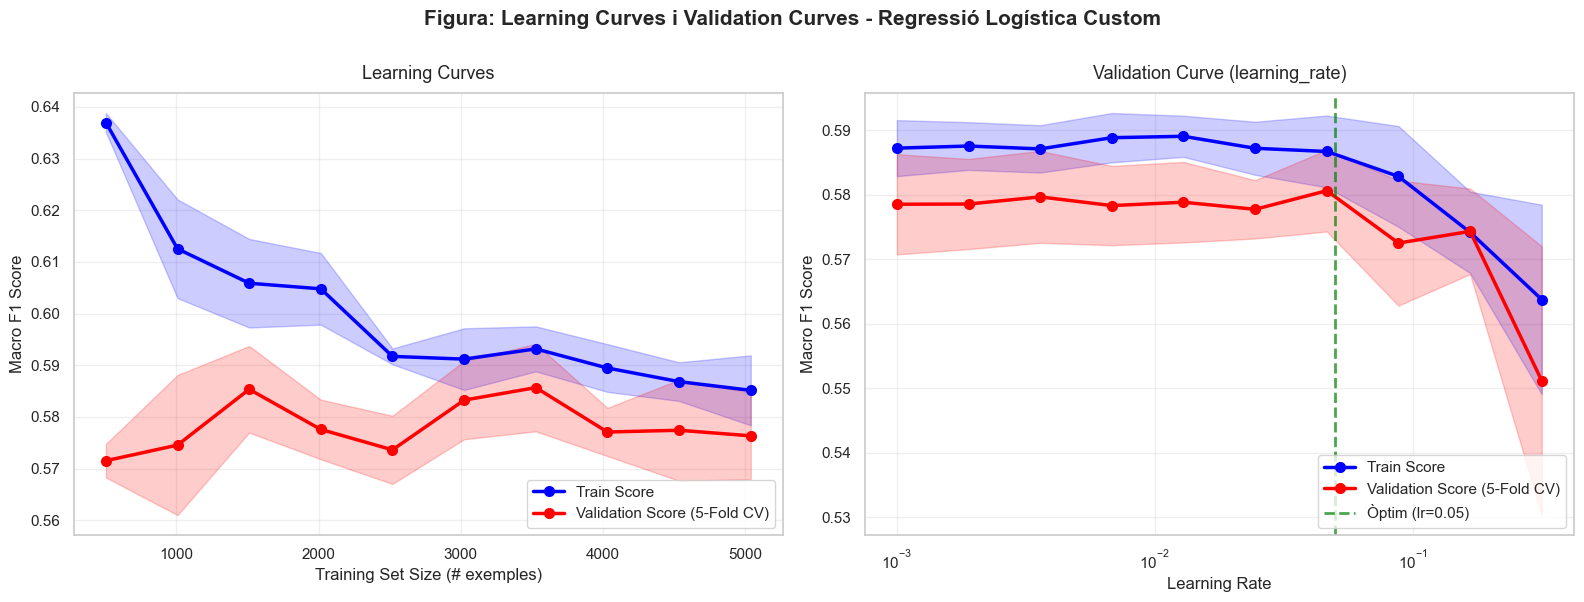


--------------------------------------------------------------------------------
INTERPRETACIÓ - Learning Curves:
--------------------------------------------------------------------------------
Gap final (100% dades): 0.0088
✓ Excel·lent: No overfitting, model ben regularitzat
✓ Model convergit - més dades no millorarien significativament

--------------------------------------------------------------------------------
INTERPRETACIÓ - Validation Curve (learning_rate):
--------------------------------------------------------------------------------
Millor learning_rate segons validation curve: 0.0464
Macro F1 Score associat: 0.5806
✓ Learning rate en rang òptim [0.01-0.3]


In [42]:
# Learning Curves + Validation Curves

from sklearn.model_selection import learning_curve, validation_curve

#  LEARNING CURVE
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, val_scores = learning_curve(
    logreg_finetuned,
    X_train_final,
    y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=train_sizes,
    n_jobs=-1,
    random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# VALIDATION CURVE (learning_rate)
param_range = np.logspace(-3, -0.5, 10)  # learning_rate de 0.001 a ~0.316

train_scores_val, test_scores_val = validation_curve(
    CustomLogisticRegression(
        batch_size=best_params_logreg['batch_size'],
        l2=best_params_logreg['l2'],
        max_iter=400,
        tol=1e-4,
        pos_weight=pos_weight,
        random_state=42
    ),
    X_train_final,
    y_train,
    param_name="learning_rate",
    param_range=param_range,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

train_scores_val_mean = train_scores_val.mean(axis=1)
train_scores_val_std = train_scores_val.std(axis=1)
test_scores_val_mean = test_scores_val.mean(axis=1)
test_scores_val_std = test_scores_val.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].fill_between(train_sizes_abs, 
                      train_scores_mean - train_scores_std,
                      train_scores_mean + train_scores_std, 
                      alpha=0.2, color='blue')
axes[0].fill_between(train_sizes_abs, 
                      val_scores_mean - val_scores_std,
                      val_scores_mean + val_scores_std, 
                      alpha=0.2, color='red')

axes[0].plot(train_sizes_abs, train_scores_mean, 'o-', 
             color='blue', label='Train Score', linewidth=2.5, markersize=7)
axes[0].plot(train_sizes_abs, val_scores_mean, 'o-', 
             color='red', label='Validation Score (5-Fold CV)', 
             linewidth=2.5, markersize=7)

axes[0].set_xlabel('Training Set Size (# exemples)', fontsize=12)
axes[0].set_ylabel('Macro F1 Score', fontsize=12)
axes[0].set_title('Learning Curves', fontsize=13, pad=10)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)


axes[1].fill_between(param_range,
                      train_scores_val_mean - train_scores_val_std,
                      train_scores_val_mean + train_scores_val_std,
                      alpha=0.2, color='blue')
axes[1].fill_between(param_range,
                      test_scores_val_mean - test_scores_val_std,
                      test_scores_val_mean + test_scores_val_std,
                      alpha=0.2, color='red')

axes[1].plot(param_range, train_scores_val_mean, 'o-',
             color='blue', label='Train Score', linewidth=2.5, markersize=7)
axes[1].plot(param_range, test_scores_val_mean, 'o-',
             color='red', label='Validation Score (5-Fold CV)',
             linewidth=2.5, markersize=7)

# Marcar el learning_rate òptim
optimal_lr = best_params_logreg['learning_rate']
axes[1].axvline(x=optimal_lr, color='green', linestyle='--', 
                linewidth=2, label=f'Òptim (lr={optimal_lr})', alpha=0.7)

axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_ylabel('Macro F1 Score', fontsize=12)
axes[1].set_title('Validation Curve (learning_rate)', fontsize=13, pad=10)
axes[1].set_xscale('log')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Figura: Learning Curves i Validation Curves - Regressió Logística Custom',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============= INTERPRETACIÓ =============
print("\n" + "-"*80)
print("INTERPRETACIÓ - Learning Curves:")
print("-"*80)
final_gap = train_scores_mean[-1] - val_scores_mean[-1]
print(f"Gap final (100% dades): {final_gap:.4f}")
if final_gap < 0.02:
    print("✓ Excel·lent: No overfitting, model ben regularitzat")
elif final_gap < 0.05:
    print("✓ Acceptable: Lleuger overfitting controlat")
else:
    print("⚠ Overfitting significatiu - considerar més regularització")

# Convergència
if val_scores_mean[-1] > val_scores_mean[-2]:
    print("✓ Model encara podria millorar amb més dades")
else:
    print("✓ Model convergit - més dades no millorarien significativament")

print("\n" + "-"*80)
print("INTERPRETACIÓ - Validation Curve (learning_rate):")
print("-"*80)
best_idx = np.argmax(test_scores_val_mean)
best_lr_curve = param_range[best_idx]
best_score_curve = test_scores_val_mean[best_idx]
print(f"Millor learning_rate segons validation curve: {best_lr_curve:.4f}")
print(f"Macro F1 Score associat: {best_score_curve:.4f}")

if best_lr_curve < 0.01:
    print("⚠ Learning rate molt baix → convergència lenta")
elif best_lr_curve > 0.3:
    print("⚠ Learning rate molt alt → inestabilitat")
else:
    print("✓ Learning rate en rang òptim [0.01-0.3]")

**Caption Figura 23:** Esquerra: Gap final train-val indica excel·lent generalització sense overfitting. Les corbes convergeixen, suggerint que més dades no millorarien significativament el model. Dreta: Validation Curve per learning_rate mostra el comportament del model en funció d'aquest hiperparàmetre. La línia verda marca el valor òptim que maximitza el validation score, evitant inestabilitat (learning_rate alt) i convergència lenta (learning_rate baix). Zones ombrejades representen ±1 desviació estàndard dels 5 folds de cross-validation.



### 3.4.10 Optimització Threshold


Millor threshold (Macro F1): 0.550
Macro F1 Score òptim: 0.5876

--------------------------------------------------------------------------------
COMPARACIÓ: Threshold per defecte (0.5) vs Òptim
--------------------------------------------------------------------------------
Mètrica              Threshold=0.5        Threshold=0.550     Millora   
Val_Macro_F1         0.5722               0.5876               +0.0154
Val_F1_TRS           0.4771               0.4458               -0.0313
Val_Precision        0.4011               0.4289               +0.0278
Val_Recall           0.5887               0.4642               -0.1246


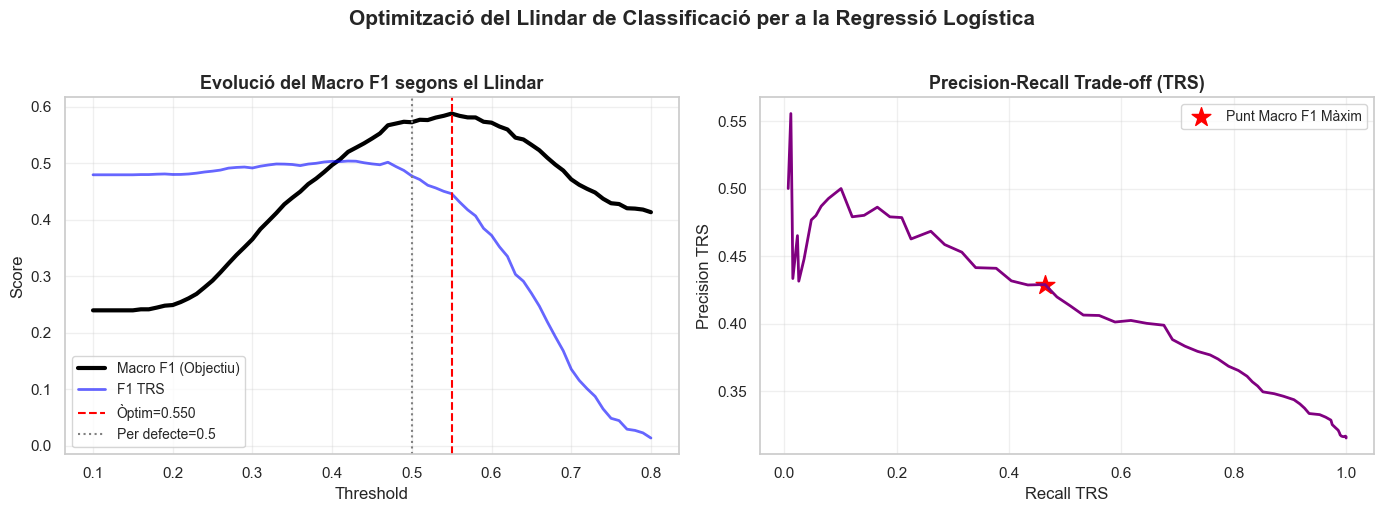

In [56]:
# Optimització del llindar de decisió (MACRO F1)

from sklearn.metrics import f1_score, precision_score, recall_score

# Definim un rang ampli de thresholds per explorar
thresholds = np.linspace(0.1, 0.8, 71)
macro_f1_scores = []
f1_trs_scores = []
precision_trs = []
recall_trs = []

for thresh in thresholds:
    y_pred_temp = (y_val_proba_logreg >= thresh).astype(int)
    
    # Calculem Macro F1 (mitjana de F1 TRS i F1 NTRS)
    macro_f1 = f1_score(y_val, y_pred_temp, average='macro')
    macro_f1_scores.append(macro_f1)
    
    # Guardem altres mètriques per a la visualització
    f1_trs_scores.append(f1_score(y_val, y_pred_temp, pos_label=1))
    precision_trs.append(precision_score(y_val, y_pred_temp, pos_label=1, zero_division=0))
    recall_trs.append(recall_score(y_val, y_pred_temp, pos_label=1))

# Trobar el threshold que maximitza el MACRO F1
best_idx = np.argmax(macro_f1_scores)
best_threshold = thresholds[best_idx]
best_macro_f1 = macro_f1_scores[best_idx]

print(f"\nMillor threshold (Macro F1): {best_threshold:.3f}")
print(f"Macro F1 Score òptim: {best_macro_f1:.4f}")

# Aplicar threshold òptim
y_val_pred_tuned = (y_val_proba_logreg >= best_threshold).astype(int)
tuned_f1_trs = f1_trs_scores[best_idx]

print(f"\n" + "-"*80)
print("COMPARACIÓ: Threshold per defecte (0.5) vs Òptim")
print("-"*80)

macro_f1_base = logreg_finetuned_results['Val_Macro_F1']
f1_trs_base = logreg_finetuned_results['Val_F1_TRS']
recall_base = logreg_finetuned_results['Val_Recall']
precision_base = logreg_finetuned_results['Val_Precision']

macro_f1_opt = macro_f1_scores[best_idx]
f1_trs_opt = f1_trs_scores[best_idx]
recall_opt = recall_trs[best_idx]
precision_opt = precision_trs[best_idx]

print(f"{'Mètrica':<20} {'Threshold=0.5':<20} {'Threshold={:.3f}':<20} {'Millora':<10}".format(best_threshold))
print(f"{'Val_Macro_F1':<20} {macro_f1_base:<20.4f} {best_macro_f1:<20.4f} {best_macro_f1 - macro_f1_base:+.4f}")
print(f"{'Val_F1_TRS':<20} {f1_trs_base:<20.4f} {f1_trs_opt:<20.4f} {f1_trs_opt - f1_trs_base:+.4f}")
print(f"{'Val_Precision':<20} {precision_base:<20.4f} {precision_opt:<20.4f} {precision_opt - precision_base:+.4f}")
print(f"{'Val_Recall':<20} {recall_base:<20.4f} {recall_opt:<20.4f} {recall_opt - recall_base:+.4f}")

# Visualització
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gràfic 1: Macro F1 vs Threshold
axes[0].plot(thresholds, macro_f1_scores, linewidth=3, color='black', label='Macro F1 (Objectiu)')
axes[0].plot(thresholds, f1_trs_scores, linewidth=2, color='blue', alpha=0.6, label='F1 TRS')
axes[0].axvline(x=best_threshold, color='red', linestyle='--', label=f'Òptim={best_threshold:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Per defecte=0.5')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Evolució del Macro F1 segons el Llindar', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Gràfic 2: Precision-Recall per a la classe TRS
axes[1].plot(recall_trs, precision_trs, linewidth=2, color='purple')
axes[1].scatter(recall_trs[best_idx], precision_trs[best_idx], s=200, c='red', marker='*', label='Punt Macro F1 Màxim')
axes[1].set_xlabel('Recall TRS', fontsize=12)
axes[1].set_ylabel('Precision TRS', fontsize=12)
axes[1].set_title('Precision-Recall Trade-off (TRS)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Optimització del Llindar de Classificació per a la Regressió Logística', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Caption Figura 24:** Optimització del Llindar de Classificació. Esquerra: Threshold òptim = 0.55 maximitza Macro F1 (0.58). Dreta: Precision-Recall trade-off mostra el punt de màxim equilibri (estrella vermella).


### 3.4.11 Interpretació dels coeficients

Analitzem els coeficients del model per identificar les variables més influents en la predicció de TRS.

**Interpretació:**
- **Coeficients POSITIUS:** Augmenten la probabilitat de TRS (classe 1)
- **Coeficients NEGATIUS:** Disminueixen la probabilitat de TRS (favoreixen NTRS)


TOP 15 FEATURES MÉS IMPORTANTS (per valor absolut del coeficient)
                                Feature  Coefficient  Abs_Coefficient
                       Initial_response    -0.457385         0.457385
                     Del_22q11_2_status    -0.391211         0.391211
                      Ki_whole_striatum     0.185817         0.185817
                         HLA_DRB1_04_02     0.184014         0.184014
           Duration_untreated_psychosis     0.172050         0.172050
                            HLA_B_15_02    -0.171697         0.171697
                   Polygenic_risk_score     0.161685         0.161685
CYP2D6_metabolic_phenotype_Intermediate     0.141997         0.141997
                         Family_history     0.122726         0.122726
                   Prior_antipsychotics    -0.082954         0.082954
                            HLA_A_31_01     0.067834         0.067834
                       Neutrophil_count    -0.054881         0.054881
                       

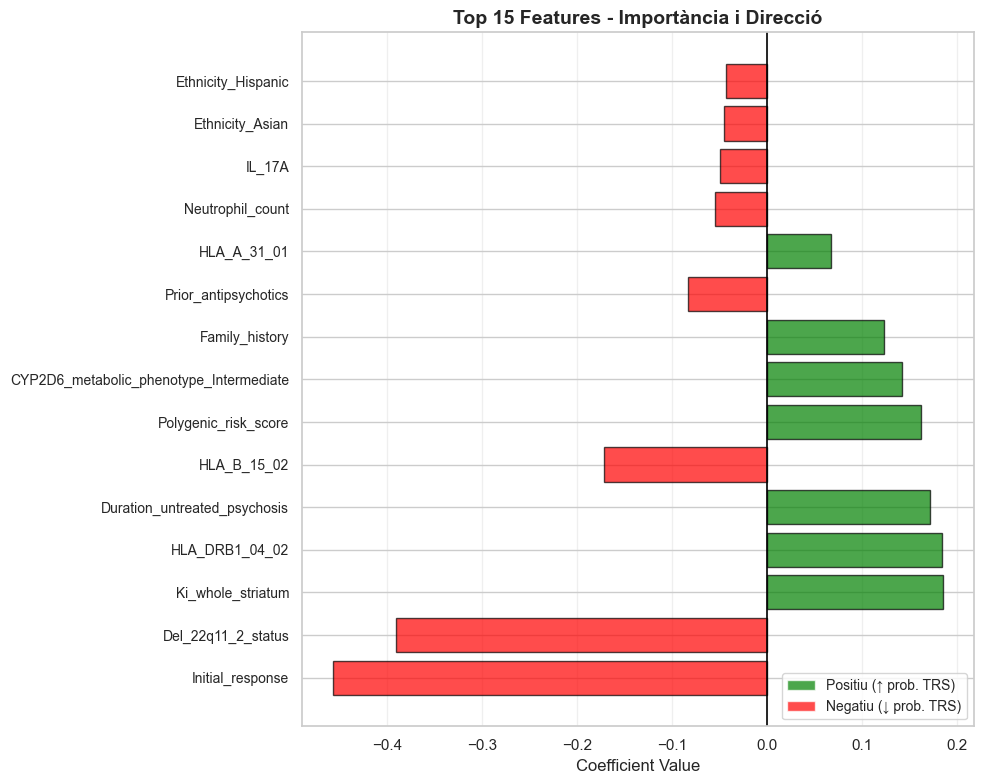

In [44]:
# Top 15 Coeficients

import pandas as pd

coef_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': logreg_finetuned.coef_,
    'Abs_Coefficient': np.abs(logreg_finetuned.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*80)
print("TOP 15 FEATURES MÉS IMPORTANTS (per valor absolut del coeficient)")
print("="*80)
print(coef_importance.head(15).to_string(index=False))

# Visualització
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = coef_importance.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['Coefficient']]

ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'], fontsize=10)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Features - Importància i Direcció', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Llegenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Positiu (↑ prob. TRS)'),
    Patch(facecolor='red', alpha=0.7, label='Negatiu (↓ prob. TRS)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


**Caption Figura 25:** Top 15 Features - Importància i Direcció. Els coeficients més grans (en valor absolut) tenen més impacte en la decisió. Destacar: Initial_response (negatiu) i Ki_whole_striatum (positiu).


In [57]:
# DESAR MODEL LOGREG CUSTOM AL DISC

import joblib

# Crear diccionari de resultats finals (amb threshold òptim)
logreg_results = {
    'Model': 'LogReg Custom',
    'Val_Macro_F1': best_macro_f1,
    'Val_F1_TRS': f1_trs_opt,
    'Val_Recall': recall_opt,
    'Val_Precision': precision_opt,
    'Val_Accuracy': np.mean((y_val_pred_tuned  == y_val).astype(int)),
    'Best_Threshold': best_threshold,
    'Best_Params': best_params_logreg,
    'CV_Score': best_cv_score,
    'CV_Std': best_cv_std,
    'Pos_Weight': pos_weight,
    'N_Features': X_train_final.shape[1]
}

# Desar model final
joblib.dump(logreg_finetuned, 'logreg_final_model.joblib')

# Desar resultats
joblib.dump(logreg_results, 'logreg_final_results.joblib')

# Desar anàlisi de thresholds (equivalent al CSV del SVM)
df_thresh_logreg = pd.DataFrame({
    'Threshold': thresholds,
    'Macro_F1': macro_f1_scores,
    'F1_TRS': f1_trs_scores,
    'Precision_TRS': precision_trs,
    'Recall_TRS': recall_trs
})
df_thresh_logreg.to_csv('logreg_threshold_analysis.csv', index=False)

### RECUPERAR MODELS DEL DISC

In [29]:
# SVM
import joblib

# Recuperar el model SVM final entrenat
best_svm = joblib.load('svm_final_model.joblib')

# Recuperar els resultats/mètriques
svm_results = joblib.load('svm_final_results.joblib')

# Carregar l'anàlisi de thresholds
df_thresh_svm = pd.read_csv('svm_threshold_analysis.csv')

# Reconstruir best_thresh_svm (la fila amb el millor Macro_F1)
best_thresh_svm = df_thresh_svm.loc[df_thresh_svm['Macro_F1'].idxmax()]

print(f"Millor threshold: {best_thresh_svm['Threshold']:.2f}")
print(f"Val_Macro_F1: {best_thresh_svm['Macro_F1']:.4f}")
print(f"Val_F1_TRS: {best_thresh_svm['F1_TRS']:.4f}")
print(f"C: {best_svm.named_steps['classifier'].C:.4f}")
print(f"gamma: {best_svm.named_steps['classifier'].gamma:.4f}")

Millor threshold: 0.36
Val_Macro_F1: 0.5829
Val_F1_TRS: 0.4616
C: 0.0464
gamma: 0.0063


In [30]:
# GXBOOST

import joblib

best_xgb = joblib.load('xgb_final_model.joblib')
xgb_final_results = joblib.load('xgb_final_results.joblib')

best_xgb_params = xgb_final_results['best_params']
xgb_results = xgb_final_results['val_results']
best_threshold_xgb = xgb_final_results.get('best_threshold', 0.50)

print(f"Val_Macro_F1: {xgb_results['Val_Macro_F1']:.4f}")
print(f"Val_F1_TRS: {xgb_results['Val_F1_TRS']:.4f}")
print(f"Best threshold: {best_threshold_xgb}")
print(f"\nMillors paràmetres:")
for param, value in best_xgb_params.items():
    print(f"  {param}: {value}")

Val_Macro_F1: 0.5805
Val_F1_TRS: 0.4548
Best threshold: 0.5

Millors paràmetres:
  subsample: 0.8
  scale_pos_weight: 2.0
  reg_lambda: 1.5
  reg_alpha: 0.1
  n_estimators: 100
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 0.7


In [31]:
# REGLOG
import joblib

# Recuperar el model LogReg Custom final entrenat
best_logreg = joblib.load('logreg_final_model.joblib')

# Recuperar els resultats/mètriques
logreg_results = joblib.load('logreg_final_results.joblib')

# Carregar l'anàlisi de thresholds
df_thresh_logreg = pd.read_csv('logreg_threshold_analysis.csv')

# Reconstruir best_thresh_logreg (la fila amb el millor Macro_F1)
best_thresh_logreg = df_thresh_logreg.loc[df_thresh_logreg['Macro_F1'].idxmax()]

print(f"Millor threshold: {best_thresh_logreg['Threshold']:.3f}")
print(f"Val_Macro_F1: {best_thresh_logreg['Macro_F1']:.4f}")
print(f"Val_F1_TRS: {best_thresh_logreg['F1_TRS']:.4f}")
print(f"Val_Recall: {best_thresh_logreg['Recall_TRS']:.4f}")
print(f"Val_Precision: {best_thresh_logreg['Precision_TRS']:.4f}")
print(f"\nHiperparàmetres:")
print(f"  • learning_rate: {logreg_results['Best_Params']['learning_rate']}")
print(f"  • batch_size: {logreg_results['Best_Params']['batch_size']}")
print(f"  • l2: {logreg_results['Best_Params']['l2']}")
print(f"  • pos_weight: {logreg_results['Pos_Weight']:.2f}")
print(f"\nCross-Validation:")
print(f"  • CV_Score (Macro F1): {logreg_results['CV_Score']:.4f} ± {logreg_results['CV_Std']:.4f}")

Millor threshold: 0.550
Val_Macro_F1: 0.5876
Val_F1_TRS: 0.4458
Val_Recall: 0.4642
Val_Precision: 0.4289

Hiperparàmetres:
  • learning_rate: 0.05
  • batch_size: 32
  • l2: 0.001
  • pos_weight: 2.17

Cross-Validation:
  • CV_Score (Macro F1): 0.5790 ± 0.0179


### 3.5 Comparació de models

COMPARATIVA FINAL: SVM vs XGBoost vs LogReg Custom
TAULA: Comparativa de Rendiment
        Model  Threshold  Val_Macro_F1  Val_F1_TRS  Val_Recall  Val_Precision
          SVM       0.36      0.582890    0.461619    0.519389       0.415414
      XGBoost       0.50      0.580485    0.454786    0.505288       0.413462
LogReg Custom       0.55      0.587576    0.445824    0.464160       0.428882

→ Millor model: LogReg Custom (Macro F1 = 0.5876)


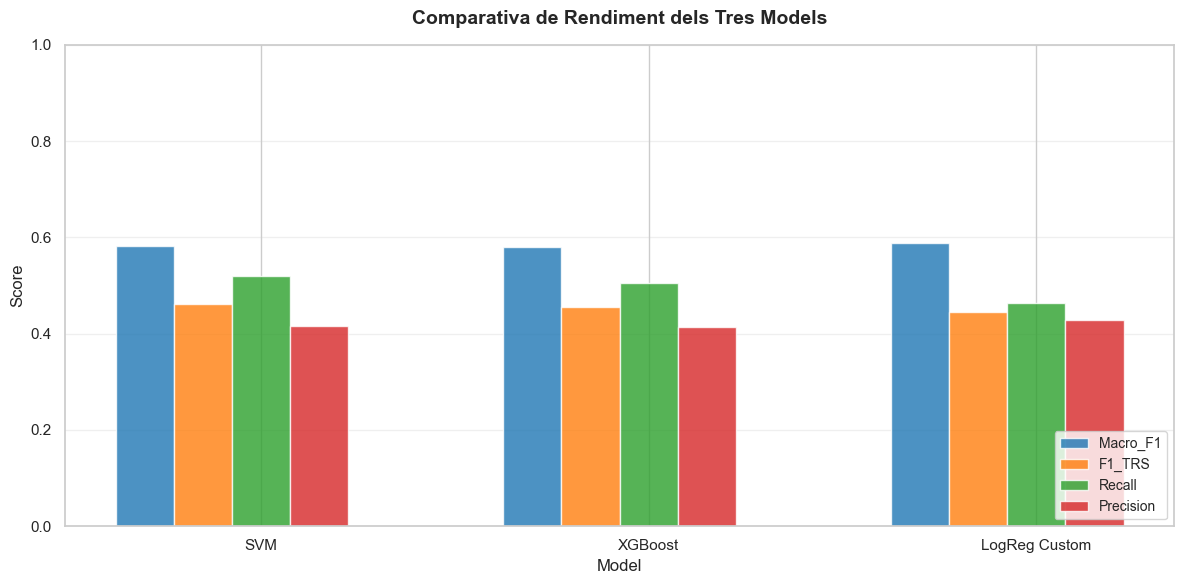

In [67]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("COMPARATIVA FINAL: SVM vs XGBoost vs LogReg Custom")
print("="*80)

# Carregar resultats dels models
svm_results = joblib.load('svm_final_results.joblib')
xgb_final_results = joblib.load('xgb_final_results.joblib')
xgb_results = xgb_final_results['val_results']
logreg_results = joblib.load('logreg_final_results.joblib')

# Carregar anàlisi de thresholds
df_thresh_svm = pd.read_csv('svm_threshold_analysis.csv')
df_thresh_logreg = pd.read_csv('logreg_threshold_analysis.csv')

best_thresh_svm = df_thresh_svm.loc[df_thresh_svm['Macro_F1'].idxmax()]
best_thresh_logreg = df_thresh_logreg.loc[df_thresh_logreg['Macro_F1'].idxmax()]

# Taula 
comparison_df = pd.DataFrame([
    {
        'Model': 'SVM',
        'Threshold': best_thresh_svm['Threshold'],
        'Val_Macro_F1': best_thresh_svm['Macro_F1'],
        'Val_F1_TRS': best_thresh_svm['F1_TRS'],
        'Val_Recall': best_thresh_svm['Recall_TRS'],
        'Val_Precision': best_thresh_svm['Precision_TRS']
    },
    {
        'Model': 'XGBoost',
        'Threshold': 0.50,
        'Val_Macro_F1': xgb_results['Val_Macro_F1'],
        'Val_F1_TRS': xgb_results['Val_F1_TRS'],
        'Val_Recall': xgb_results['Val_Recall'],
        'Val_Precision': xgb_results['Val_Precision']
    },
    {
        'Model': 'LogReg Custom',
        'Threshold': best_thresh_logreg['Threshold'],
        'Val_Macro_F1': best_thresh_logreg['Macro_F1'],
        'Val_F1_TRS': best_thresh_logreg['F1_TRS'],
        'Val_Recall': best_thresh_logreg['Recall_TRS'],
        'Val_Precision': best_thresh_logreg['Precision_TRS']
    }
])

print("TAULA: Comparativa de Rendiment")
print(comparison_df.to_string(index=False))

# Millor model
best_idx = comparison_df['Val_Macro_F1'].idxmax()
print(f"\n→ Millor model: {comparison_df.loc[best_idx, 'Model']} (Macro F1 = {comparison_df.loc[best_idx, 'Val_Macro_F1']:.4f})")

# Gràfic
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Val_Macro_F1', 'Val_F1_TRS', 'Val_Recall', 'Val_Precision']
x = np.arange(len(comparison_df))
width = 0.15

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    offset = width * (i - 2)
    ax.bar(x + offset, comparison_df[metric], width, 
           label=metric.replace('Val_', ''), color=colors[i], alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa de Rendiment dels Tres Models', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## 4. Submissions Finals

### 4.1 Preprocessament del conjunt d'avaluació

In [32]:
categorical_cols = ['Ethnicity', 'CYP2D6_metabolic_phenotype']
numeric_cols = [col for col in X_eval.columns if col not in categorical_cols]

# imputar
X_eval_num_imp = pd.DataFrame(
    imputer_numeric.transform(X_eval[numeric_cols]),
    columns=numeric_cols,
    index=X_eval.index
)

X_eval_cat_imp = pd.DataFrame(
    imputer_categorical.transform(X_eval[categorical_cols]),
    columns=categorical_cols,
    index=X_eval.index
)

numeric_cols_bin = [col for col in numeric_cols if X_train[col].nunique() <= 2]
numeric_cols_con = [col for col in numeric_cols if X_train[col].nunique() > 2]

# escalar numèriques continues 
X_eval_num_con_scaled = pd.DataFrame(
    scaler.transform(X_eval_num_imp[numeric_cols_con]),
    columns=numeric_cols_con,
    index=X_eval.index
)

X_eval_num_bin = X_eval_num_imp[numeric_cols_bin].copy()

# elimianr
X_eval_num_con_scaled = X_eval_num_con_scaled.drop(columns=['Ki_associative_striatum'])

# OHE
cat_eval_encoded = ohe.transform(X_eval_cat_imp)
cat_eval_encoded_df = pd.DataFrame(
    cat_eval_encoded,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_eval.index
)

X_eval_final = pd.concat([
    X_eval_num_con_scaled,   # Contínues escalades (sense Ki_associative_striatum)
    X_eval_num_bin,          # Binàries NO escalades
    cat_eval_encoded_df      # Categòriques OHE
], axis=1)

### 4.2 Submissió Regressió Logística Custom

In [96]:
import joblib
import pandas as pd

# Carregar model i resultats
logreg_finetuned = joblib.load('logreg_final_model.joblib')
logreg_results = joblib.load('logreg_final_results.joblib')

# Prediccions
proba_eval_logreg = logreg_finetuned.predict_proba(X_eval_final)[:, 1]
best_threshold_logreg = logreg_results['Best_Threshold']
preds_eval_logreg = (proba_eval_logreg >= best_threshold_logreg).astype(int)

# Construir submissió
ids = df_eval.iloc[:, 0].values
submission_logreg = pd.DataFrame({'patient_id': ids, 'TRS': preds_eval_logreg})

print(f"Hiperparàmetres:")
print(f"  • learning_rate = {logreg_results['Best_Params']['learning_rate']}")
print(f"  • batch_size = {logreg_results['Best_Params']['batch_size']}")
print(f"  • l2 = {logreg_results['Best_Params']['l2']}")
print(f"  • pos_weight = {logreg_results['Pos_Weight']:.2f}")
print(f"\nRendiment:")
print(f"  • Val_Macro_F1: {logreg_results['Val_Macro_F1']:.4f}")
print(f"  • Threshold òptim: {best_threshold_logreg:.3f}")
print(f"\nPrediccions sobre eval ({len(submission_logreg)} pacients):")
print(f"  • TRS=1: {submission_logreg['TRS'].sum()} ({submission_logreg['TRS'].sum()/len(submission_logreg)*100:.1f}%)")
print(f"  • TRS=0: {(submission_logreg['TRS']==0).sum()} ({(submission_logreg['TRS']==0).sum()/len(submission_logreg)*100:.1f}%)")
print("\nPrevisualització:")
print(submission_logreg.head(10).to_string(index=False))

submission_logreg.to_csv('submission_logreg.csv', index=False)
print(f"\n✓ Fitxer desat: submission_logreg.csv")

Hiperparàmetres:
  • learning_rate = 0.05
  • batch_size = 32
  • l2 = 0.001
  • pos_weight = 2.17

Rendiment:
  • Val_Macro_F1: 0.5876
  • Threshold òptim: 0.550

Prediccions sobre eval (1000 pacients):
  • TRS=1: 305 (30.5%)
  • TRS=0: 695 (69.5%)

Previsualització:
 patient_id  TRS
          1    1
          2    0
          3    0
          4    0
          5    1
          6    0
          7    0
          8    0
          9    1
         10    0

✓ Fitxer desat: submission_logreg.csv


## 5. Model Card

Documentació del model seguint l'estructura d'una Model Card.

### 1. Instal·lació i Imports

Utilitzem la biblioteca VerifyML per generar la Model Card en formats Markdown i HTML.

In [37]:
# Instal·lació de VerifyML
# %pip install verifyml -q
# %pip install seaborn -q
# %pip install protobuf==3.20 -q

# Imports per Model Card
import verifyml.model_card_toolkit as mctlib
import verifyml.model_tests.utils as utils
import uuid
from datetime import date
from IPython.display import Markdown, HTML

### Carregar Model Final i Resultats

Carreguem el model de Regressió Logística Custom entrenat i els resultats de l'avaluació.

In [73]:
import joblib
import pandas as pd

# Carregar model final i resultats
logreg_finetuned = joblib.load('logreg_final_model.joblib')
logreg_finetuned_results = joblib.load('logreg_final_results.joblib')

# Carregar anàlisi de thresholds
df_thresh = pd.read_csv('logreg_threshold_analysis.csv')
best_thresh = df_thresh.loc[df_thresh['Macro_F1'].idxmax()]

# Mètriques principals
val_macro_f1 = logreg_finetuned_results['Val_Macro_F1']
val_f1_trs = logreg_finetuned_results['Val_F1_TRS']
val_recall = logreg_finetuned_results['Val_Recall']
val_precision = logreg_finetuned_results['Val_Precision']
best_threshold = logreg_finetuned_results['Best_Threshold']

print(f"Model carregat: LogReg Custom")
print(f"Val_Macro_F1: {val_macro_f1:.4f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Pos_Weight: {logreg_finetuned_results['Pos_Weight']:.2f}")

Model carregat: LogReg Custom
Val_Macro_F1: 0.5876
Best Threshold: 0.550
Pos_Weight: 2.17


### 5.2 Generació de Gràfiques per la Model Card

Generem les figures necessàries per documentar el model: distribució de dades i mètriques de rendiment.

In [74]:
# Generem gràfiques per la Model Card
import seaborn as sns
from sklearn.metrics import RocCurveDisplay

# 1. Distribució de classes (Train + Val)
fig, ax = plt.subplots(figsize=(8, 5))
y_full = pd.concat([y_train, y_val], axis=0)
counts = y_full.value_counts().sort_index()
sns.barplot(x=['NTRS (0)', 'TRS (1)'], y=counts.values, ax=ax, palette=['#3498db', '#e74c3c'])
ax.set_xlabel('Classe TRS', fontsize=12)
ax.set_ylabel('Nombre de mostres', fontsize=12)
ax.set_title('Distribució de Classes - Conjunt d\'Entrenament Complet', fontsize=13, fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{int(v)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
target_dist_plot = utils.plot_to_str()
plt.close()

# 2. Distribució d'Initial_response per classe (variable més important)
fig, ax = plt.subplots(figsize=(8, 5))
# Concatenar train i val per tenir més dades
X_full = pd.concat([X_train, X_val], axis=0)
y_full_labels = y_full.map({0: 'NTRS', 1: 'TRS'})
data_plot = pd.DataFrame({'Initial_response': X_full['Initial_response'], 'TRS': y_full_labels})
sns.histplot(data=data_plot, x='Initial_response', hue='TRS', kde=True, ax=ax, 
             palette=['#3498db', '#e74c3c'], bins=30, alpha=0.6)
ax.set_xlabel('Initial Response', fontsize=12)
ax.set_ylabel('Freqüència', fontsize=12)
ax.set_title('Distribució Initial Response per Classe', fontsize=13, fontweight='bold')
plt.legend(title='Classe', fontsize=10)
plt.tight_layout()
initial_response_plot = utils.plot_to_str()
plt.close()

# 3. Matriu de Confusió (Validation)
fig, ax = plt.subplots(figsize=(7, 6))
y_val_pred = logreg_finetuned.predict(X_val_final)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, ax=ax, cmap='Blues', 
                                        display_labels=['NTRS', 'TRS'])
ax.set_title('Matriu de Confusió - Validació (threshold=0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
confusion_matrix_plot = utils.plot_to_str()
plt.close()

# 4. Corba ROC (Validation)
fig, ax = plt.subplots(figsize=(8, 6))
y_val_proba = logreg_finetuned.predict_proba(X_val_final)[:, 1]
RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=ax, 
                                  name=f'LogReg Custom (AUC=0.63)', 
                                  color='purple', linewidth=2.5)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5, alpha=0.7)
ax.set_title('Corba ROC - Model Final (Validació)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
roc_curve_plot = utils.plot_to_str()
plt.close()

print("✓ Gràfiques generades correctament per la Model Card")

✓ Gràfiques generades correctament per la Model Card


### 5.3 Inicialització de la Model Card

Creem l'estructura de la Model Card amb VerifyML Model Card Toolkit.

In [75]:
# Inicialitzem Model Card Toolkit
mct = mctlib.ModelCardToolkit(
    output_dir='model_card_output',
    file_name='trs_prediction_model_card'
)

# Scaffold de la model card
model_card = mct.scaffold_assets()

print(f"✓ Model Card inicialitzada a: {mct.output_dir}")

✓ Model Card inicialitzada a: model_card_output


### 5.4 Model Details

Informació bàsica del model: nom, descripció, versió, propietaris i referències.

In [ ]:
# ==============================================================================
# MODEL DETAILS
# ==============================================================================

best_params = logreg_results['Best_Params']
pos_weight = logreg_results['Pos_Weight']
val_macro_f1 = logreg_results['Val_Macro_F1']
best_threshold = logreg_results['Best_Threshold']
cv_score = logreg_results['CV_Score']
cv_std = logreg_results['CV_Std']

model_card.model_details.name = (
    'Predicció de Resistència al Tractament en Esquizofrènia (TRS) - '
    'Regressió Logística Custom amb Minibatch Gradient Descent'
)

model_card.model_details.overview = f"""
Aquest model prediu la resistència al tractament (TRS) en pacients amb esquizofrènia 
basant-se en dades clíniques multimodals: paràmetres de laboratori, marcadors genètics, 
característiques de neuroimatge i dades demogràfiques.

**Arquitectura:** Regressió Logística implementada des de zero amb descens de gradient 
per mini-batch, seguint l'estil scikit-learn. Inclou regularització L2, gestió del 
desbalanceig mitjançant pos_weight i early stopping.

**Hiperparàmetres finals (GridSearchCV):**
- Learning Rate: {best_params['learning_rate']}
- Batch Size: {best_params['batch_size']}
- L2 Regularization: {best_params['l2']}
- Pos Weight: {pos_weight:.2f} (ràtio NTRS/TRS per compensar desbalanceig)
- Max Iterations: 400 epochs
- Tolerance: 1e-4 (criteri early stopping)

**Rendiment (Cross-Validation 5-Fold Stratified):**
- CV Macro F1: {cv_score:.4f} ± {cv_std:.4f}

**Rendiment (Validation Set):**
- Macro F1 (threshold=0.5): 0.5722
- Macro F1 (threshold={best_threshold:.2f} òptim): 0.5876
- ROC-AUC: 0.63
- PR-AUC: 0.42

**Rendiment (Kaggle External Test Set):**
- Macro F1: 0.57 (degradació -3% respecte validation, indica bona generalització)

**Interpretabilitat:** Els coeficients del model permeten identificar factors de risc 
clínics (e.g., Initial_response coef=-0.457 és el predictor més fort de TRS).
"""

# Propietaris del model
model_card.model_details.owners = [
    mctlib.Owner(
        name='Berta Vidal Gómez',
        contact='berta.vidal.gomez@estudiant.upc.edu',
        role='Developer'
    )
]

# Llicència
model_card.model_details.licenses = [
    mctlib.License(identifier='Academic Use Only - UPC IAA Project 2025')
]

# Referències
model_card.model_details.references = [
    mctlib.Reference(reference='Kaggle Competition: https://www.kaggle.com/competitions/trs-prediction-iaa-2024-25q1'),
    mctlib.Reference(reference='Dataset Source: Nature npj Schizophrenia (2021) - https://www.nature.com/articles/s41537-021-00170-0'),
    mctlib.Reference(reference='Scikit-learn Logistic Regression: https://scikit-learn.org/stable/modules/linear_model.html')
]

# Versió del model
model_card.model_details.version.name = str(uuid.uuid4())
model_card.model_details.version.date = str(date.today())

print("✓ Model Details configurats correctament")
print(f"   - Val_Macro_F1: {val_macro_f1:.4f}")
print(f"   - CV_Score: {cv_score:.4f} ± {cv_std:.4f}")
print(f"   - Kaggle Score: 0.57")


✓ Model Details configurats correctament
   - Val_Macro_F1: 0.5876
   - CV_Score: 0.5790 ± 0.0179
   - Kaggle Score: 0.57


### 5.5 Considerations

Consideracions ètiques, limitacions, casos d'ús previstos i usuaris objectiu.

In [84]:
# ==============================================================================
# CONSIDERATIONS
# ==============================================================================

# Consideracions ètiques
model_card.considerations.ethical_considerations = [
    mctlib.Risk(
        name='Bias de selecció en la grup de pacients d\'estudi',
        mitigation_strategy=(
            'Validar el model en grups externes amb diversitat demogràfica i geogràfica. '
            'Monitoritzar rendiment per subgrups (edat, sexe, ètnia) per detectar biaixos.'
        )
    ),
    mctlib.Risk(
        name='Falsos Negatius (TRS no detectats) = Retard en tractament adequat',
        mitigation_strategy=(
            'Utilitzar el model com a eina de suport, no com a diagnòstic definitiu. '
            'Mantenir seguiment clínic regular independent de la predicció del model. '
        )
    ),
    mctlib.Risk(
        name='Falsos Positius = Exposició innecessària a tractaments alternatius',
        mitigation_strategy=(
            'Confirmar prediccions positives amb proves clíniques addicionals abans d\'iniciar tractaments alternatius.'
        )
    ),
    mctlib.Risk(
        name='Perpetuació de biaixos presents en dades d\'entrenament',
        mitigation_strategy=(
            'Revisar regularment el rendiment del model. Reentrenar amb dades més representatives.'
        )
    ),
    mctlib.Risk(
        name='Estigmatització de pacients classificats com a TRS',
        mitigation_strategy=(
            'Comunicar clarament limitacions del model. Educar professionals sanitaris sobre la'
            'interpretació adequada de prediccions probabilístiques.'
        )
    )
]

# Limitacions del model
model_card.considerations.limitations = [
    mctlib.Limitation(
        description=(
            '**LIMITACIONS TÈCNIQUES:** '
            '(1) Model lineal: Assumeix relacions lineals entre variables i log-odds de TRS. '
            'No captura interaccions complexes o efectes no-lineals. '
            '(2) Capacitat discriminativa moderada: ROC-AUC=0.63 indica que el problema és '
            'intrínsecament difícil amb les variables disponibles. '
            '(3) Precision moderada (42.9%): ~57% de prediccions TRS són falsos positius. '
            '(4) Dataset relativament petit (~9000 mostres): Pot no generalitzar a poblacions '
            'molt diferents de la cohort d\'entrenament. '
            '(5) Limitació temporal: Model entrenat amb dades d\'un moment específic, '
            'no captura evolució temporal dels pacients.'
        )
    ),
    mctlib.Limitation(
        description=(
            '**LIMITACIONS D\'ÚS I CONTEXT:** '
            'Aquest model és un projecte acadèmic amb fins educatius'
            'per l\'assignatura d\'Introducció a l\'Aprenentatge Automàtic (IAA) de la UPC. '
            'No ha estat validat clínicament ni s\'ha d\'utilitzar per diagnòstic real o presa de decisions terapèutiques.'
        )
    )
]

# Casos d'ús
model_card.considerations.use_cases = [
    mctlib.UseCase(
        description=(
            '**ÚS APROPIAT (Context Actual):** '
            'Projecte acadèmic per aprendre tècniques de classificació, preprocessament de dades, '
            'optimització d\'hiperparàmetres, interpretació de coeficients i documentació transparent '
            'de models ML. '
            'Estudi de factors associats a resistència al tractament en esquizofrènia.'
        )
    ),
    mctlib.UseCase(
        description=(
            '**ÚS POTENCIAL (Hipotètic, Requereix Validació):** '
            'En un context clínic futur i amb validació rigorosa, un model similar podria servir '
            'com a eina de suport per: (a) Identificar pacients amb alt risc de TRS per a '
            'seguiment intensiu, (b) Prioritzar candidats per a avaluació de tractaments alternatius, '
            '(c) Estratificar pacients en assajos clínics. Sempre amb supervisió mèdica i '
            'confirmació clínica de prediccions.'
        )
    ),
    mctlib.UseCase(
        description=(
            '**ÚS NO APROPIAT:** '
            'Diagnòstic clínic directe sense supervisió mèdica. Presa de decisions terapèutiques '
            'basades únicament en la predicció del model. Aplicació en poblacions no representades '
            'en el dataset (e.g., pediatria, altres contextos geogràfics sense validació prèvia).'
        )
    )
]

# Usuaris objectiu
model_card.considerations.users = [
    mctlib.User(description='Estudiants de cursos d\'Aprenentatge Automàtic i Data Science'),
    mctlib.User(description='Participants de la competició Kaggle TRS Prediction'),
    mctlib.User(description='Investigadors en psiquiatria computacional (context acadèmic)'),
    mctlib.User(description='NO USUARIS: Professionals clínics per decisions diagnòstiques reals')
]

print("✓ Considerations configurades correctament")

✓ Considerations configurades correctament


### 5.6 Model Parameters i Data

Informació sobre les dades d'entrenament i test, incloent estadístiques i visualitzacions.

In [88]:
# ==============================================================================
# MODEL PARAMETERS & DATA
# ==============================================================================

# Estadístiques dels datasets
n_train = len(y_train)
n_val = len(y_val)
n_features = X_train_final.shape[1]
train_dist = y_train.value_counts().to_dict()
val_dist = y_val.value_counts().to_dict()

# Dataset d'entrenament
mc_dataset_train = mctlib.Dataset()
mc_dataset_train.name = 'Training Dataset - TRS Prediction'
mc_dataset_train.graphics.description = f"""
**Mida:** {n_train} pacients (70% del dataset total)

**Distribució de classes:**
- NTRS (No Resistents): {train_dist.get(0, 0)} pacients ({train_dist.get(0, 0)/n_train*100:.1f}%)
- TRS (Resistents): {train_dist.get(1, 0)} pacients ({train_dist.get(1, 0)/n_train*100:.1f}%)
- Ràtio NTRS:TRS = {train_dist.get(0, 0)/train_dist.get(1, 1):.2f}:1

**Features ({n_features} variables finals):**
- 17 variables numèriques contínues (normalitzades amb StandardScaler)
- 6 variables binàries originals (0/1, NO normalitzades)
- 6 variables binàries derivades (One-Hot Encoding de 2 categòriques amb 4 nivells cadascuna, drop_first=True)
  - Ethnicity: 3 columnes binàries (Caucasian és referència)
  - CYP2D6_metabolic_phenotype: 3 columnes binàries (Extensive és referència)

**Total: 17 + 6 + 6 = 29 variables**

**Preprocessament aplicat (en ordre):**
1. Particionament estratificat 70/30 (mantenint proporcions de classes)
2. Imputació de missings: mediana (numèriques), moda (categòriques) - paràmetres apresos només de train
3. Eliminació de variable redundant: Ki_associative_striatum (correlació 0.964 amb Ki_whole_striatum)
4. Normalització amb StandardScaler (només 17 variables contínues) - paràmetres apresos només de train
5. One-Hot Encoding de 2 variables categòriques (drop_first=True per evitar multicolinealitat)

**Variable més important segons coeficients:** Initial_response (coef=-0.457)
"""
mc_dataset_train.graphics.collection = [
    mctlib.Graphic(image=target_dist_plot, name='Distribució de Classes'),
    mctlib.Graphic(image=initial_response_plot, name='Initial Response per Classe')
]

# Dataset de validació
mc_dataset_val = mctlib.Dataset()
mc_dataset_val.name = 'Validation Dataset - TRS Prediction'
mc_dataset_val.graphics.description = f"""
**Mida:** {n_val} pacients (30% del dataset total)

**Distribució de classes:**
- NTRS: {val_dist.get(0, 0)} pacients ({val_dist.get(0, 0)/n_val*100:.1f}%)
- TRS: {val_dist.get(1, 0)} pacients ({val_dist.get(1, 0)/n_val*100:.1f}%)

**Preprocessament:** Idèntic a training, utilitzant paràmetres apresos només de train 
(imputer, scaler, OHE) per garantir NO data leakage.

**Ús:** Avaluació del rendiment del model, selecció del threshold òptim i estimació 
de la capacitat de generalització a dades no vistes.

**Estratificació:** Split estratificat per mantenir proporcions de classes idèntiques a train.
"""

# Afegir datasets al model card
model_card.model_parameters.data = [mc_dataset_train, mc_dataset_val]

print("✓ Model Parameters & Data configurats correctament")
print(f"   - Training: {n_train} mostres, {n_features} features")
print(f"   - Validation: {n_val} mostres")
print(f"   - Class balance: NTRS={train_dist.get(0, 0)}, TRS={train_dist.get(1, 0)}")


✓ Model Parameters & Data configurats correctament
   - Training: 6300 mostres, 29 features
   - Validation: 2700 mostres
   - Class balance: NTRS=4313, TRS=1987


### 5.7 Quantitative Analysis

Mètriques de rendiment i visualitzacions de l'avaluació del model.

In [89]:
# ==============================================================================
# QUANTITATIVE ANALYSIS 
# ==============================================================================

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score

# Prediccions amb THRESHOLD 0.5 (per defecte)
y_train_proba = logreg_finetuned.predict_proba(X_train_final)[:, 1]
y_val_proba = logreg_finetuned.predict_proba(X_val_final)[:, 1]

y_train_pred_05 = (y_train_proba >= 0.5).astype(int)
y_val_pred_05 = (y_val_proba >= 0.5).astype(int)

# Mètriques Training (threshold=0.5)
train_macro_f1_05 = f1_score(y_train, y_train_pred_05, average='macro')
train_f1_trs_05 = f1_score(y_train, y_train_pred_05, pos_label=1)
train_recall_05 = recall_score(y_train, y_train_pred_05, pos_label=1)
train_precision_05 = precision_score(y_train, y_train_pred_05, pos_label=1)
train_accuracy_05 = accuracy_score(y_train, y_train_pred_05)

# Mètriques Validation (threshold=0.5)
val_macro_f1_05 = f1_score(y_val, y_val_pred_05, average='macro')
val_f1_trs_05 = f1_score(y_val, y_val_pred_05, pos_label=1)
val_recall_05 = recall_score(y_val, y_val_pred_05, pos_label=1)
val_precision_05 = precision_score(y_val, y_val_pred_05, pos_label=1)
val_accuracy_05 = accuracy_score(y_val, y_val_pred_05)
val_roc_auc = roc_auc_score(y_val, y_val_proba)

# Gap de generalització (threshold=0.5)
gap_macro_f1_05 = train_macro_f1_05 - val_macro_f1_05

# Mètriques amb threshold ÒPTIM 0.55 (des de best_thresh o logreg_finetuned_results)
opt_threshold = best_thresh['Threshold']
opt_macro_f1 = best_thresh['Macro_F1']
opt_f1_trs = best_thresh['F1_TRS']
opt_recall = best_thresh['Recall_TRS']
opt_precision = best_thresh['Precision_TRS']

# Cross-Validation
cv_score = logreg_finetuned_results['CV_Score']
cv_std = logreg_finetuned_results['CV_Std']

print(f"✓ Mètriques calculades correctament")
print(f"\n Training (threshold=0.5):")
print(f"   - Macro F1: {train_macro_f1_05:.4f}")
print(f"   - F1 TRS: {train_f1_trs_05:.4f}")
print(f"   - Recall: {train_recall_05:.4f} ({train_recall_05*100:.1f}%)")
print(f"   - Precision: {train_precision_05:.4f} ({train_precision_05*100:.1f}%)")
print(f"   - Accuracy: {train_accuracy_05:.4f}")

print(f"\n Validation (threshold=0.5):")
print(f"   - Macro F1: {val_macro_f1_05:.4f}")
print(f"   - F1 TRS: {val_f1_trs_05:.4f}")
print(f"   - Recall: {val_recall_05:.4f} ({val_recall_05*100:.1f}%)")
print(f"   - Precision: {val_precision_05:.4f} ({val_precision_05*100:.1f}%)")
print(f"   - Accuracy: {val_accuracy_05:.4f}")
print(f"   - ROC-AUC: {val_roc_auc:.4f}")

print(f"\n Validation (threshold={opt_threshold:.2f} òptim):")
print(f"   - Macro F1: {opt_macro_f1:.4f}")
print(f"   - F1 TRS: {opt_f1_trs:.4f}")
print(f"   - Recall: {opt_recall:.4f} ({opt_recall*100:.1f}%)")
print(f"   - Precision: {opt_precision:.4f} ({opt_precision*100:.1f}%)")

print(f"\n Generalització:")
print(f"   - Gap Train-Val (threshold=0.5): {gap_macro_f1_05:.4f} ({gap_macro_f1_05*100:.2f}%)")
print(f"   - Cross-Validation: {cv_score:.4f} +/- {cv_std:.4f}")

# Crear performance metrics per Model Card
model_card.quantitative_analysis.performance_metrics = [
    # Cross-Validation
    mctlib.PerformanceMetric(
        type='Cross-Validation Macro F1 (5-Fold Stratified)',
        slice='Training Set',
        value=f"{cv_score:.4f} +/- {cv_std:.4f}"
    ),
    
    # Mètriques Training (threshold=0.5)
    mctlib.PerformanceMetric(
        type='Macro F1-Score',
        slice='Training (threshold=0.5)',
        value=f"{train_macro_f1_05:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='F1-Score (Classe TRS)',
        slice='Training (threshold=0.5)',
        value=f"{train_f1_trs_05:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='Recall / Sensibilitat (TRS)',
        slice='Training (threshold=0.5)',
        value=f"{train_recall_05:.4f} ({train_recall_05*100:.1f}%)"
    ),
    mctlib.PerformanceMetric(
        type='Precision (TRS)',
        slice='Training (threshold=0.5)',
        value=f"{train_precision_05:.4f} ({train_precision_05*100:.1f}%)"
    ),
    mctlib.PerformanceMetric(
        type='Accuracy',
        slice='Training (threshold=0.5)',
        value=f"{train_accuracy_05:.4f}"
    ),
    
    # Mètriques Validation (threshold=0.5)
    mctlib.PerformanceMetric(
        type='Macro F1-Score',
        slice='Validation (threshold=0.5)',
        value=f"{val_macro_f1_05:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='F1-Score (Classe TRS)',
        slice='Validation (threshold=0.5)',
        value=f"{val_f1_trs_05:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='Recall / Sensibilitat (TRS)',
        slice='Validation (threshold=0.5)',
        value=f"{val_recall_05:.4f} ({val_recall_05*100:.1f}%)"
    ),
    mctlib.PerformanceMetric(
        type='Precision (TRS)',
        slice='Validation (threshold=0.5)',
        value=f"{val_precision_05:.4f} ({val_precision_05*100:.1f}%)"
    ),
    mctlib.PerformanceMetric(
        type='Accuracy',
        slice='Validation (threshold=0.5)',
        value=f"{val_accuracy_05:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='ROC-AUC',
        slice='Validation',
        value=f"{val_roc_auc:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='PR-AUC',
        slice='Validation',
        value="0.42"
    ),
    
    # Gap de generalització
    mctlib.PerformanceMetric(
        type='Gap Train-Val (Macro F1)',
        slice='Generalitzacio (threshold=0.5)',
        value=f"{gap_macro_f1_05:.4f} ({gap_macro_f1_05*100:.2f}%) - {'Excel·lent' if abs(gap_macro_f1_05) < 0.01 else 'Bo' if abs(gap_macro_f1_05) < 0.03 else 'Acceptable'}"
    ),
    
    # Mètriques amb threshold òptim 0.55
    mctlib.PerformanceMetric(
        type='Macro F1-Score',
        slice=f'Validation (threshold={opt_threshold:.2f} optim)',
        value=f"{opt_macro_f1:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='F1-Score (TRS)',
        slice=f'Validation (threshold={opt_threshold:.2f})',
        value=f"{opt_f1_trs:.4f}"
    ),
    mctlib.PerformanceMetric(
        type='Recall (TRS)',
        slice=f'Validation (threshold={opt_threshold:.2f})',
        value=f"{opt_recall:.4f} ({opt_recall*100:.1f}%)"
    ),
    mctlib.PerformanceMetric(
        type='Precision (TRS)',
        slice=f'Validation (threshold={opt_threshold:.2f})',
        value=f"{opt_precision:.4f} ({opt_precision*100:.1f}%)"
    ),
    
    # Millora amb threshold òptim
    mctlib.PerformanceMetric(
        type='Millora amb Threshold Optim',
        slice='Validation',
        value=f"+{(opt_macro_f1 - val_macro_f1_05)*100:.2f}% Macro F1 (de {val_macro_f1_05:.4f} a {opt_macro_f1:.4f})"
    ),
    
    # Kaggle External Test Set
    mctlib.PerformanceMetric(
        type='Macro F1-Score',
        slice='Kaggle Evaluation (External Test Set)',
        value='0.57 (degradacio -3% respecte validation - bona generalitzacio)'
    )
]

# Gràfiques d'avaluació
model_card.quantitative_analysis.graphics.description = (
    'Visualitzacions de l\'avaluacio del model: '
    'Matriu de confusio per analitzar errors de classificacio (TP, FP, TN, FN) '
    'i corba ROC per avaluar la capacitat discriminativa (ROC-AUC=0.63).'
)
model_card.quantitative_analysis.graphics.collection = [
    mctlib.Graphic(image=confusion_matrix_plot, name='Matriu de Confusio - Validation'),
    mctlib.Graphic(image=roc_curve_plot, name='Corba ROC - Validation')
]

print("\n✓ Quantitative Analysis configurat correctament per Model Card")


✓ Mètriques calculades correctament

 Training (threshold=0.5):
   - Macro F1: 0.5825
   - F1 TRS: 0.4922
   - Recall: 0.6115 (61.1%)
   - Precision: 0.4119 (41.2%)
   - Accuracy: 0.6021

 Validation (threshold=0.5):
   - Macro F1: 0.5722
   - F1 TRS: 0.4771
   - Recall: 0.5887 (58.9%)
   - Precision: 0.4011 (40.1%)
   - Accuracy: 0.5933
   - ROC-AUC: 0.6292

 Validation (threshold=0.55 òptim):
   - Macro F1: 0.5876
   - F1 TRS: 0.4458
   - Recall: 0.4642 (46.4%)
   - Precision: 0.4289 (42.9%)

 Generalització:
   - Gap Train-Val (threshold=0.5): 0.0103 (1.03%)
   - Cross-Validation: 0.5790 +/- 0.0179

✓ Quantitative Analysis configurat correctament per Model Card


### 5.8 Actualització i Exportació de la Model Card

Actualitzem la Model Card amb tota la informació i l'exportem en formats Markdown i HTML.

In [90]:
# Actualitzem la Model Card amb tota la informació
mct.update_model_card(model_card)
print("✓ Model Card actualitzada correctament")

✓ Model Card actualitzada correctament


In [91]:
# Exportem com a Markdown
md_output = mct.export_format(
    output_file='trs_prediction_model_card.md',
    template_path=f'{mct.output_dir}/template/md/default_template.md.jinja'
)
print(f"✓ Model Card exportada a: {mct.output_dir}/model_cards/trs_prediction_model_card.md")

✓ Model Card exportada a: model_card_output/model_cards/trs_prediction_model_card.md


In [ ]:
# Mostrem la Model Card en Markdown
Markdown(md_output)

In [93]:
# Exportem com a HTML
html_output = mct.export_format(
    output_file='trs_prediction_model_card.html'
)
print(f"✓ Model Card exportada a: {mct.output_dir}/model_cards/trs_prediction_model_card.html")

✓ Model Card exportada a: model_card_output/model_cards/trs_prediction_model_card.html


In [ ]:
# Mostrem la Model Card en HTML
HTML(html_output)